business question yang akna kami jawab :

1. Demografi Risiko:

    a. "Kelompok usia dan jenis kelamin mana yang memiliki tingkat default tertinggi?"

    b. "Apakah nasabah dengan anak >3 lebih berisiko default?"

2. Profil Ekonomi:

    a. "Apakah nasabah dengan pendapatan tinggi tetapi riwayat kredit pendek lebih berisiko?"

    b. "Bagaimana pengaruh jenis pekerjaan terhadap risiko kredit?"

In [55]:
!pip install seaborn plotly nbformat


Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats

In [57]:
eda_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/processed/merged_dataset.csv")

In [58]:
eda_df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'MONTHS_BALANCE_MIN', 'MONTHS_BALANCE_MAX', 'COUNT_LATE_LAST_12M',
       'TARGET', 'CREDIT_HISTORY_LENGTH', 'AGE', 'YEARS_EMPLOYED',
       'INCOME_GROUP', 'AGE_GROUP', 'EDUCATION_RANK',
       'AMT_INCOME_TOTAL_CAPPED'],
      dtype='object')

In [59]:
# Analisis distribusi target
target_distribution = eda_df['TARGET'].value_counts(normalize=True) * 100
print(f"Distribusi TARGET: {target_distribution}")

Distribusi TARGET: TARGET
0    99.171627
1     0.828373
Name: proportion, dtype: float64


sangat imbalance target

## Correlation map

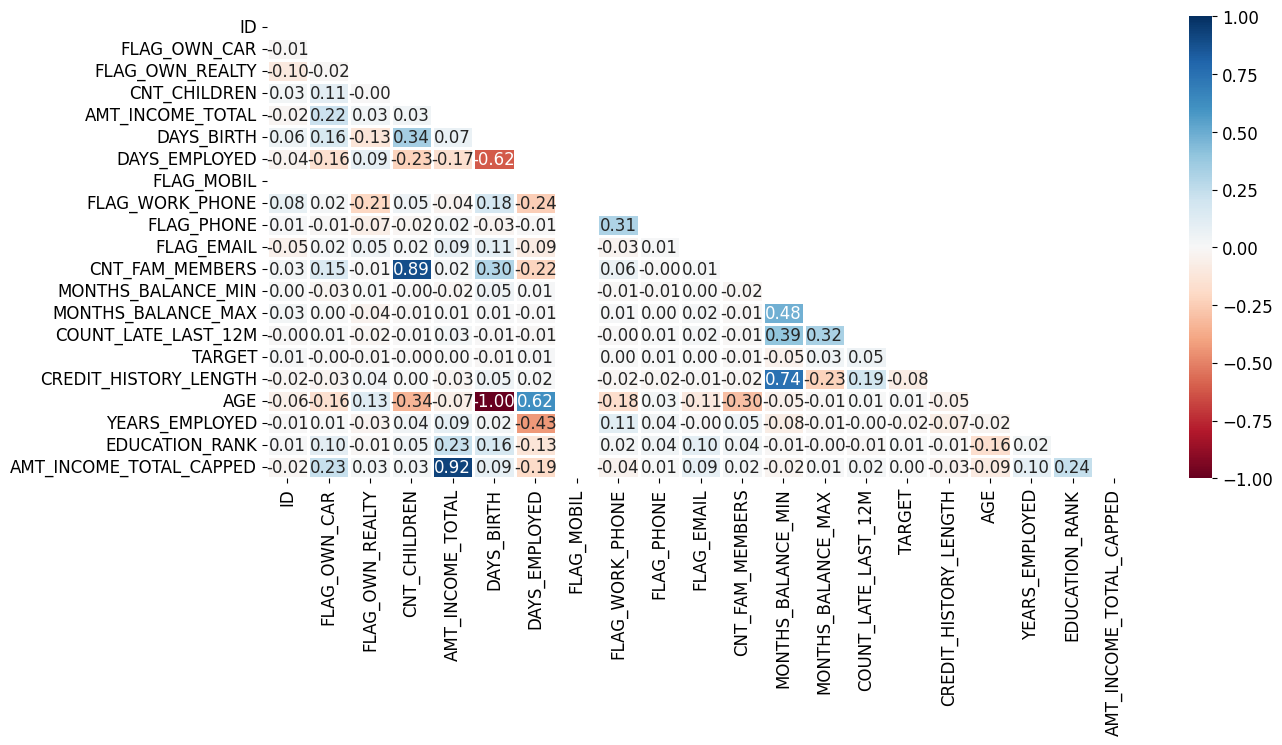

In [60]:

plt.figure(figsize=(14, 6))

corr_matrix = eda_df.select_dtypes(include='number').corr()

# Create a triangular mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=1, mask=mask, vmin=-1, vmax=1)

# Show the plot
plt.show()

In [61]:
print(eda_df['FLAG_MOBIL'].value_counts())

FLAG_MOBIL
1    36457
Name: count, dtype: int64


ternayat flag mobil di dataset merged ini berisi 1 semua, kita putuskan untuk drop saja, karena ada fitur yang lebih detail terkait kepemilikan perangkat mobile ini yaitu flag_work_phone dan flag_phone

In [62]:
eda_df = eda_df.drop(columns=['FLAG_MOBIL'])

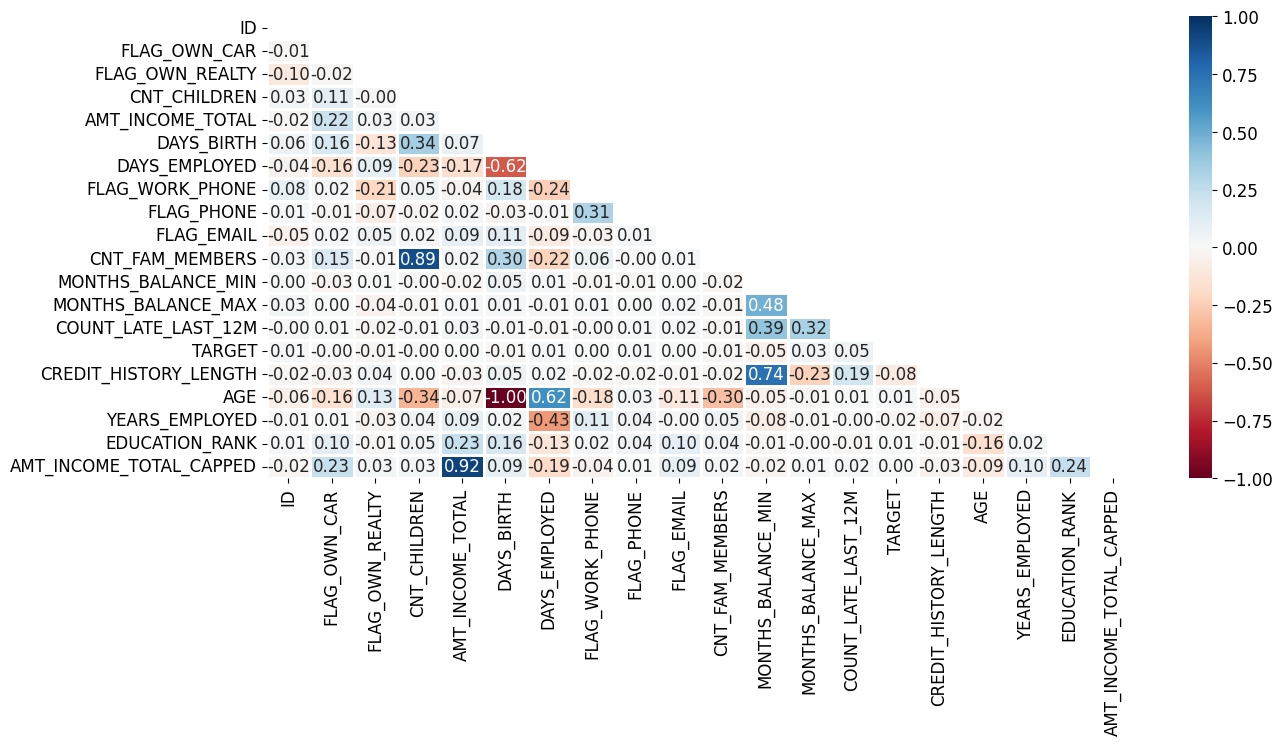

In [63]:

plt.figure(figsize=(14, 6))

corr_matrix = eda_df.select_dtypes(include='number').corr()

# Create a triangular mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=1, mask=mask, vmin=-1, vmax=1)

# Show the plot
plt.show()

tidak ada korelasi yang besar antar kolom yang bukan merupakan pembuat dan hasil feature engineeringnya (days birth dan age; months balance min/max dan credit hhistory length; etc), 

mungkin yang lumayan besar dibandingkan relatif dengan nilai korelasi lain adalah education rank dan amt income total/capped, yang berarti tingkat pendidikan dan pendapatan lumayan berkorelasi postif

selain itu nilai korelasi flag own car dengan amt income total juga lumayan besar relatif terhadaap nilai korelasi lain, yang cukup masuk akal karena semakin besar pendapatan semakin mungkin nasabah memiliki mobil

# Answering Business Question

nb

Default Rate adalah persentase nasabah yang gagal memenuhi kewajiban pembayaran (bad customer) dari total nasabah dalam suatu kelompok.

1a. Kelompok usia dan jenis kelamin mana yang memiliki tingkat default tertinggi?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\649723224.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




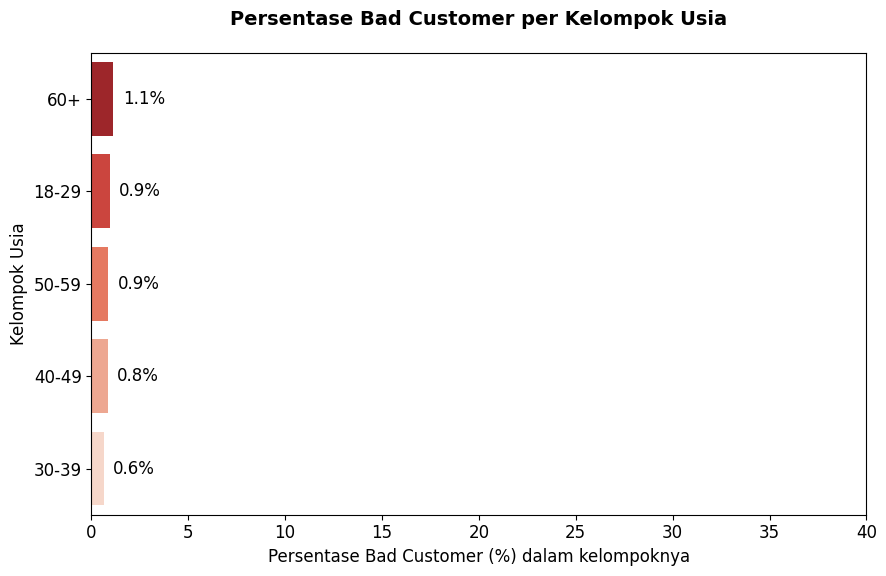

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung default rate per age group
age_risk = eda_df.groupby('AGE_GROUP')['TARGET'].mean().sort_values(ascending=False) * 100

# Visualisasi
plt.figure(figsize=(10,6))
sns.barplot(
    x=age_risk.values,
    y=age_risk.index,
    palette='Reds_r',
    order=age_risk.index
)
plt.title('Persentase Bad Customer per Kelompok Usia', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Persentase Bad Customer (%) dalam kelompoknya')
plt.ylabel('Kelompok Usia')
plt.xlim(0, 40)

# Tambah label persentase
for i, v in enumerate(age_risk.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", color='black', ha='left', va='center')

plt.show()

kelompok usia 60+ memiliki default rate tertinggi dengan 1.1% dari kelompoknya

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3770876086.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




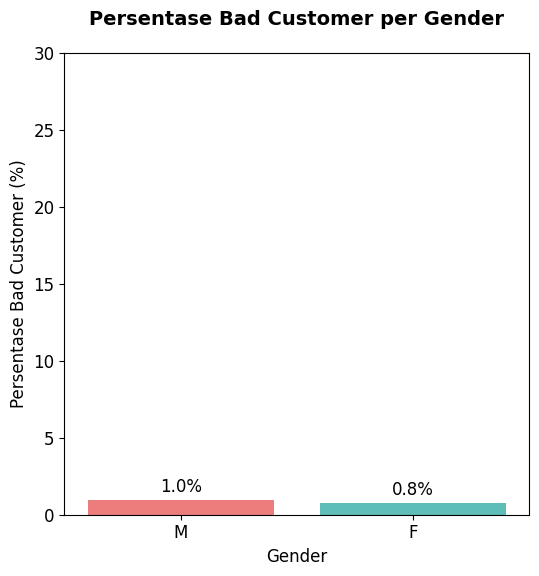

In [65]:
# Hitung default rate per gender
gender_risk = eda_df.groupby('CODE_GENDER')['TARGET'].mean().sort_values(ascending=False) * 100

# Visualisasi
plt.figure(figsize=(6,6))
sns.barplot(
    x=gender_risk.index,
    y=gender_risk.values,
    palette=['#ff6b6b', '#4ecdc4'],
    order=gender_risk.index
)
plt.title('Persentase Bad Customer per Gender', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Gender')
plt.ylabel('Persentase Bad Customer (%)')
plt.ylim(0, 30)

# Tambah label persentase
for i, v in enumerate(gender_risk.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", color='black', ha='center')

plt.show()

male merupakan gender dengan default rate yang lebih tinggi dari kelompoknya dengan 1% merupakan bad customer dari kelompoknya

1b. Apakah nasabah dengan anak >3 lebih berisiko?

In [66]:
import plotly.express as px

fig = px.box(
    eda_df,
    x='TARGET',
    y='CNT_CHILDREN',
    color='TARGET',
    color_discrete_map={0: '#4ecdc4', 1: '#ff6b6b'},
    labels={'CNT_CHILDREN': 'Number of Children', 'TARGET': 'Customer Status'},
    title='Distribution of Children Count by Customer Status'
)
fig.update_layout(showlegend=False)
fig.show()

nasabah dengan > 3 anak tidak beresiko karena termasuk outlier dari boxplot yang digambarkan

2a. Apakah nasabah berpendapatan tinggi dengan riwayat kredit pendek lebih berisiko?

In [67]:
fig = px.scatter(
    eda_df,
    x='CREDIT_HISTORY_LENGTH',
    y='AMT_INCOME_TOTAL',
    color='TARGET',
    color_discrete_map={0: '#4ecdc4', 1: '#ff6b6b'},
    size='COUNT_LATE_LAST_12M',
    hover_data=['OCCUPATION_TYPE'],
    title='Income vs Credit History Length (Size = Late Payments)'
)
fig.update_layout(
    xaxis_title='Credit History Length (Months)',
    yaxis_title='Annual Income',
    yaxis_type='log'
)
fig.show()

terlihat dalam grafik bahwa terjadi penumpukan bad customer dengan credit history length 12 dan anual income sekitar 50k - 170k 

2b. Bagaimana pengaruh jenis pekerjaan terhadap risiko kredit?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3714124373.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




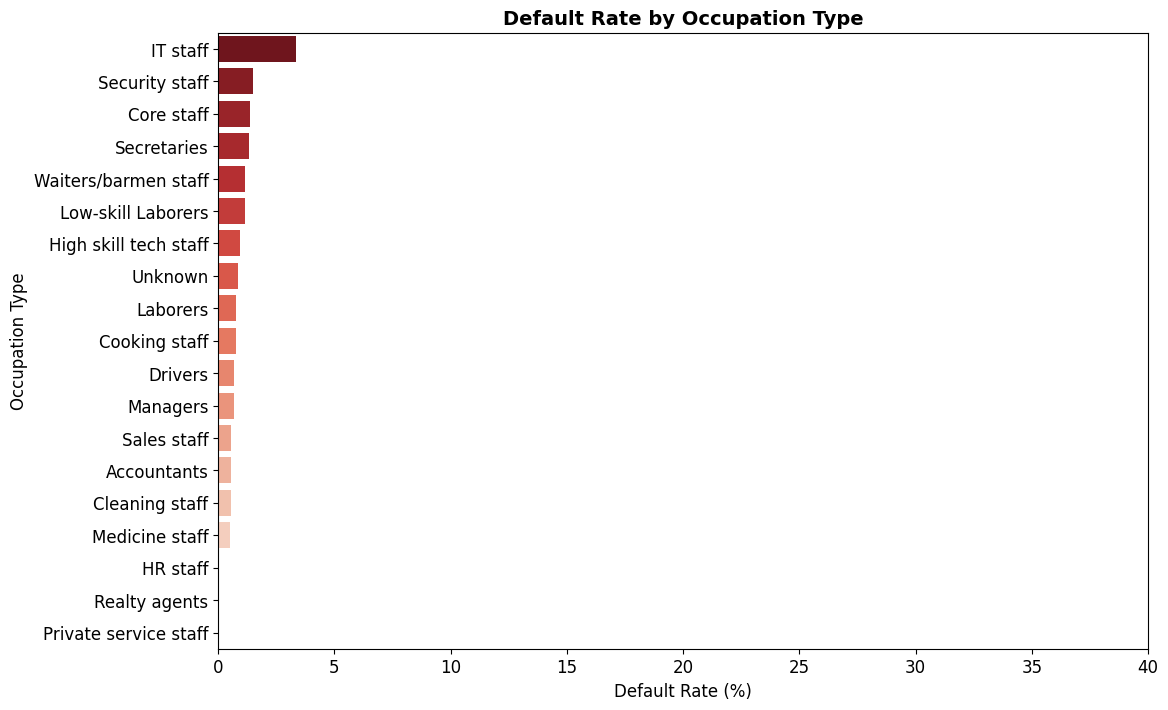

In [68]:
plt.figure(figsize=(12, 8))
occupation_risk = eda_df.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values(ascending=False)

sns.barplot(
    x=occupation_risk.values * 100,  # Konversi ke persentase
    y=occupation_risk.index,
    palette='Reds_r'
)
plt.title('Default Rate by Occupation Type', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.ylabel('Occupation Type')
plt.xlim(0, 40)
plt.show()

## **Univariate**

In [69]:
# Pengaturan visualisasi
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


## Kategori



*** ANALISIS VARIABEL KATEGORIK ***

Analisis untuk variabel: CODE_GENDER

Distribusi nilai untuk CODE_GENDER:
CODE_GENDER  Count  Percentage
          F  24430   67.010451
          M  12027   32.989549


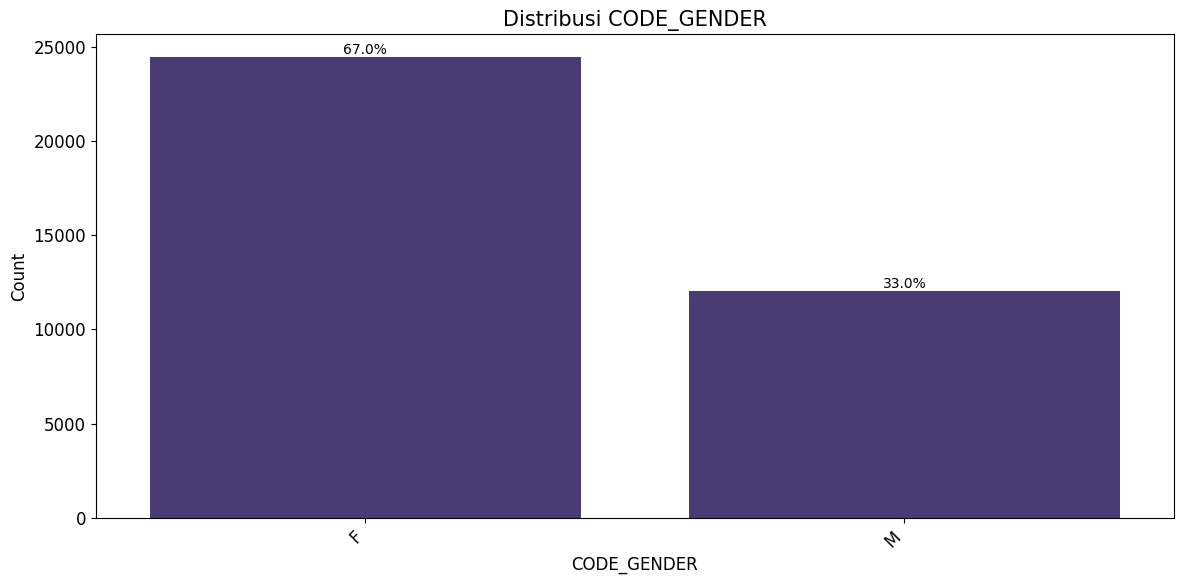

Missing values: 0 (0.00%)

Analisis untuk variabel: NAME_INCOME_TYPE

Distribusi nilai untuk NAME_INCOME_TYPE:
    NAME_INCOME_TYPE  Count  Percentage
             Working  18819   51.619716
Commercial associate   8490   23.287709
           Pensioner   6152   16.874674
       State servant   2985    8.187728
             Student     11    0.030173


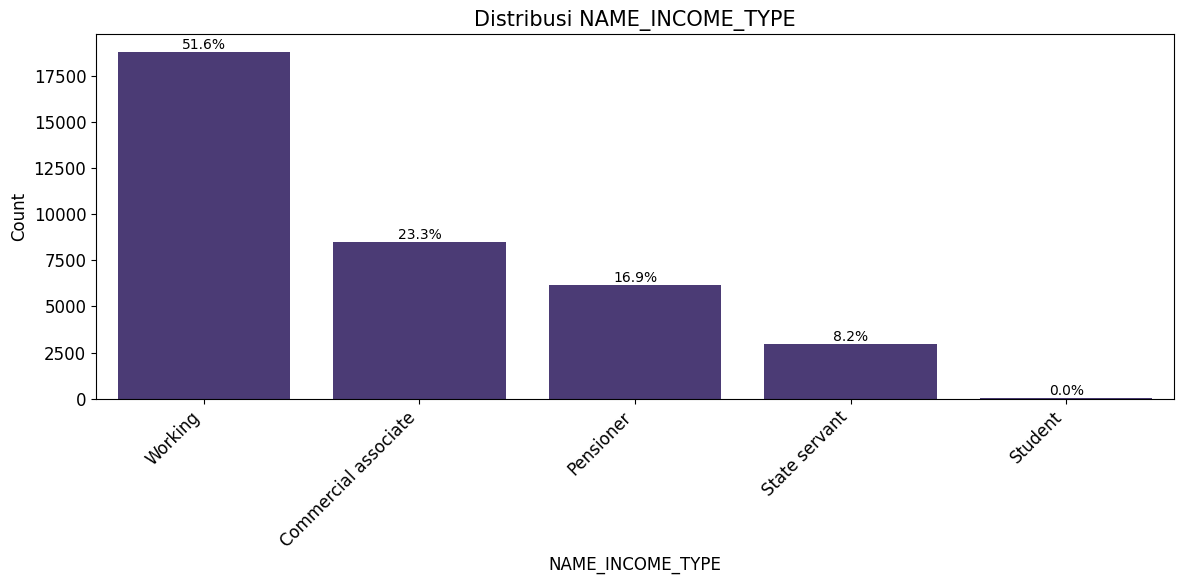

Missing values: 0 (0.00%)

Analisis untuk variabel: NAME_EDUCATION_TYPE

Distribusi nilai untuk NAME_EDUCATION_TYPE:
          NAME_EDUCATION_TYPE  Count  Percentage
Secondary / secondary special  24777   67.962257
             Higher education   9864   27.056532
            Incomplete higher   1410    3.867570
              Lower secondary    374    1.025866
              Academic degree     32    0.087775


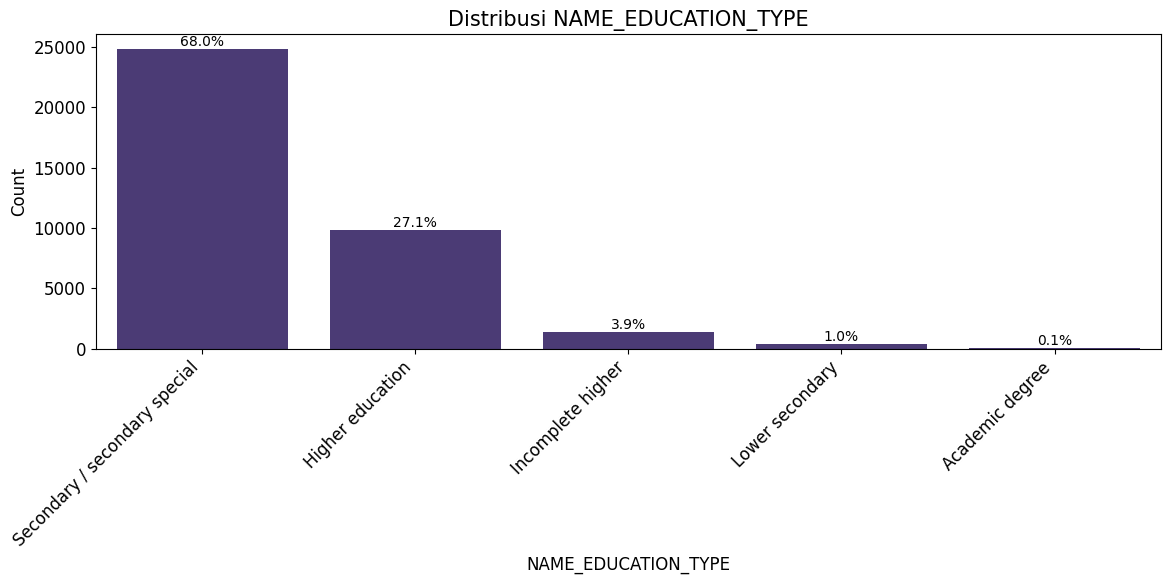

Missing values: 0 (0.00%)

Analisis untuk variabel: NAME_FAMILY_STATUS

Distribusi nilai untuk NAME_FAMILY_STATUS:
  NAME_FAMILY_STATUS  Count  Percentage
             Married  25048   68.705598
Single / not married   4829   13.245742
      Civil marriage   2945    8.078010
           Separated   2103    5.768440
               Widow   1532    4.202211


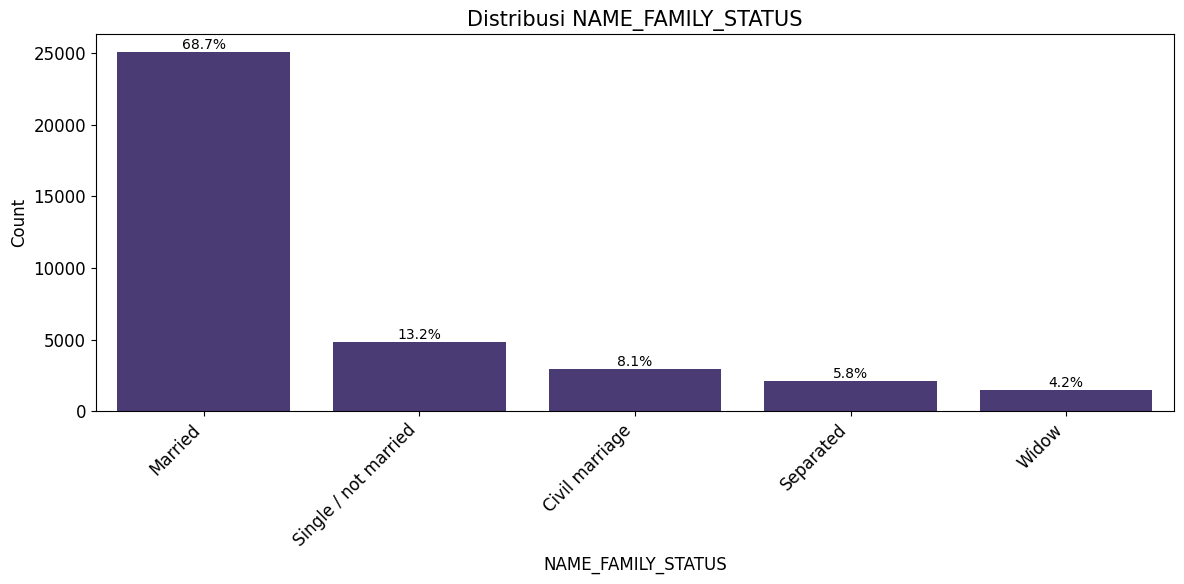

Missing values: 0 (0.00%)

Analisis untuk variabel: NAME_HOUSING_TYPE

Distribusi nilai untuk NAME_HOUSING_TYPE:
  NAME_HOUSING_TYPE  Count  Percentage
  House / apartment  32548   89.277779
       With parents   1776    4.871492
Municipal apartment   1128    3.094056
   Rented apartment    575    1.577201
   Office apartment    262    0.718655
    Co-op apartment    168    0.460817


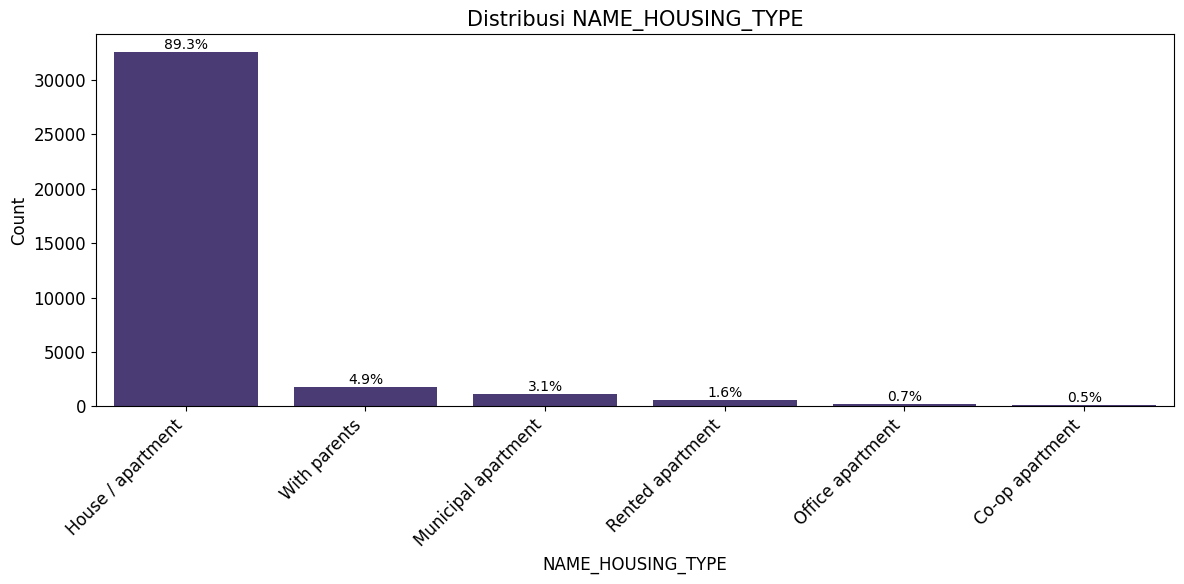

Missing values: 0 (0.00%)

Analisis untuk variabel: OCCUPATION_TYPE

Distribusi nilai untuk OCCUPATION_TYPE:
      OCCUPATION_TYPE  Count  Percentage
              Unknown  11323   31.058507
             Laborers   6211   17.036509
           Core staff   3591    9.849960
          Sales staff   3485    9.559207
             Managers   3012    8.261788
              Drivers   2138    5.864443
High skill tech staff   1383    3.793510
          Accountants   1241    3.404010
       Medicine staff   1207    3.310750
        Cooking staff    655    1.796637
       Security staff    592    1.623831
       Cleaning staff    551    1.511370
Private service staff    344    0.943577
   Low-skill Laborers    175    0.480018
 Waiters/barmen staff    174    0.477275
          Secretaries    151    0.414187
             HR staff     85    0.233151
        Realty agents     79    0.216694
             IT staff     60    0.164577


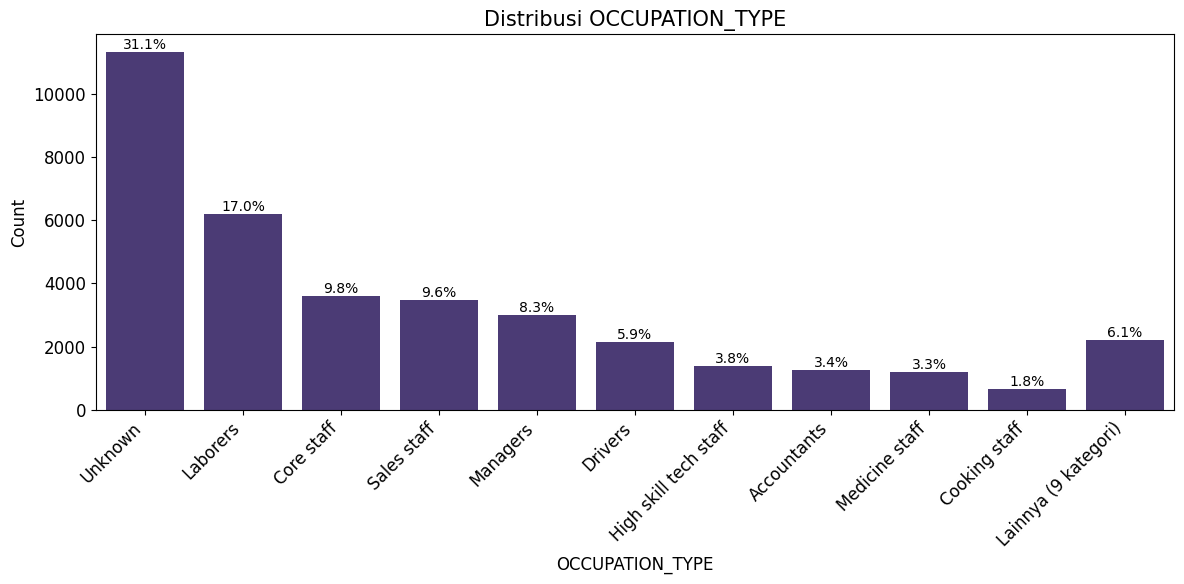

Missing values: 0 (0.00%)

Analisis untuk variabel: INCOME_GROUP

Distribusi nilai untuk INCOME_GROUP:
INCOME_GROUP  Count  Percentage
         Low  25713   70.529665
      Medium   9789   26.850811
        High    857    2.350715
   Very High     98    0.268810


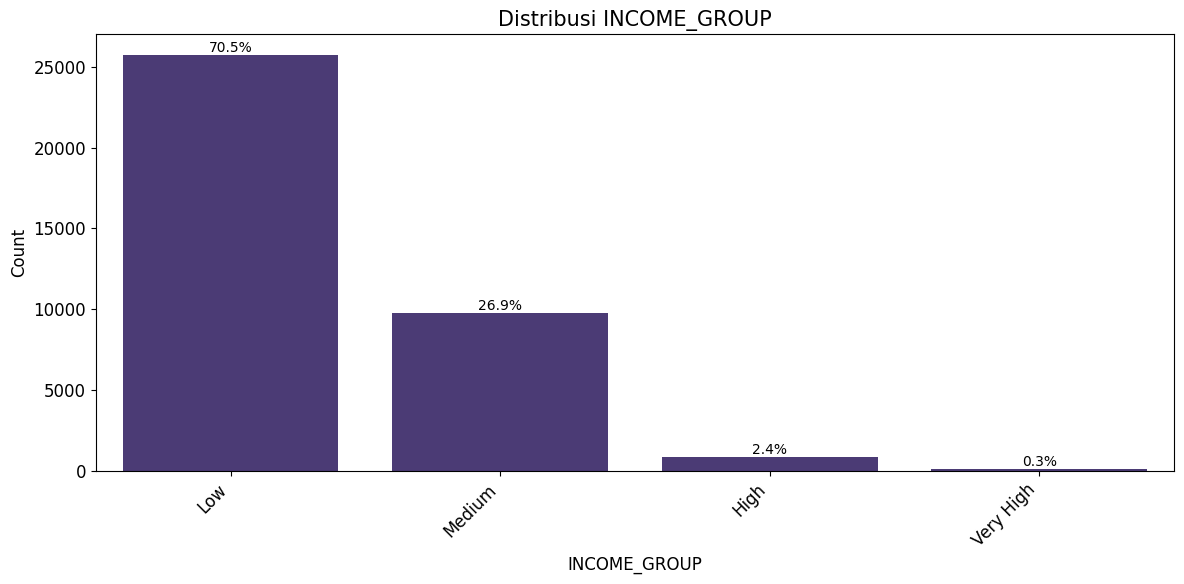

Missing values: 0 (0.00%)

Analisis untuk variabel: AGE_GROUP

Distribusi nilai untuk AGE_GROUP:
AGE_GROUP  Count  Percentage
    30-39  10411   28.556930
    40-49   9305   25.523219
    50-59   7978   21.883315
    18-29   4989   13.684615
      60+   3774   10.351921


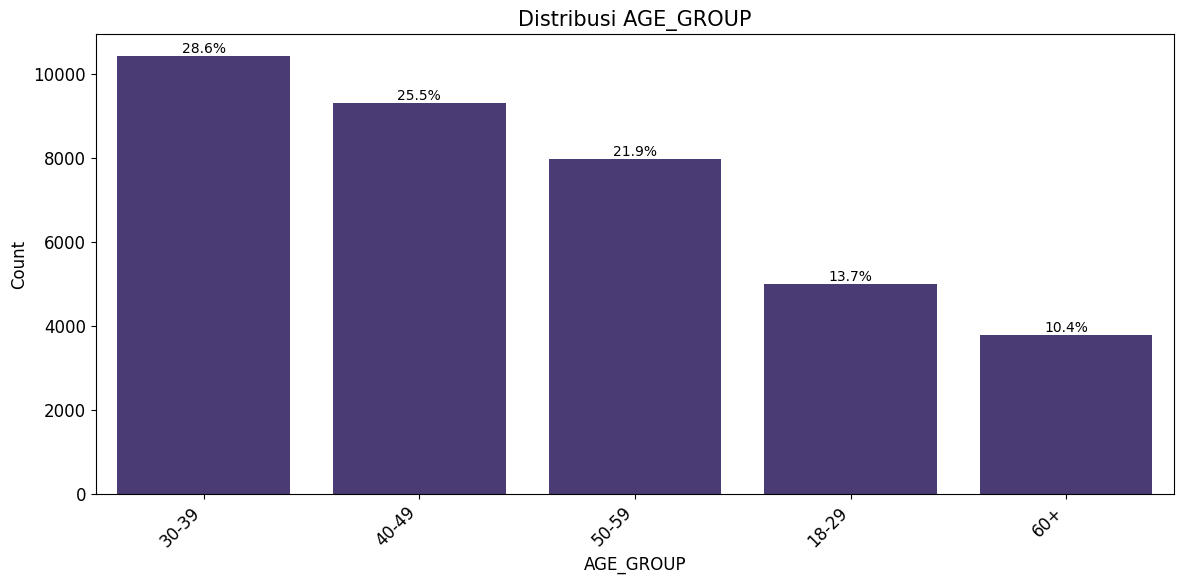

Missing values: 0 (0.00%)


In [70]:
# 1.1 Variabel Kategorik
def analyze_categorical(df, columns, max_categories=10):
    """Menganalisis variabel kategorik dan membuat visualisasi."""
    
    for col in columns:
        print(f"\n{'='*50}")
        print(f"Analisis untuk variabel: {col}")
        print(f"{'='*50}")
        
        # Menghitung value counts dan persentase
        value_counts = df[col].value_counts().reset_index()
        value_counts.columns = [col, 'Count']
        value_counts['Percentage'] = (value_counts['Count'] / len(df)) * 100
        
        # Menampilkan statistik
        print(f"\nDistribusi nilai untuk {col}:")
        print(value_counts.to_string(index=False))
        
        # Visualisasi
        plt.figure(figsize=(12, 6))
        
        # Jika terlalu banyak kategori, ambil top N saja
        if len(value_counts) > max_categories:
            plot_data = value_counts.iloc[:max_categories].copy()
            plot_data.loc[max_categories] = [f'Lainnya ({len(value_counts) - max_categories} kategori)', 
                                           value_counts['Count'][max_categories:].sum(),
                                           value_counts['Percentage'][max_categories:].sum()]
        else:
            plot_data = value_counts
            
        # Plot bar chart
        ax = sns.barplot(x=col, y='Count', data=plot_data)
        plt.title(f'Distribusi {col}', fontsize=15)
        plt.xticks(rotation=45, ha='right')
        
        # Menambahkan label persentase di atas bar
        for i, p in enumerate(ax.patches):
            ax.annotate(f"{plot_data['Percentage'].iloc[i]:.1f}%", 
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # Missing values
        missing = df[col].isna().sum()
        print(f"Missing values: {missing} ({missing/len(df)*100:.2f}%)")

# Pastikan untuk menyesuaikan daftar kolom sesuai dengan dataset yang sebenarnya
categorical_cols = ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
                   'INCOME_GROUP', 'AGE_GROUP']

# Menjalankan analisis univariate untuk setiap kelompok variabel
print("\n\n*** ANALISIS VARIABEL KATEGORIK ***")
analyze_categorical(eda_df, categorical_cols)

## Numerik



*** ANALISIS VARIABEL NUMERIK ***

Analisis untuk variabel: CNT_CHILDREN

Statistik deskriptif:
count    36457.000000
mean         0.430315
std          0.742367
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         19.000000
Name: CNT_CHILDREN, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -1.50
Batas atas: 2.50
Jumlah outlier: 508 (1.39%)


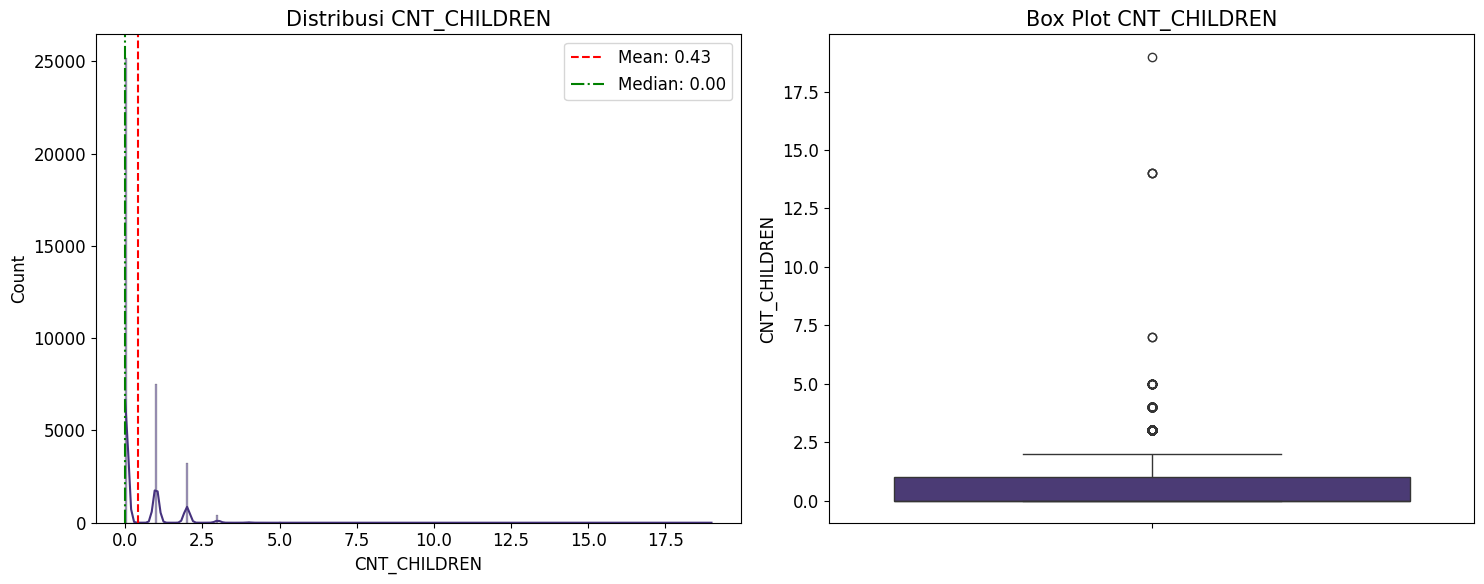


Uji normalitas D'Agostino-Pearson:
Statistik: 23379.6666, p-value: 0.0000
Distribusi CNT_CHILDREN tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: AMT_INCOME_TOTAL

Statistik deskriptif:
count    3.645700e+04
mean     1.866857e+05
std      1.017892e+05
min      2.700000e+04
25%      1.215000e+05
50%      1.575000e+05
75%      2.250000e+05
max      1.575000e+06
Name: AMT_INCOME_TOTAL, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -33750.00
Batas atas: 380250.00
Jumlah outlier: 1529 (4.19%)


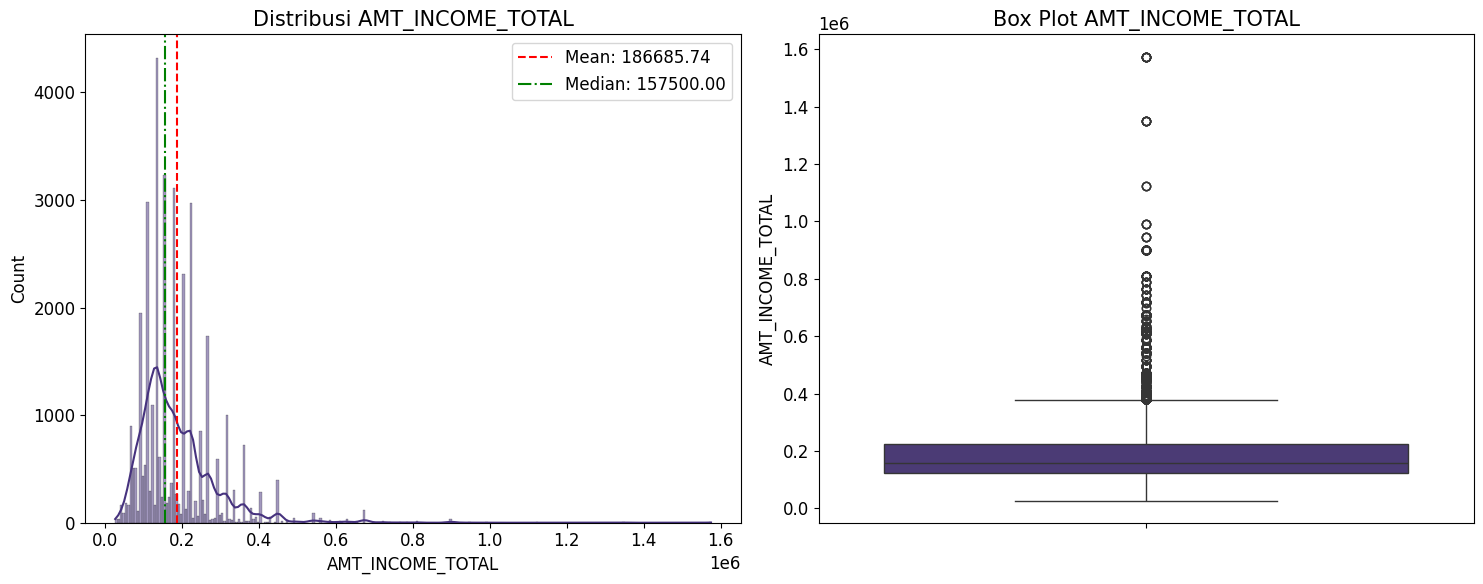


Uji normalitas D'Agostino-Pearson:
Statistik: 23412.9422, p-value: 0.0000
Distribusi AMT_INCOME_TOTAL tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: DAYS_BIRTH

Statistik deskriptif:
count    36457.000000
mean    -15975.173382
std       4200.549944
min     -25152.000000
25%     -19438.000000
50%     -15563.000000
75%     -12462.000000
max      -7489.000000
Name: DAYS_BIRTH, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -29902.00
Batas atas: -1998.00
Jumlah outlier: 0 (0.00%)


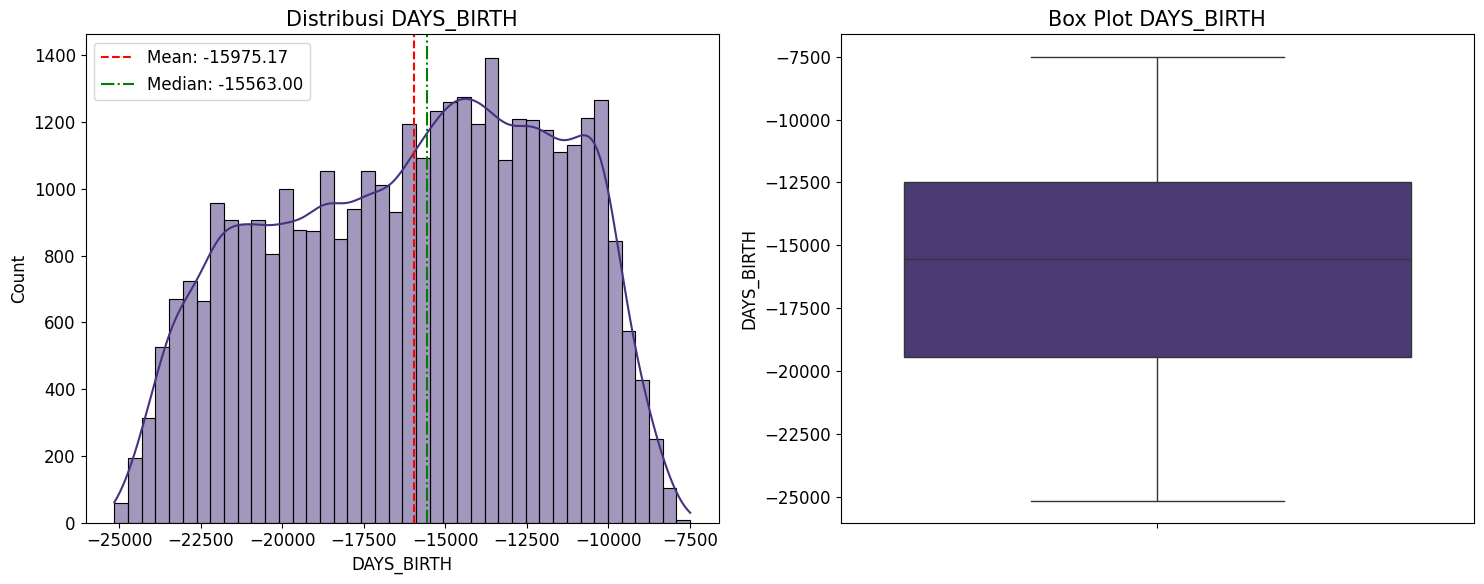


Uji normalitas D'Agostino-Pearson:
Statistik: 10997.9400, p-value: 0.0000
Distribusi DAYS_BIRTH tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: DAYS_EMPLOYED

Statistik deskriptif:
count     36457.000000
mean      59262.935568
std      137651.334859
min      -15713.000000
25%       -3153.000000
50%       -1552.000000
75%        -408.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -7270.50
Batas atas: 3709.50
Jumlah outlier: 7905 (21.68%)


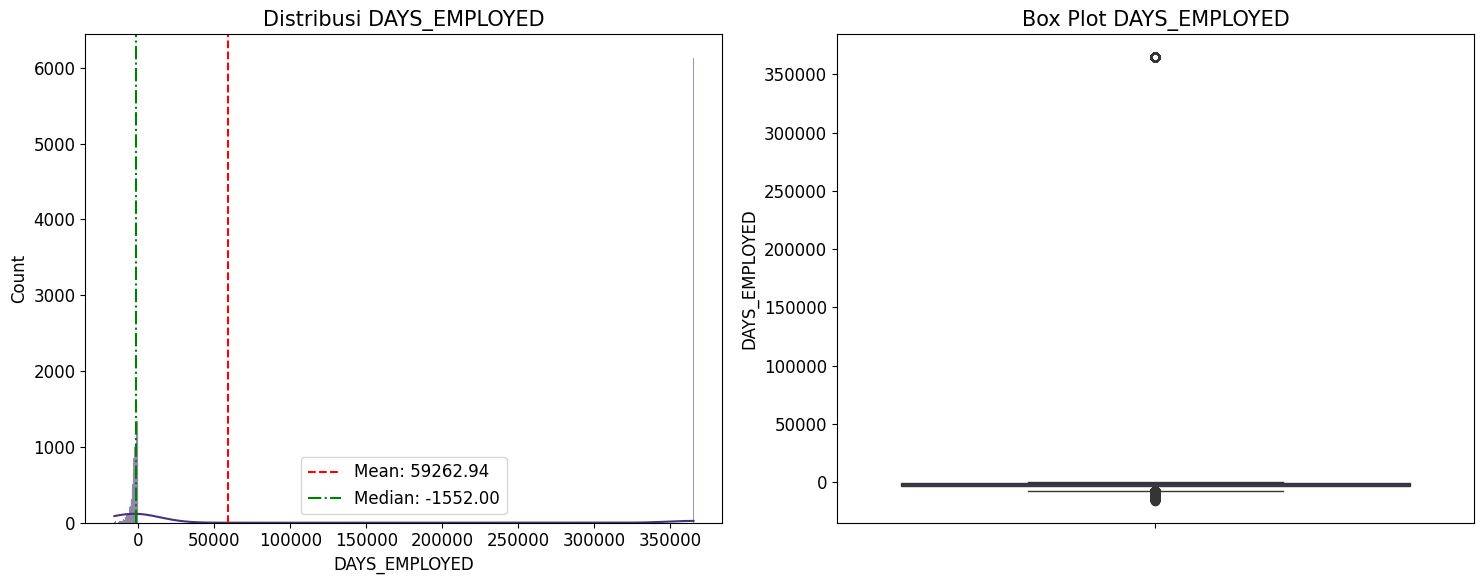


Uji normalitas D'Agostino-Pearson:
Statistik: 10181.0386, p-value: 0.0000
Distribusi DAYS_EMPLOYED tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: CNT_FAM_MEMBERS

Statistik deskriptif:
count    36457.000000
mean         2.198453
std          0.911686
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: 0.50
Batas atas: 4.50
Jumlah outlier: 480 (1.32%)


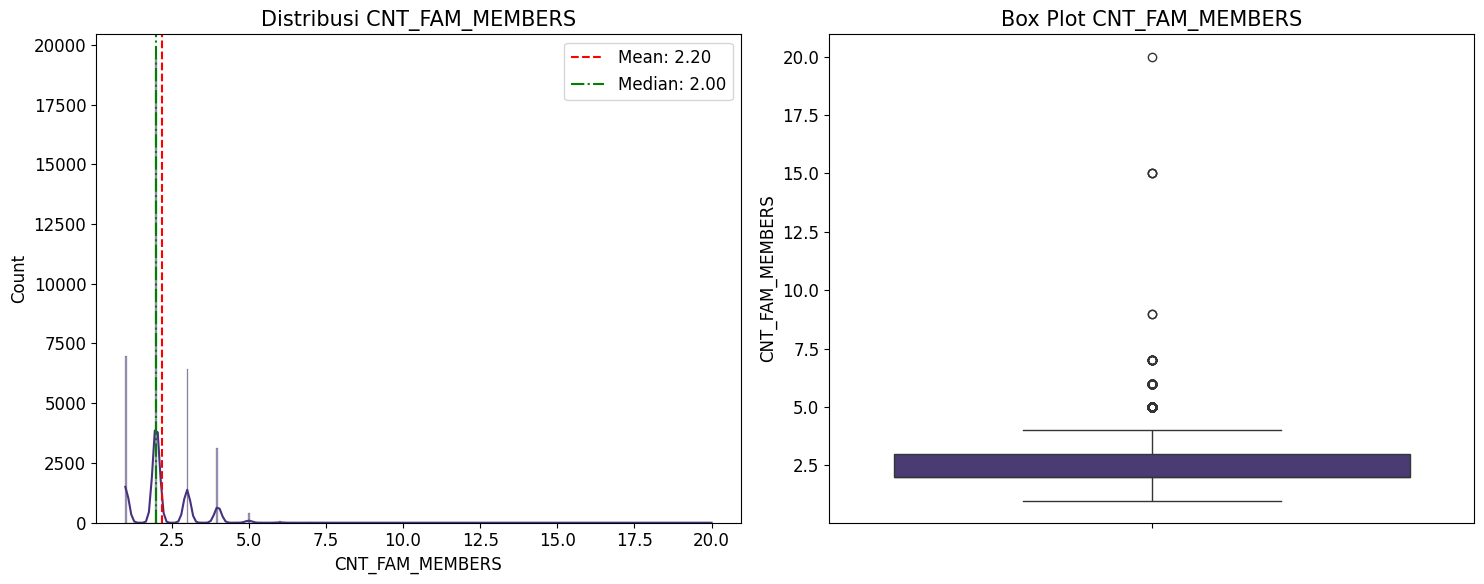


Uji normalitas D'Agostino-Pearson:
Statistik: 11898.7357, p-value: 0.0000
Distribusi CNT_FAM_MEMBERS tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: AGE

Statistik deskriptif:
count    36457.000000
mean        43.767916
std         11.508464
min         20.500000
25%         34.100000
50%         42.600000
75%         53.300000
max         68.900000
Name: AGE, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: 5.30
Batas atas: 82.10
Jumlah outlier: 0 (0.00%)


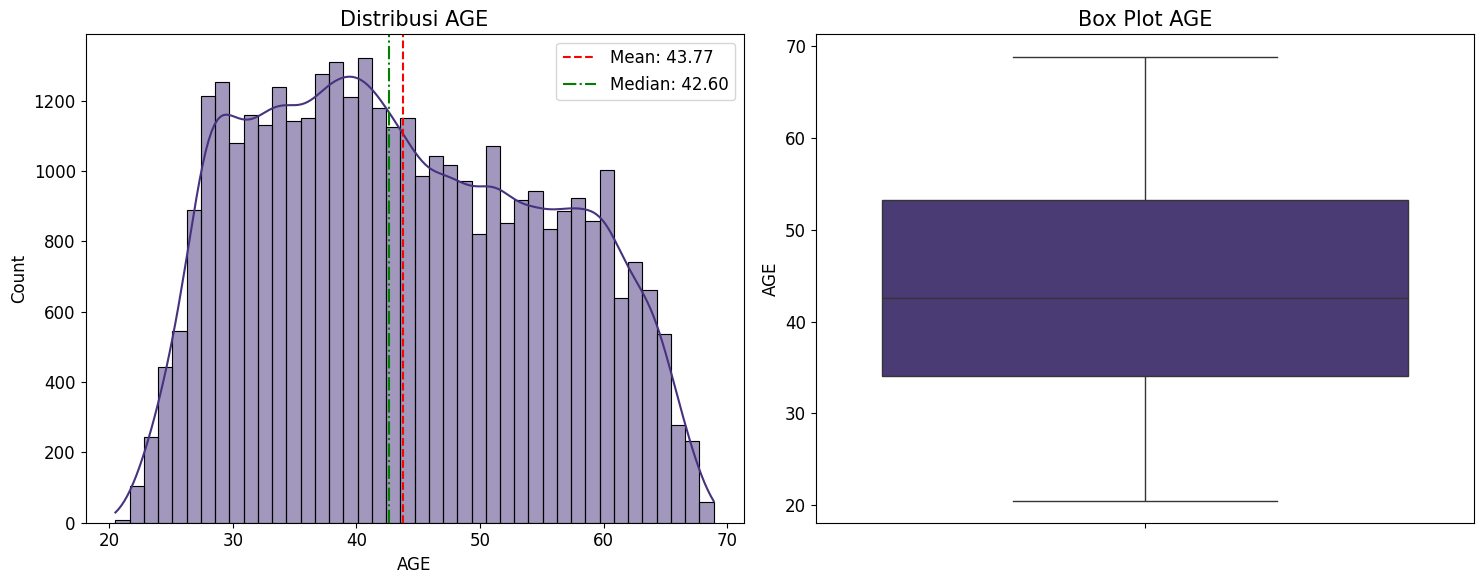


Uji normalitas D'Agostino-Pearson:
Statistik: 11011.0780, p-value: 0.0000
Distribusi AGE tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: YEARS_EMPLOYED

Statistik deskriptif:
count    36457.000000
mean         6.027973
std          6.484278
min          0.000000
25%          1.100000
50%          4.300000
75%          8.600000
max         43.000000
Name: YEARS_EMPLOYED, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -10.15
Batas atas: 19.85
Jumlah outlier: 1810 (4.96%)


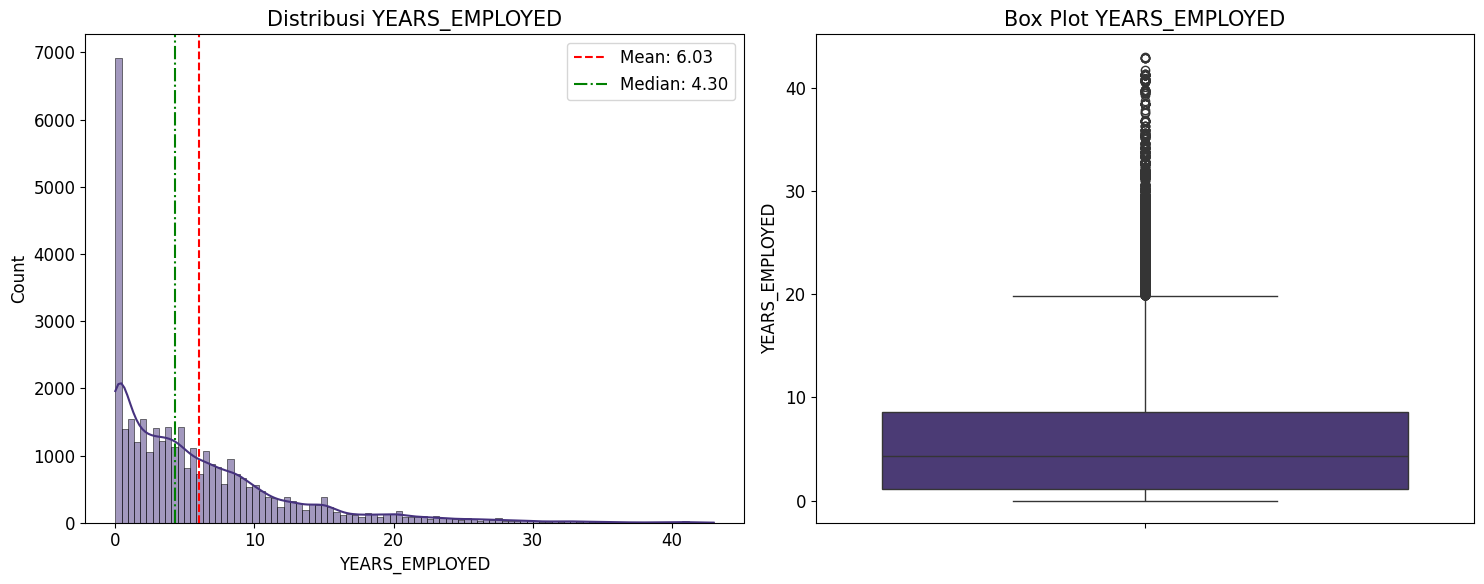


Uji normalitas D'Agostino-Pearson:
Statistik: 12471.4592, p-value: 0.0000
Distribusi YEARS_EMPLOYED tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: CREDIT_HISTORY_LENGTH

Statistik deskriptif:
count    36457.000000
mean       -20.332392
std         14.911849
min        -60.000000
25%        -30.000000
50%        -17.000000
75%         -8.000000
max          0.000000
Name: CREDIT_HISTORY_LENGTH, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -63.00
Batas atas: 25.00
Jumlah outlier: 0 (0.00%)


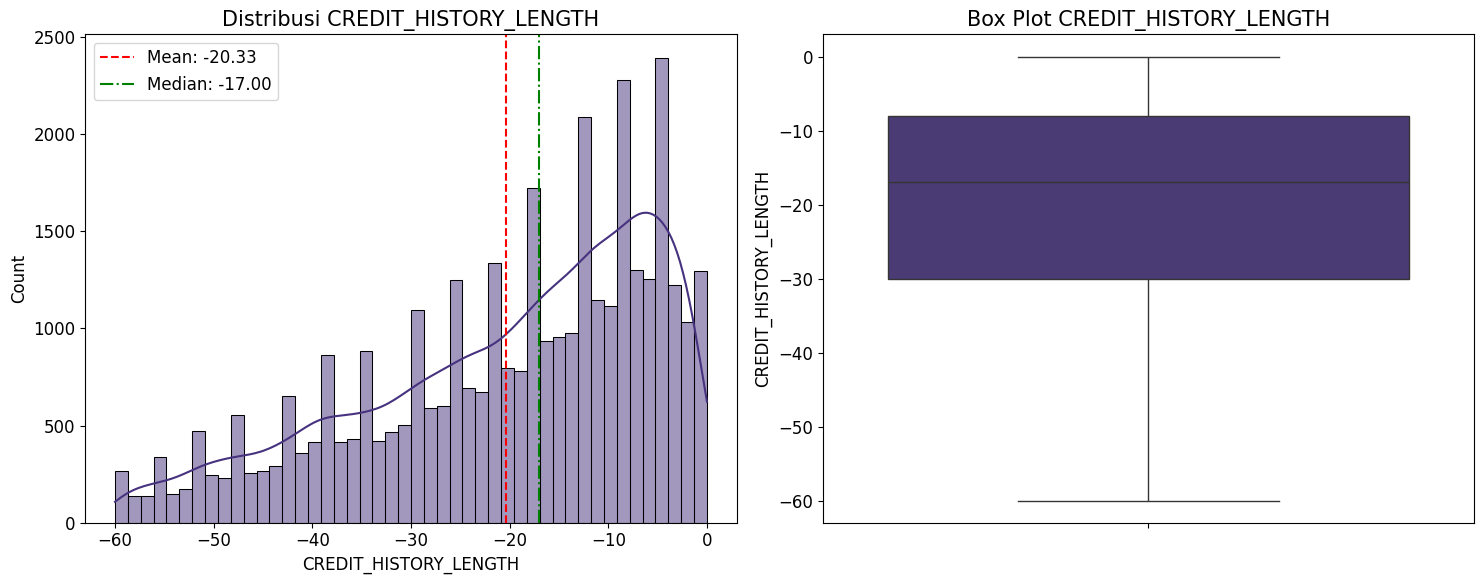


Uji normalitas D'Agostino-Pearson:
Statistik: 2981.9122, p-value: 0.0000
Distribusi CREDIT_HISTORY_LENGTH tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: COUNT_LATE_LAST_12M

Statistik deskriptif:
count    36457.000000
mean         2.740873
std          4.026107
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max         13.000000
Name: COUNT_LATE_LAST_12M, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -7.50
Batas atas: 12.50
Jumlah outlier: 1792 (4.92%)


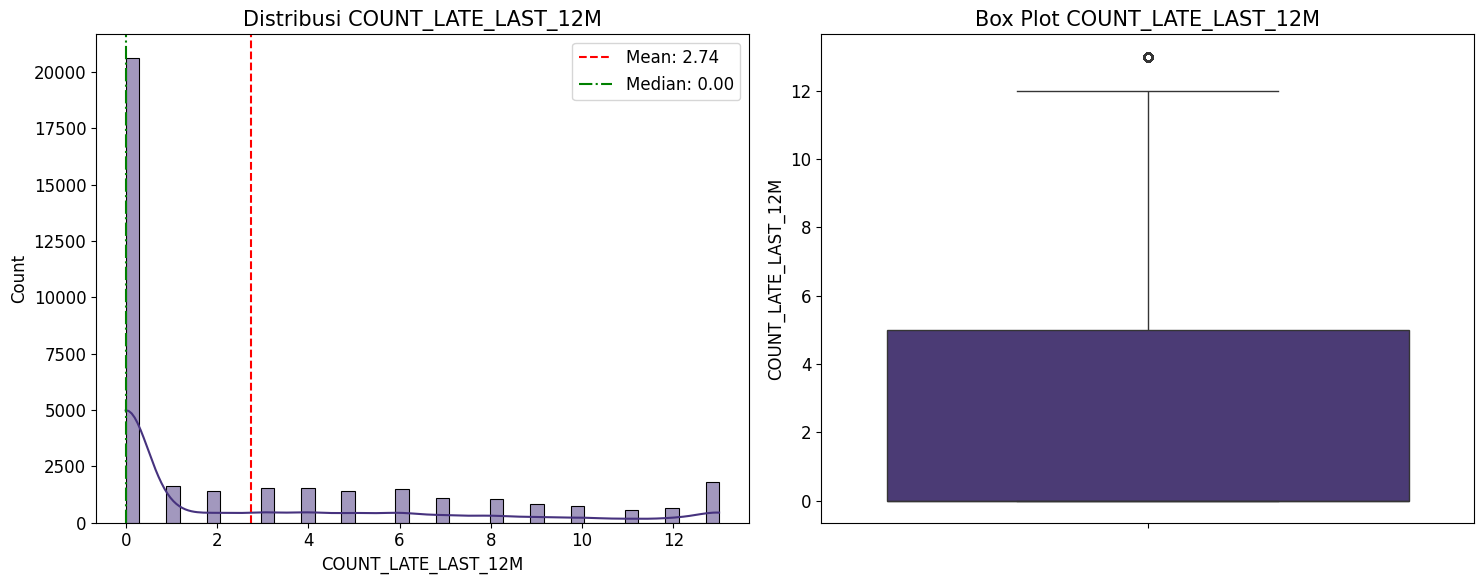


Uji normalitas D'Agostino-Pearson:
Statistik: 6622.6765, p-value: 0.0000
Distribusi COUNT_LATE_LAST_12M tidak normal (p < 0.05)

Missing values: 0 (0.00%)

Analisis untuk variabel: EDUCATION_RANK

Statistik deskriptif:
count    36457.000000
mean         1.572181
std          0.900959
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max          4.000000
Name: EDUCATION_RANK, dtype: float64

Deteksi Outlier menggunakan metode IQR:
Batas bawah: -2.00
Batas atas: 6.00
Jumlah outlier: 0 (0.00%)


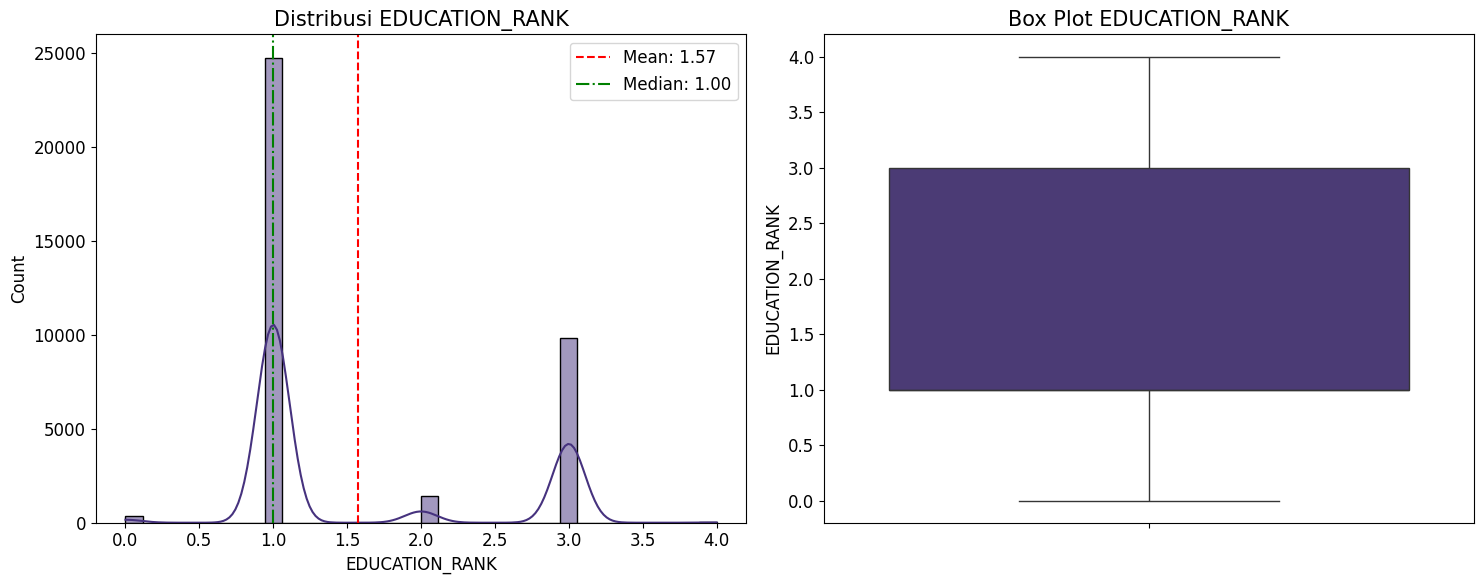


Uji normalitas D'Agostino-Pearson:
Statistik: 13888.3559, p-value: 0.0000
Distribusi EDUCATION_RANK tidak normal (p < 0.05)

Missing values: 0 (0.00%)


In [71]:
# 1.2 Variabel Numerik
def analyze_numeric(df, columns):
    """Menganalisis variabel numerik dan membuat visualisasi."""
    
    for col in columns:
        print(f"\n{'='*50}")
        print(f"Analisis untuk variabel: {col}")
        print(f"{'='*50}")
        
        # Statistik deskriptif
        desc = df[col].describe()
        print("\nStatistik deskriptif:")
        print(desc)
        
        # Mendeteksi outlier menggunakan IQR
        Q1 = desc['25%']
        Q3 = desc['75%']
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        print(f"\nDeteksi Outlier menggunakan metode IQR:")
        print(f"Batas bawah: {lower_bound:.2f}")
        print(f"Batas atas: {upper_bound:.2f}")
        print(f"Jumlah outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
        
        # Visualisasi
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Histogram
        sns.histplot(df[col], kde=True, ax=ax1)
        ax1.set_title(f'Distribusi {col}', fontsize=15)
        ax1.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
        ax1.axvline(df[col].median(), color='green', linestyle='-.', label=f'Median: {df[col].median():.2f}')
        ax1.legend()
        
        # Box Plot
        sns.boxplot(y=df[col], ax=ax2)
        ax2.set_title(f'Box Plot {col}', fontsize=15)
        
        plt.tight_layout()
        plt.show()
        
        # Pengujian normalitas
        k2, p = stats.normaltest(df[col].dropna())
        alpha = 0.05
        print(f"\nUji normalitas D'Agostino-Pearson:")
        print(f"Statistik: {k2:.4f}, p-value: {p:.4f}")
        if p < alpha:
            print(f"Distribusi {col} tidak normal (p < {alpha})")
        else:
            print(f"Distribusi {col} normal (p >= {alpha})")
        
        # Missing values
        missing = df[col].isna().sum()
        print(f"\nMissing values: {missing} ({missing/len(df)*100:.2f}%)")

numeric_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
               'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED', 'CREDIT_HISTORY_LENGTH',
               'COUNT_LATE_LAST_12M', 'EDUCATION_RANK']

print("\n\n*** ANALISIS VARIABEL NUMERIK ***")
analyze_numeric(eda_df, numeric_cols)

## Binary



*** ANALISIS VARIABEL BINARY ***

Analisis untuk variabel: FLAG_OWN_CAR

Distribusi nilai untuk FLAG_OWN_CAR:
 FLAG_OWN_CAR  Count  Percentage
            0  22614    62.02924
            1  13843    37.97076


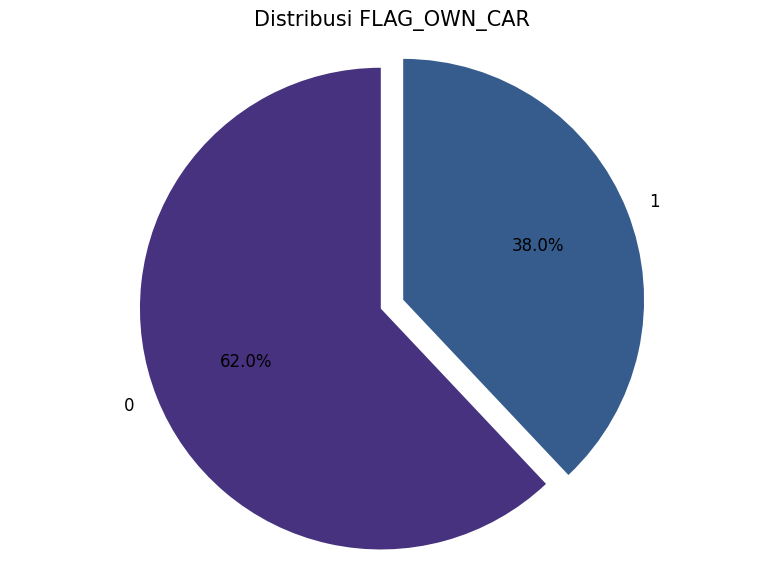

Missing values: 0 (0.00%)

Analisis untuk variabel: FLAG_OWN_REALTY

Distribusi nilai untuk FLAG_OWN_REALTY:
 FLAG_OWN_REALTY  Count  Percentage
               1  24506   67.218915
               0  11951   32.781085


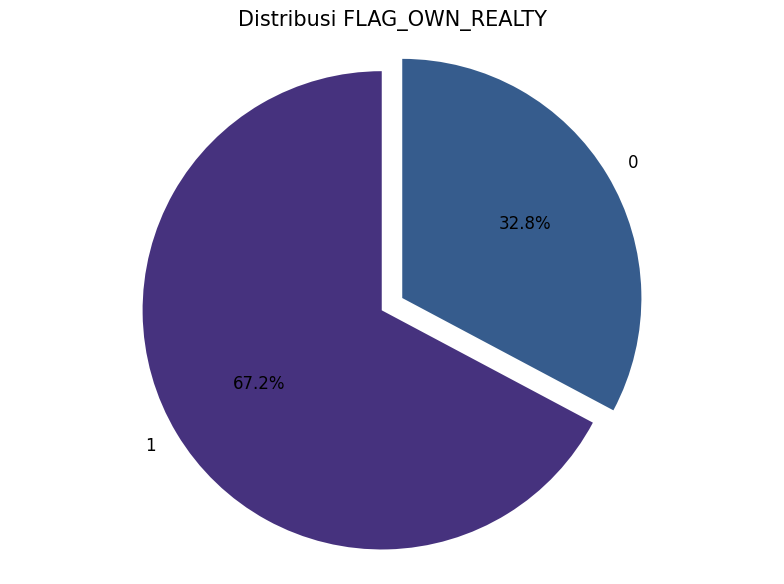

Missing values: 0 (0.00%)

Analisis untuk variabel: FLAG_WORK_PHONE

Distribusi nilai untuk FLAG_WORK_PHONE:
 FLAG_WORK_PHONE  Count  Percentage
               0  28235   77.447404
               1   8222   22.552596


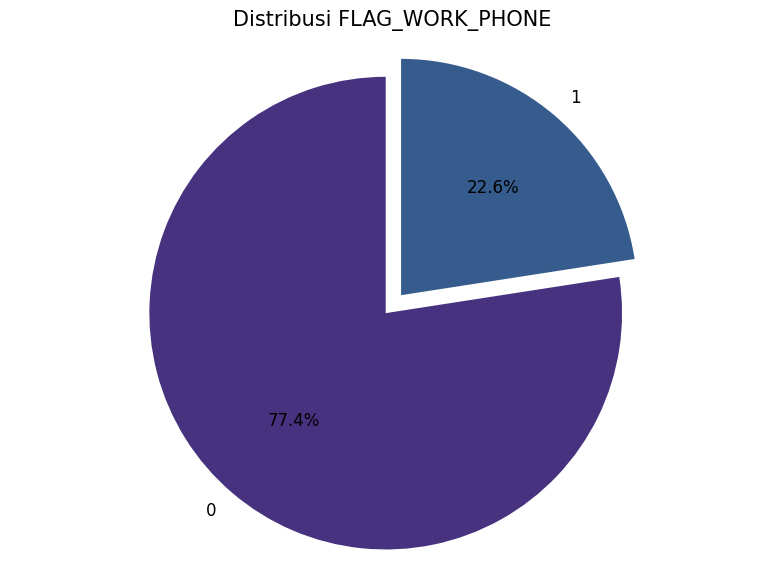

Missing values: 0 (0.00%)

Analisis untuk variabel: FLAG_PHONE

Distribusi nilai untuk FLAG_PHONE:
 FLAG_PHONE  Count  Percentage
          0  25709   70.518693
          1  10748   29.481307


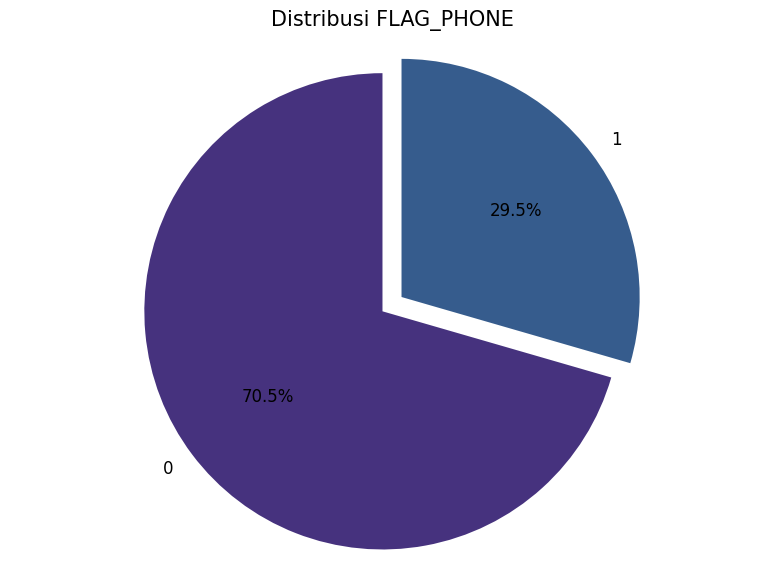

Missing values: 0 (0.00%)

Analisis untuk variabel: FLAG_EMAIL

Distribusi nilai untuk FLAG_EMAIL:
 FLAG_EMAIL  Count  Percentage
          0  33186   91.027786
          1   3271    8.972214


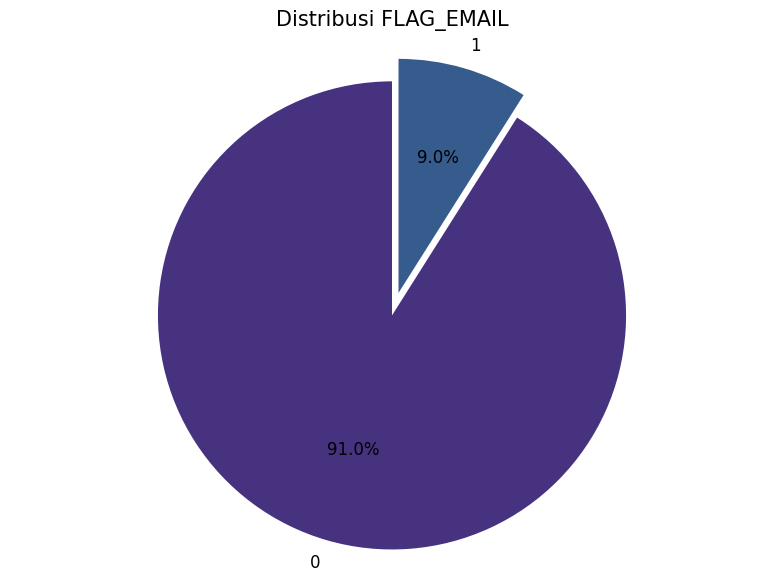

Missing values: 0 (0.00%)

Analisis untuk variabel: TARGET

Distribusi nilai untuk TARGET:
 TARGET  Count  Percentage
      0  36155   99.171627
      1    302    0.828373


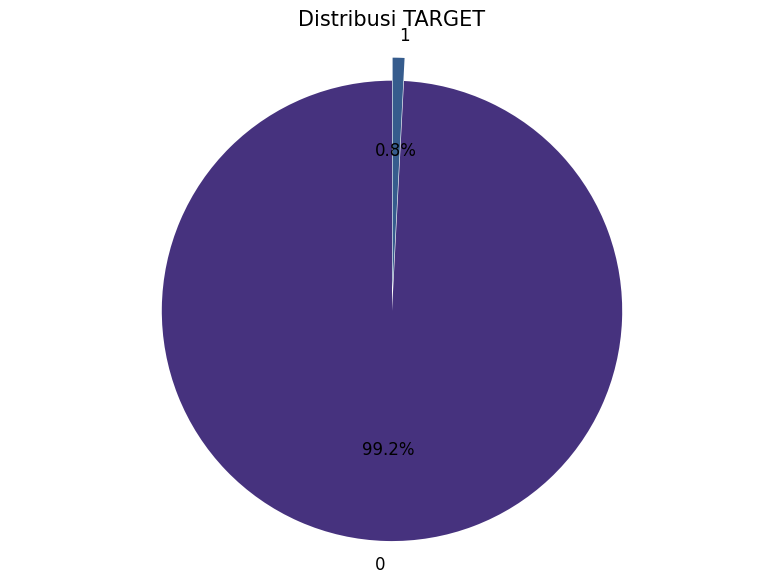

Missing values: 0 (0.00%)


In [72]:
# 1.3 Variabel Binary
def analyze_binary(df, columns):
    """Menganalisis variabel binary dan membuat visualisasi."""
    
    for col in columns:
        print(f"\n{'='*50}")
        print(f"Analisis untuk variabel: {col}")
        print(f"{'='*50}")
        
        # Menghitung value counts dan persentase
        value_counts = df[col].value_counts().reset_index()
        value_counts.columns = [col, 'Count']
        value_counts['Percentage'] = (value_counts['Count'] / len(df)) * 100
        
        # Menampilkan statistik
        print(f"\nDistribusi nilai untuk {col}:")
        print(value_counts.to_string(index=False))
        
        # Visualisasi
        plt.figure(figsize=(8, 6))
        
        # Plot pie chart
        plt.pie(value_counts['Count'], labels=value_counts[col], autopct='%1.1f%%', 
                startangle=90, explode=[0.05] * len(value_counts),
                textprops={'fontsize': 12})
        plt.title(f'Distribusi {col}', fontsize=15)
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        
        # Missing values
        missing = df[col].isna().sum()
        print(f"Missing values: {missing} ({missing/len(df)*100:.2f}%)")

# Mengelompokkan variabel berdasarkan tipe data


binary_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE',
              'FLAG_PHONE', 'FLAG_EMAIL', 'TARGET']


print("\n\n*** ANALISIS VARIABEL BINARY ***")
analyze_binary(eda_df, binary_cols)

# **Bivariate**

## Kategorikal vs Target



*** ANALISIS VARIABEL KATEGORIK VS TARGET ***

Analisis CODE_GENDER vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET               0         1
CODE_GENDER                     
F            99.238641  0.761359
M            99.035503  0.964497

Jumlah data per kategori:
TARGET           0    1
CODE_GENDER            
F            24244  186
M            11911  116

Chi-square test untuk independensi:
Chi2 = 3.8047, p-value = 0.0511, degrees of freedom = 1
Tidak ada hubungan yang signifikan antara CODE_GENDER dan TARGET (p >= 0.05)


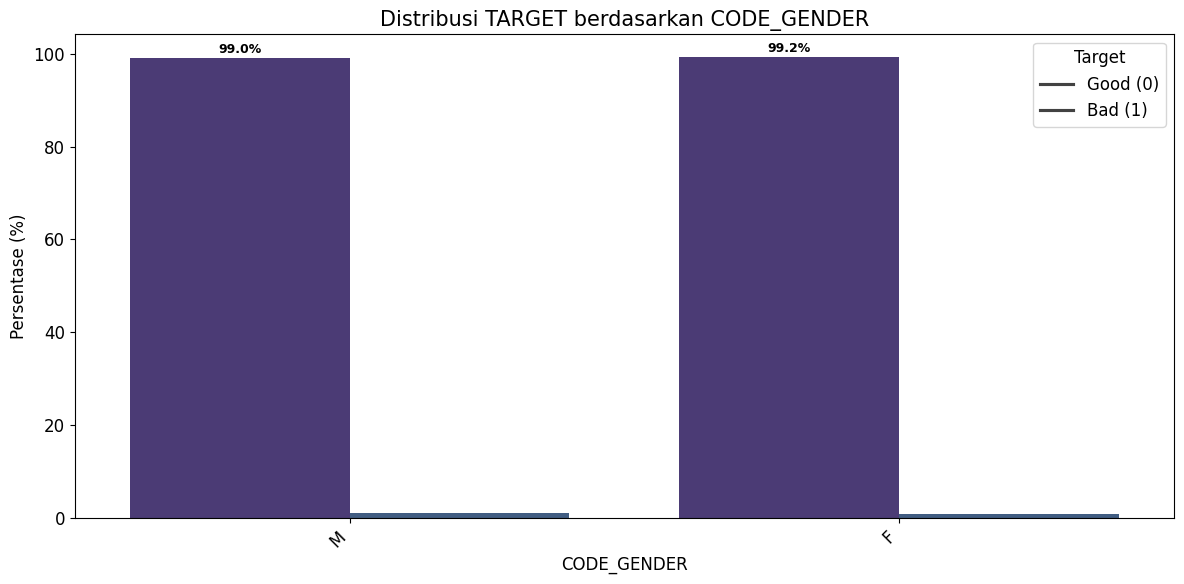


Analisis NAME_INCOME_TYPE vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET                         0         1
NAME_INCOME_TYPE                          
Commercial associate   99.022379  0.977621
Pensioner              98.845904  1.154096
State servant          99.363484  0.636516
Student               100.000000  0.000000
Working                99.314523  0.685477

Jumlah data per kategori:
TARGET                    0    1
NAME_INCOME_TYPE                
Commercial associate   8407   83
Pensioner              6081   71
State servant          2966   19
Student                  11    0
Working               18690  129

Chi-square test untuk independensi:
Chi2 = 16.3541, p-value = 0.0026, degrees of freedom = 4
Ada hubungan yang signifikan antara NAME_INCOME_TYPE dan TARGET (p < 0.05)


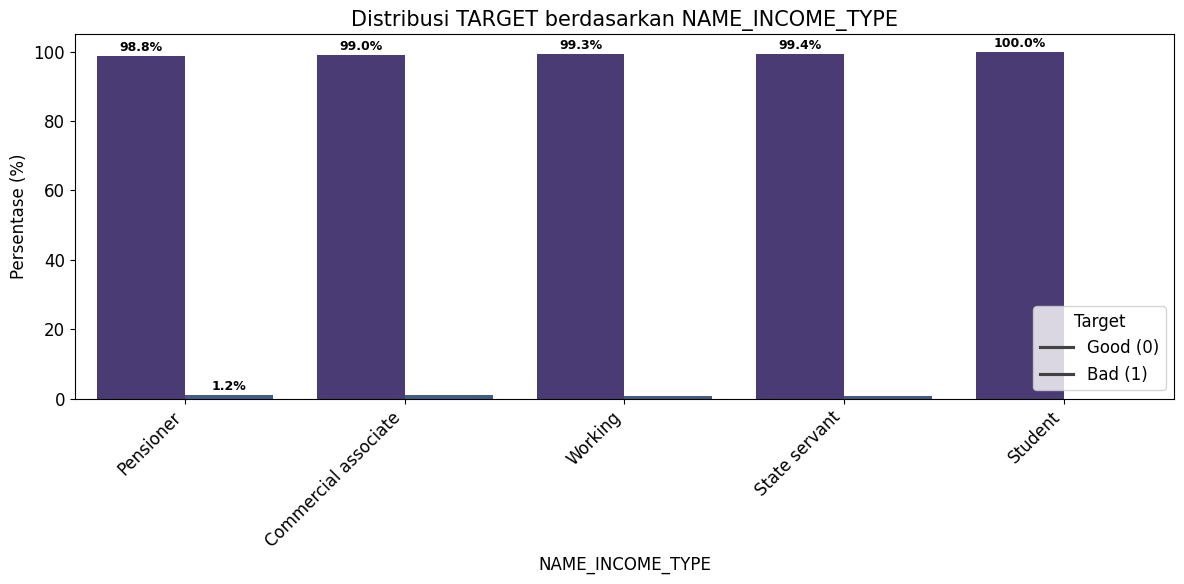


Analisis NAME_EDUCATION_TYPE vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET                                  0         1
NAME_EDUCATION_TYPE                                
Academic degree                100.000000  0.000000
Higher education                99.077453  0.922547
Incomplete higher               98.581560  1.418440
Lower secondary                 98.128342  1.871658
Secondary / secondary special   99.257376  0.742624

Jumlah data per kategori:
TARGET                             0    1
NAME_EDUCATION_TYPE                      
Academic degree                   32    0
Higher education                9773   91
Incomplete higher               1390   20
Lower secondary                  367    7
Secondary / secondary special  24593  184

Chi-square test untuk independensi:
Chi2 = 14.4810, p-value = 0.0059, degrees of freedom = 4
Ada hubungan yang signifikan antara NAME_EDUCATION_TYPE dan TARGET (p < 0.05)


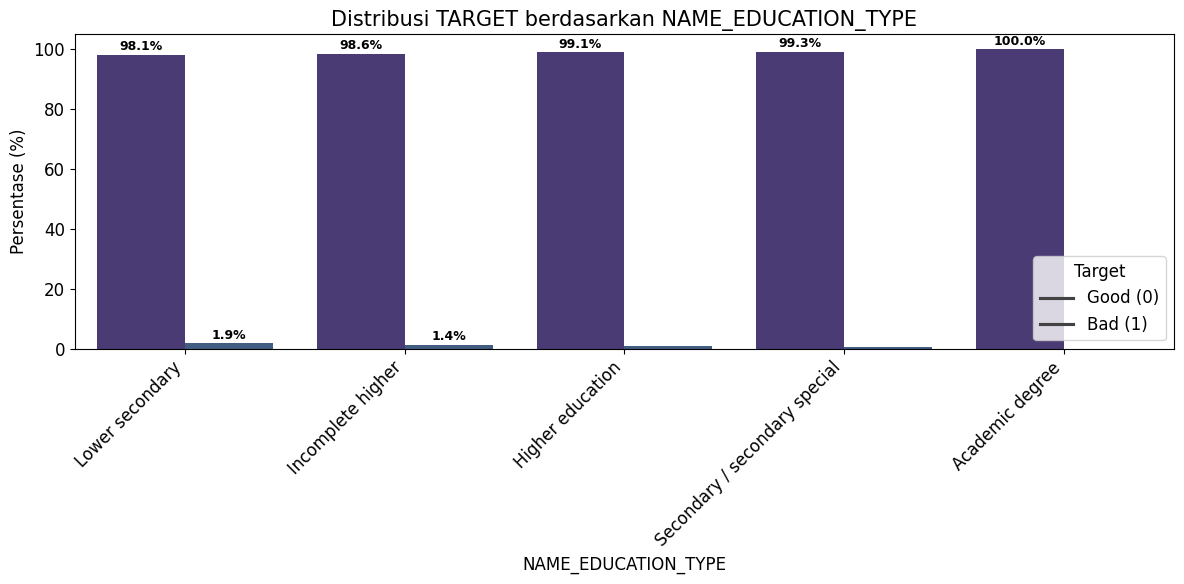


Analisis NAME_FAMILY_STATUS vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET                        0         1
NAME_FAMILY_STATUS                       
Civil marriage        99.728353  0.271647
Married               99.209518  0.790482
Separated             98.716120  1.283880
Single / not married  98.943881  1.056119
Widow                 98.825065  1.174935

Jumlah data per kategori:
TARGET                    0    1
NAME_FAMILY_STATUS              
Civil marriage         2937    8
Married               24850  198
Separated              2076   27
Single / not married   4778   51
Widow                  1514   18

Chi-square test untuk independensi:
Chi2 = 22.1490, p-value = 0.0002, degrees of freedom = 4
Ada hubungan yang signifikan antara NAME_FAMILY_STATUS dan TARGET (p < 0.05)


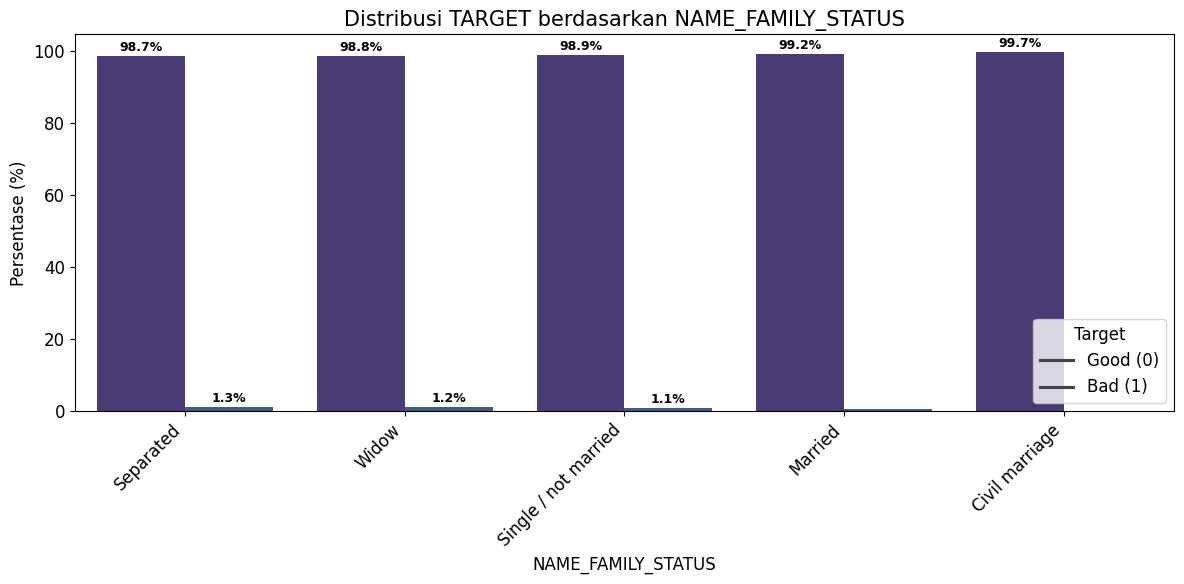


Analisis NAME_HOUSING_TYPE vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET                       0         1
NAME_HOUSING_TYPE                       
Co-op apartment      98.214286  1.785714
House / apartment    99.201180  0.798820
Municipal apartment  98.049645  1.950355
Office apartment     98.473282  1.526718
Rented apartment     99.130435  0.869565
With parents         99.549550  0.450450

Jumlah data per kategori:
TARGET                   0    1
NAME_HOUSING_TYPE              
Co-op apartment        165    3
House / apartment    32288  260
Municipal apartment   1106   22
Office apartment       258    4
Rented apartment       570    5
With parents          1768    8

Chi-square test untuk independensi:
Chi2 = 24.1601, p-value = 0.0002, degrees of freedom = 5
Ada hubungan yang signifikan antara NAME_HOUSING_TYPE dan TARGET (p < 0.05)


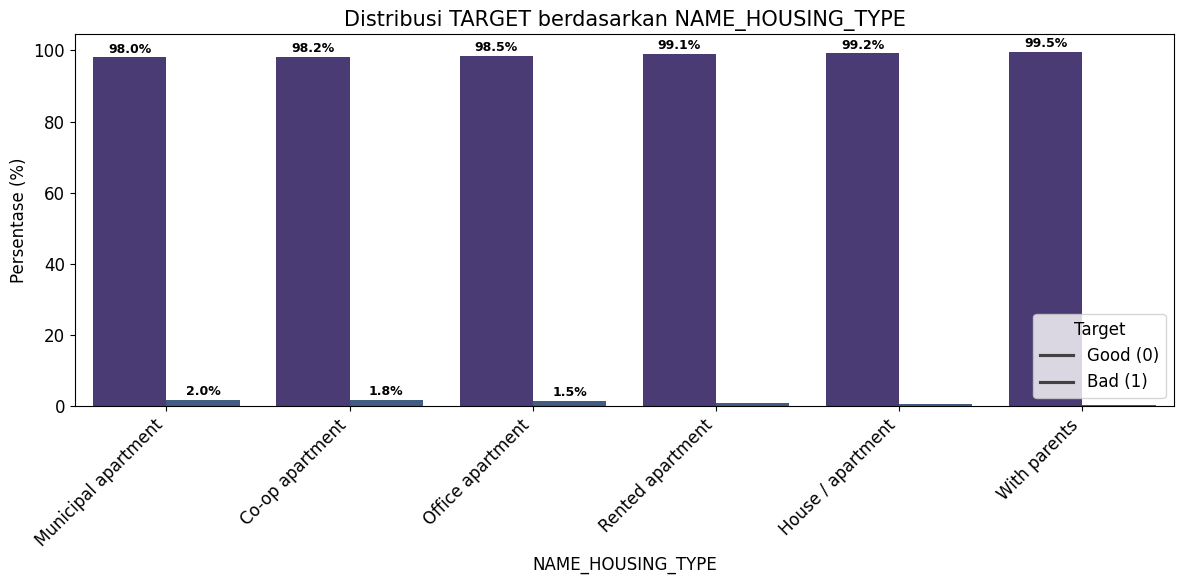


Analisis OCCUPATION_TYPE vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET                          0         1
OCCUPATION_TYPE                            
Accountants             99.435939  0.564061
Cleaning staff          99.455535  0.544465
Cooking staff           99.236641  0.763359
Core staff              98.635478  1.364522
Drivers                 99.298410  0.701590
HR staff               100.000000  0.000000
High skill tech staff   99.060014  0.939986
IT staff                96.666667  3.333333
Laborers                99.227178  0.772822
Low-skill Laborers      98.857143  1.142857
Managers                99.335989  0.664011
Medicine staff          99.502900  0.497100
Private service staff  100.000000  0.000000
Realty agents          100.000000  0.000000
Sales staff             99.426112  0.573888
Secretaries             98.675497  1.324503
Security staff          98.479730  1.520270
Unknown                 99.125673  0.874327
Waiters/barmen staff    98.850575  1.14

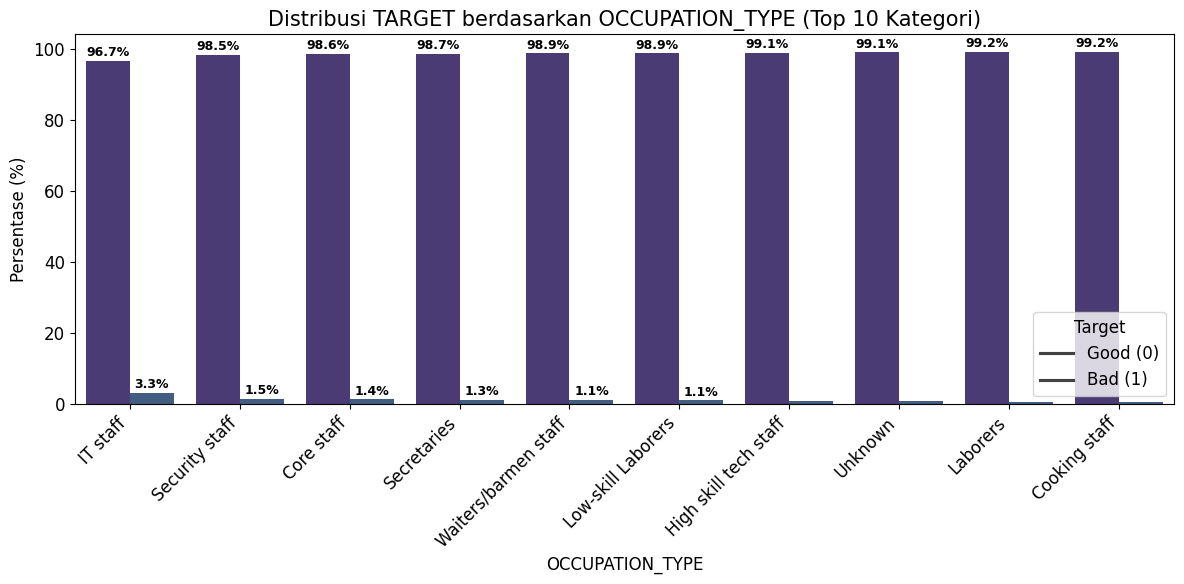


Analisis INCOME_GROUP vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET                 0         1
INCOME_GROUP                      
High           98.016336  1.983664
Low            99.175514  0.824486
Medium         99.254265  0.745735
Very High     100.000000  0.000000

Jumlah data per kategori:
TARGET            0    1
INCOME_GROUP            
High            840   17
Low           25501  212
Medium         9716   73
Very High        98    0

Chi-square test untuk independensi:
Chi2 = 15.5606, p-value = 0.0014, degrees of freedom = 3
Ada hubungan yang signifikan antara INCOME_GROUP dan TARGET (p < 0.05)


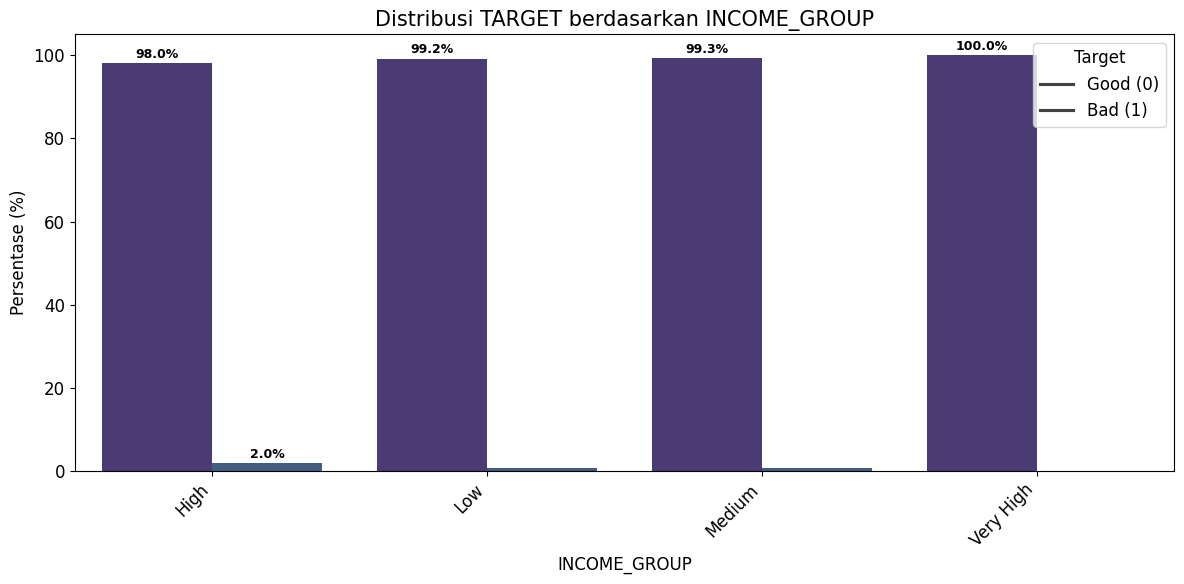


Analisis AGE_GROUP vs TARGET

Distribusi Target berdasarkan kategori (%):
TARGET             0         1
AGE_GROUP                     
18-29      99.057927  0.942073
30-39      99.366055  0.633945
40-49      99.161741  0.838259
50-59      99.147656  0.852344
60+        98.860625  1.139375

Jumlah data per kategori:
TARGET         0   1
AGE_GROUP           
18-29       4942  47
30-39      10345  66
40-49       9227  78
50-59       7910  68
60+         3731  43

Chi-square test untuk independensi:
Chi2 = 10.0860, p-value = 0.0390, degrees of freedom = 4
Ada hubungan yang signifikan antara AGE_GROUP dan TARGET (p < 0.05)


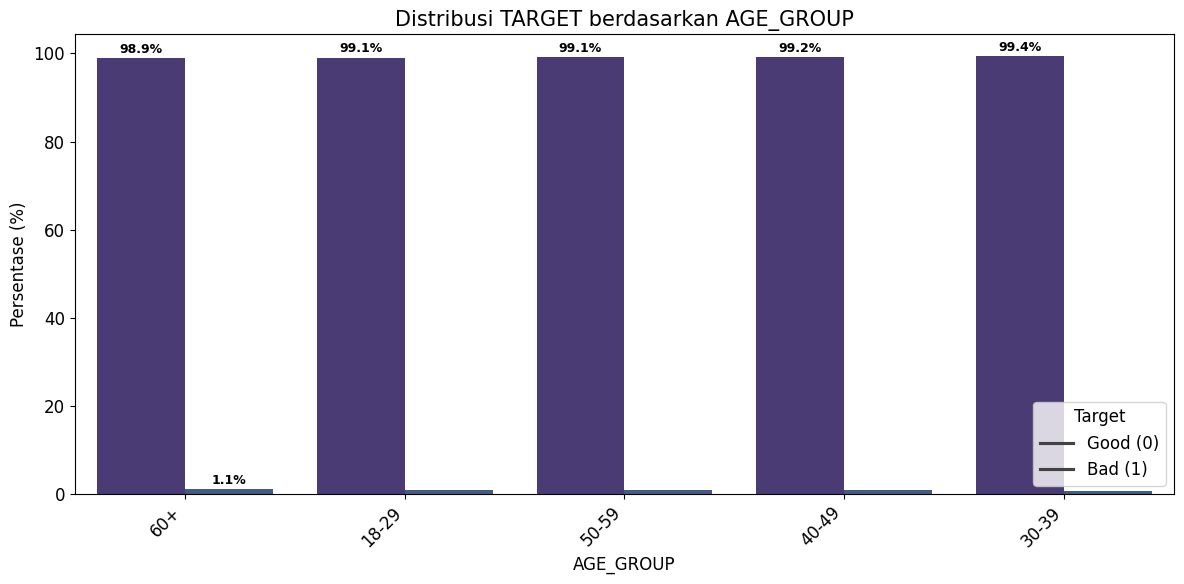

In [85]:
# 2.1 Analisis Bivariate untuk Variabel Kategorik vs Target
def categorical_vs_target(df, categorical_cols, target='TARGET'):
    """Menganalisis hubungan antara variabel kategorik dengan target."""
    
    for col in categorical_cols:
        print(f"\n{'='*50}")
        print(f"Analisis {col} vs {target}")
        print(f"{'='*50}")
        
        # Cross-tabulation
        cross_tab = pd.crosstab(df[col], df[target], normalize='index') * 100
        cross_tab_counts = pd.crosstab(df[col], df[target])
        
        print("\nDistribusi Target berdasarkan kategori (%):")
        print(cross_tab)
        
        print("\nJumlah data per kategori:")
        print(cross_tab_counts)
        
        # Chi-square test untuk memeriksa dependensi
        chi2, p, dof, expected = stats.chi2_contingency(cross_tab_counts)
        print(f"\nChi-square test untuk independensi:")
        print(f"Chi2 = {chi2:.4f}, p-value = {p:.4f}, degrees of freedom = {dof}")
        
        if p < 0.05:
            print(f"Ada hubungan yang signifikan antara {col} dan {target} (p < 0.05)")
        else:
            print(f"Tidak ada hubungan yang signifikan antara {col} dan {target} (p >= 0.05)")
        
        # Visualisasi
        plt.figure(figsize=(12, 6))
        
        # Untuk mengatur urutan kategori berdasarkan tingkat bad rate
        cat_order = cross_tab[1].sort_values(ascending=False).index
        
        # Plot stacked bar chart
        cross_tab_unstacked = cross_tab.unstack().reset_index()
        cross_tab_unstacked.columns = ['Target', 'Category', 'Percentage']
        
        # Jika kategori terlalu banyak, ambil hanya top 10
        if len(cat_order) > 10:
            top_cats = list(cat_order[:10])
            cross_tab_plot = cross_tab_unstacked[cross_tab_unstacked['Category'].isin(top_cats)]
            title_suffix = " (Top 10 Kategori)"
        else:
            cross_tab_plot = cross_tab_unstacked
            title_suffix = ""
        
        # Membuat plot
        ax = sns.barplot(x='Category', y='Percentage', hue='Target', data=cross_tab_plot,
                  order=cat_order[:10] if len(cat_order) > 10 else cat_order)
        
        # Menambahkan persentase di atas setiap bar
        # Dapatkan posisi bar dan tinggi dari plot
        bars = ax.patches
        
        # Jumlah kategori yang ditampilkan
        num_categories = len(cat_order[:10]) if len(cat_order) > 10 else len(cat_order)
        # Jumlah target (biasanya 2: good dan bad)
        num_targets = len(cross_tab_plot['Target'].unique())
        
        # Loop melalui semua bar untuk menambahkan teks
        for i, bar in enumerate(bars):
            # Dapatkan koordinat dan tinggi bar
            height = bar.get_height()
            
            # Hanya tampilkan angka jika tingginya cukup signifikan (misalnya > 1%)
            if height > 1:
                # Menentukan posisi teks
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.5,  # Posisi sedikit di atas bar
                    f'{height:.1f}%',  # Format teks dengan 1 angka desimal
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold'
                )
        
        plt.title(f'Distribusi {target} berdasarkan {col}{title_suffix}', fontsize=15)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Persentase (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Target', labels=['Good (0)', 'Bad (1)'])
        
        plt.tight_layout()
        plt.show()

# Menjalankan analisis bivariate
# Pastikan untuk menyesuaikan daftar kolom sesuai dengan dataset yang sebenarnya
categorical_cols = ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
                   'INCOME_GROUP', 'AGE_GROUP']

print("\n\n*** ANALISIS VARIABEL KATEGORIK VS TARGET ***")
categorical_vs_target(eda_df, categorical_cols)

## Numerikal vs Target



*** ANALISIS VARIABEL NUMERIK VS TARGET ***

Analisis CNT_CHILDREN vs TARGET

Statistik deskriptif berdasarkan target:
          count      mean       std  min  25%  50%  75%   max
TARGET                                                       
0       36155.0  0.430591  0.742624  0.0  0.0  0.0  1.0  19.0
1         302.0  0.397351  0.711365  0.0  0.0  0.0  1.0   4.0

Levene's test untuk kesamaan variansi:
Statistic = 0.6004, p-value = 0.4384

Independent samples t-test:
t = 0.7749, p-value = 0.4384
Tidak ada perbedaan signifikan pada rata-rata CNT_CHILDREN antara nasabah good dan bad (p >= 0.05)


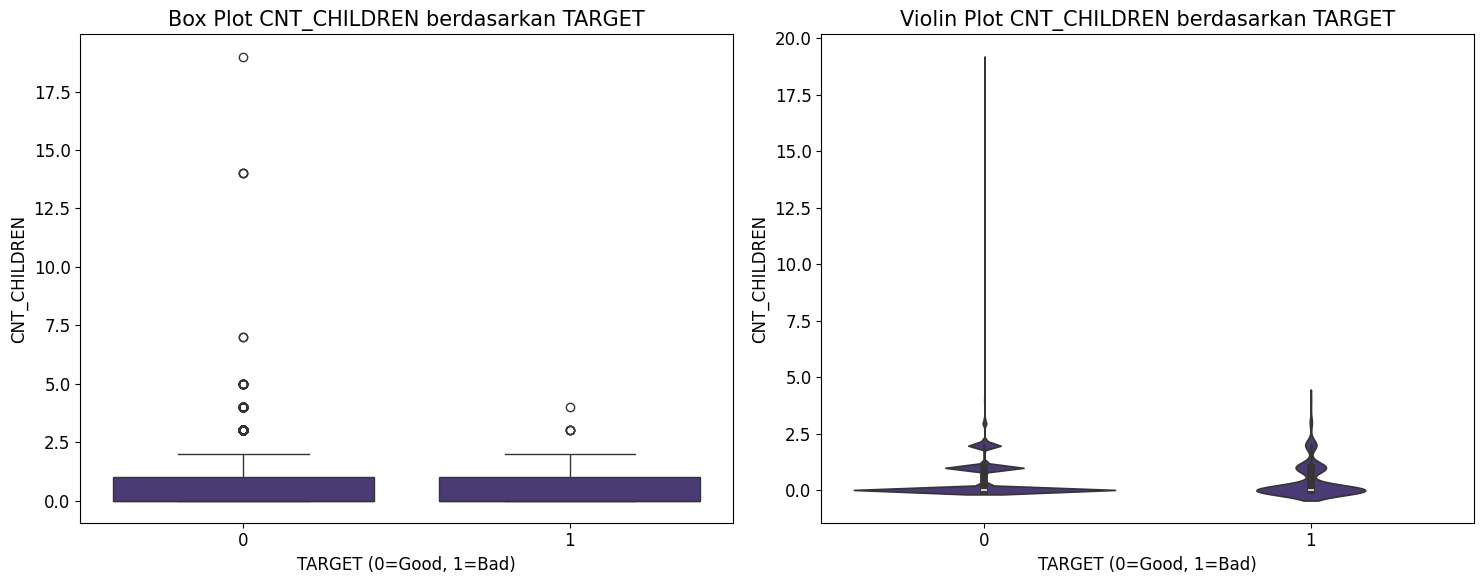

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




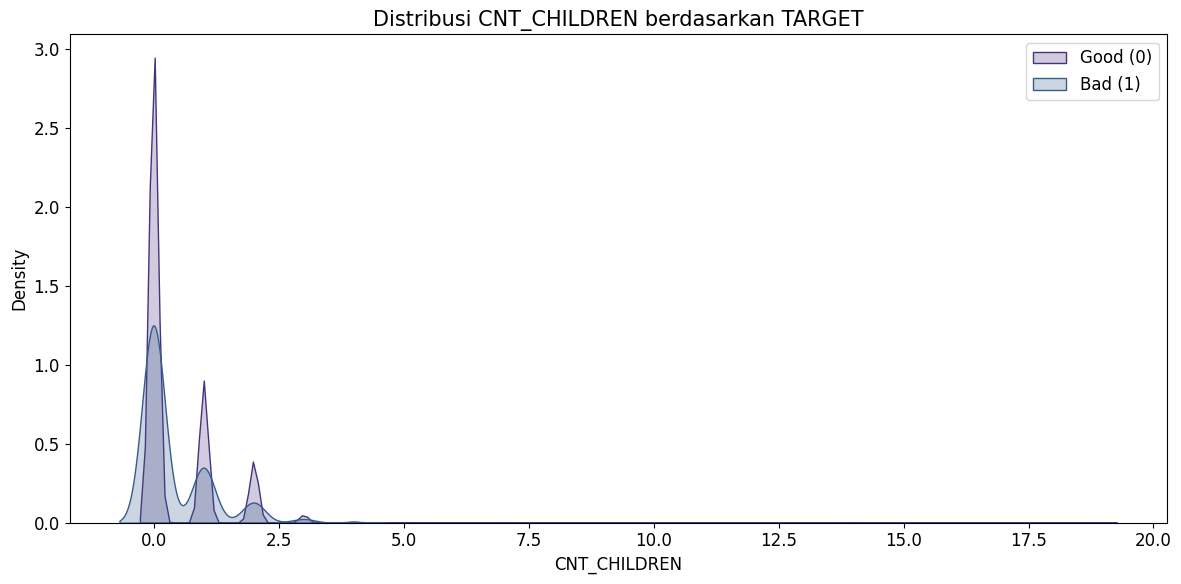


Analisis AMT_INCOME_TOTAL vs TARGET

Statistik deskriptif berdasarkan target:
          count           mean            std      min       25%       50%  \
TARGET                                                                       
0       36155.0  186646.815143  101776.487158  27000.0  121500.0  157500.0   
1         302.0  191345.364238  103368.226071  36000.0  112500.0  180000.0   

             75%        max  
TARGET                       
0       225000.0  1575000.0  
1       225000.0   675000.0  

Levene's test untuk kesamaan variansi:
Statistic = 0.8909, p-value = 0.3453

Independent samples t-test:
t = -0.7988, p-value = 0.4244
Tidak ada perbedaan signifikan pada rata-rata AMT_INCOME_TOTAL antara nasabah good dan bad (p >= 0.05)


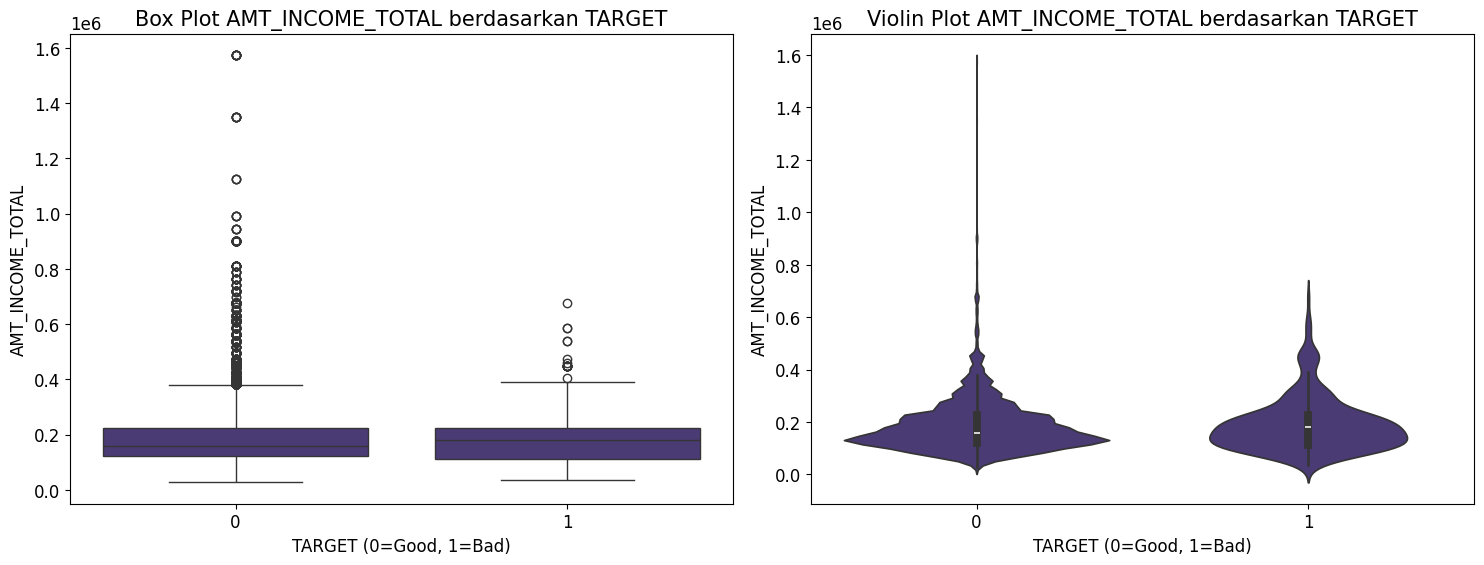

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




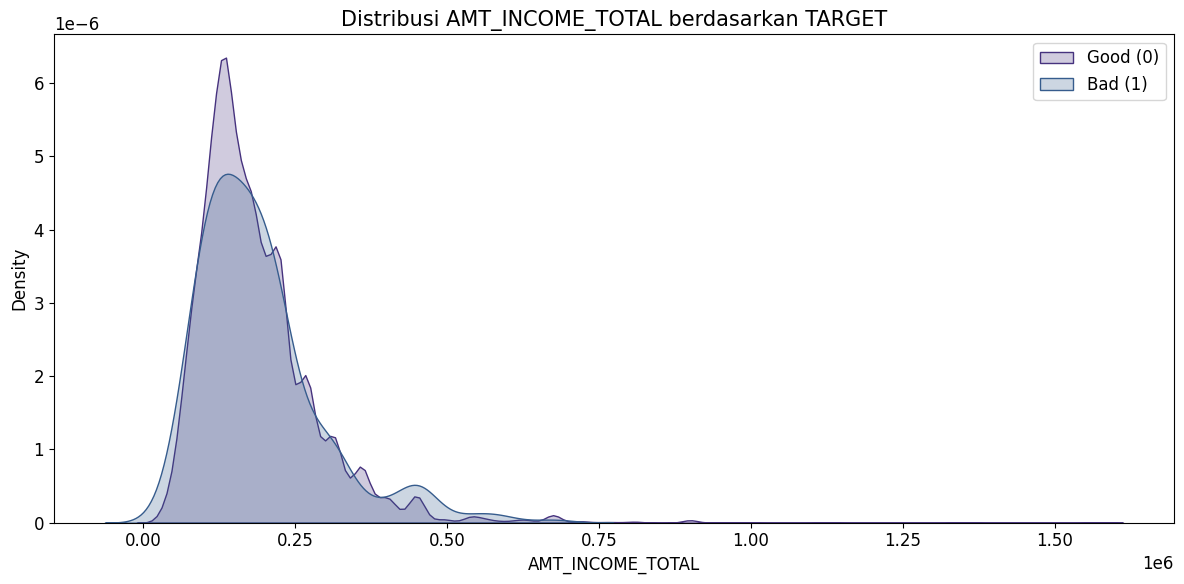


Analisis DAYS_BIRTH vs TARGET

Statistik deskriptif berdasarkan target:
          count          mean          std      min       25%      50%  \
TARGET                                                                   
0       36155.0 -15971.486627  4199.105332 -25152.0 -19435.00 -15560.0   
1         302.0 -16416.546358  4354.724957 -24611.0 -19815.75 -16413.0   

            75%     max  
TARGET                   
0      -12461.0 -7489.0  
1      -12731.0 -8907.0  

Levene's test untuk kesamaan variansi:
Statistic = 1.2343, p-value = 0.2666

Independent samples t-test:
t = 1.8337, p-value = 0.0667
Tidak ada perbedaan signifikan pada rata-rata DAYS_BIRTH antara nasabah good dan bad (p >= 0.05)


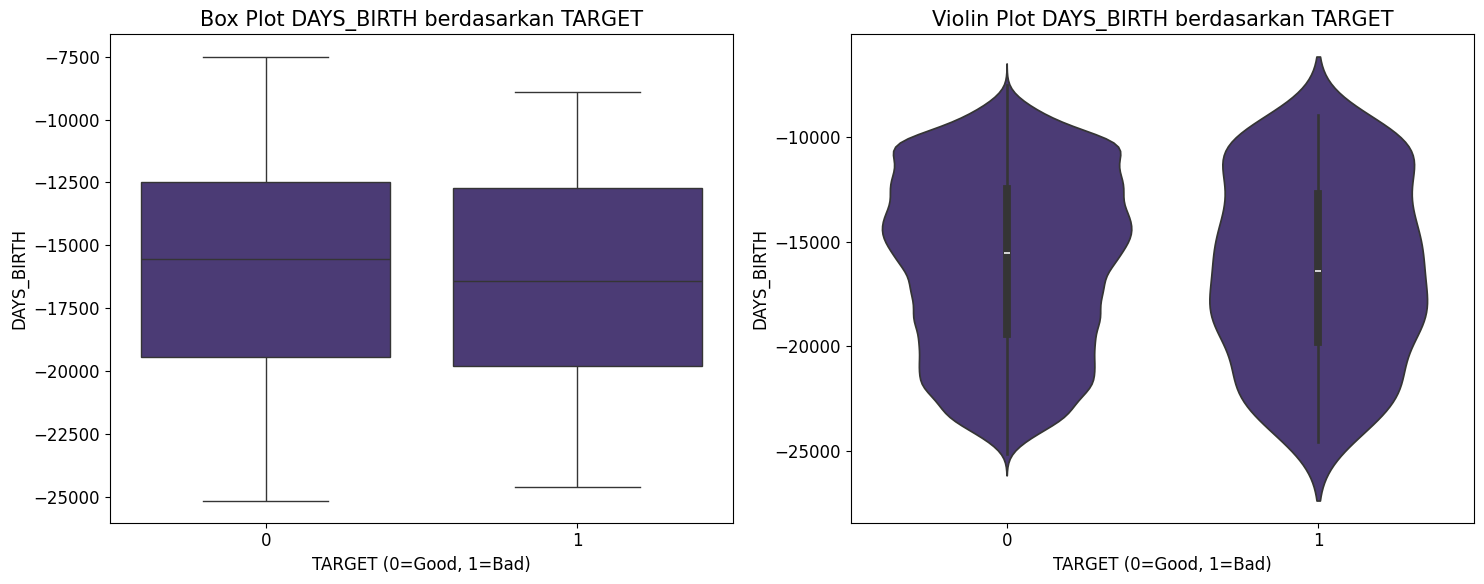

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




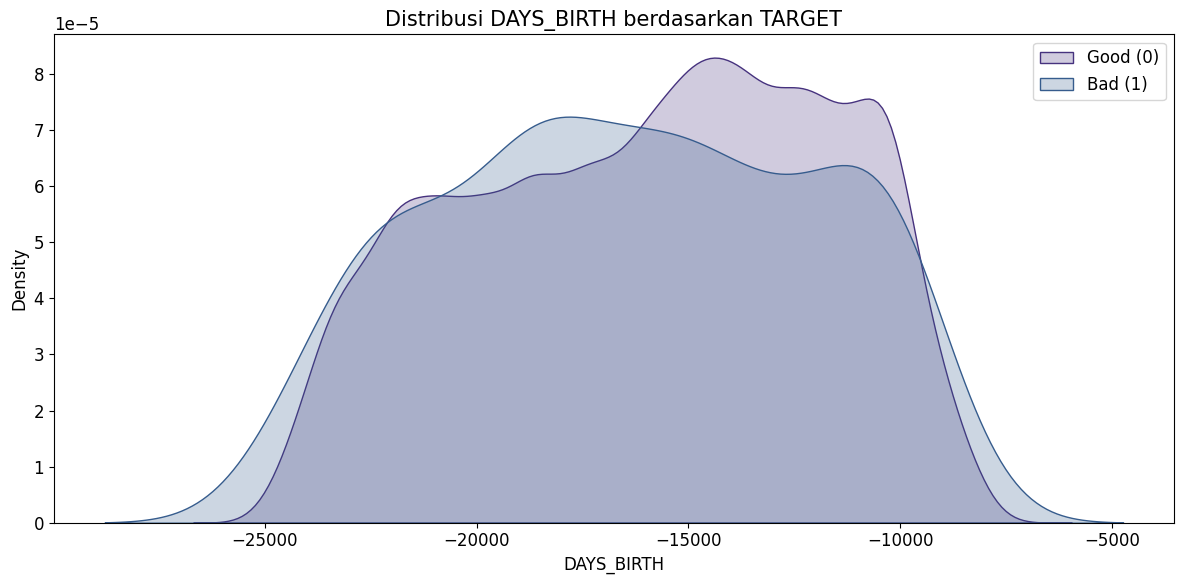


Analisis DAYS_EMPLOYED vs TARGET

Statistik deskriptif berdasarkan target:
          count          mean            std      min      25%     50%    75%  \
TARGET                                                                          
0       36155.0  59125.524962  137533.850336 -15713.0 -3153.00 -1557.0 -410.0   
1         302.0  75713.533113  150400.473611 -12827.0 -2356.25  -925.5 -186.0   

             max  
TARGET            
0       365243.0  
1       365243.0  

Levene's test untuk kesamaan variansi:
Statistic = 3.9898, p-value = 0.0458

Independent samples t-test:
t = -1.9100, p-value = 0.0571
Tidak ada perbedaan signifikan pada rata-rata DAYS_EMPLOYED antara nasabah good dan bad (p >= 0.05)


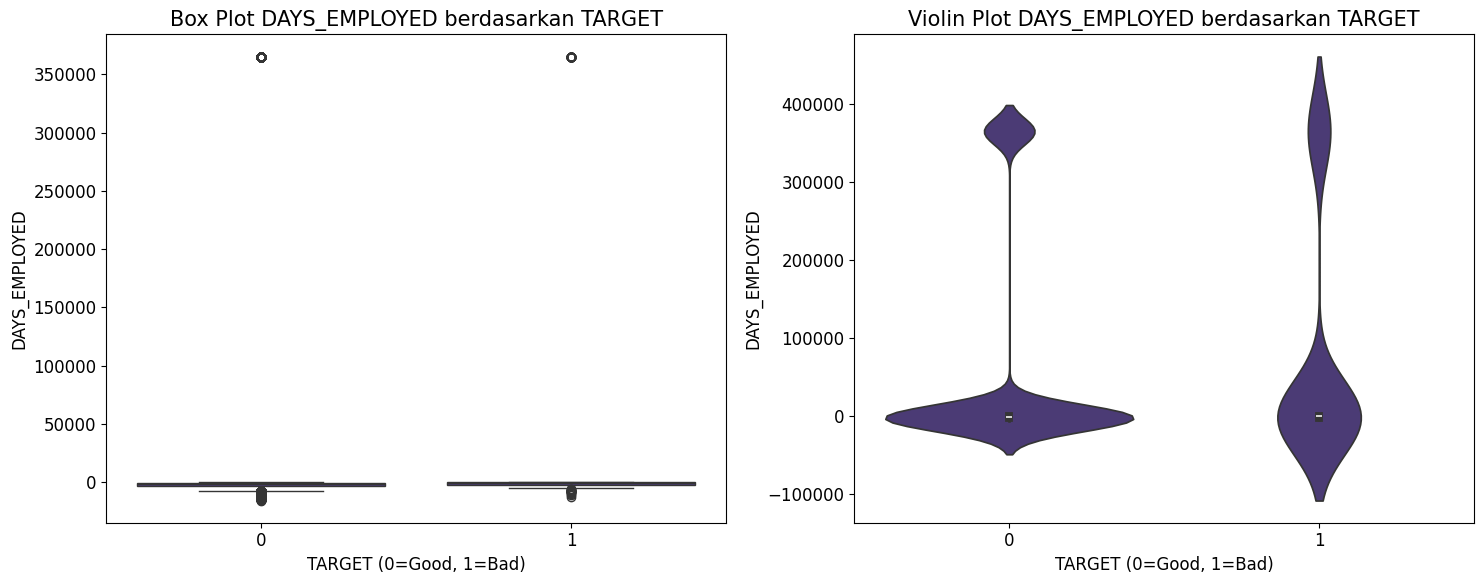

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




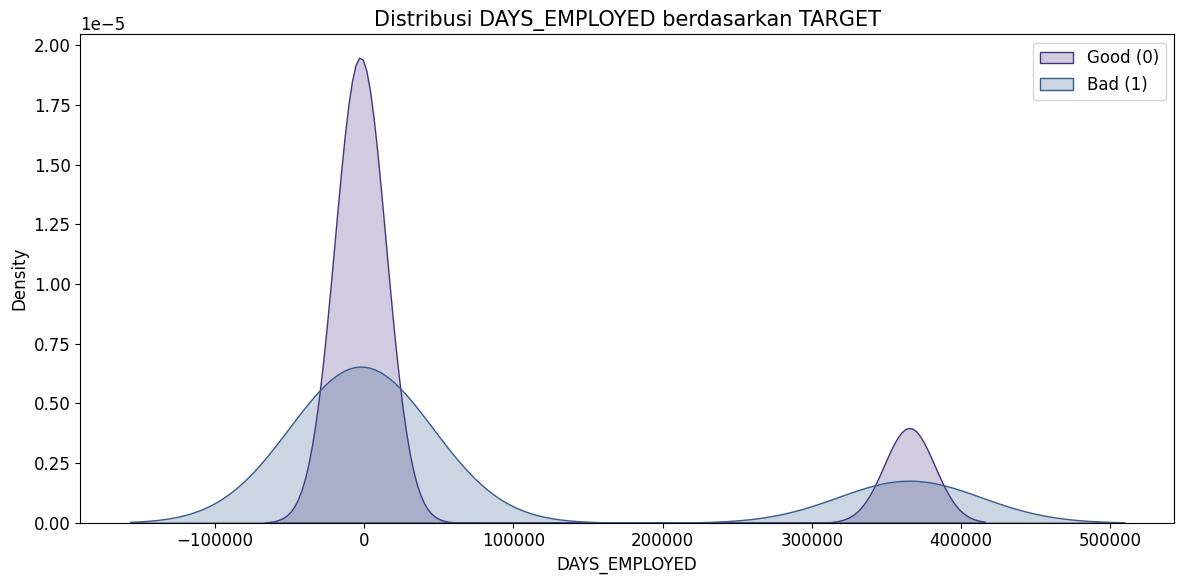


Analisis CNT_FAM_MEMBERS vs TARGET

Statistik deskriptif berdasarkan target:
          count      mean       std  min  25%  50%  75%   max
TARGET                                                       
0       36155.0  2.199281  0.911671  1.0  2.0  2.0  3.0  20.0
1         302.0  2.099338  0.909565  1.0  2.0  2.0  2.0   6.0

Levene's test untuk kesamaan variansi:
Statistic = 0.0006, p-value = 0.9804

Independent samples t-test:
t = 1.8972, p-value = 0.0578
Tidak ada perbedaan signifikan pada rata-rata CNT_FAM_MEMBERS antara nasabah good dan bad (p >= 0.05)


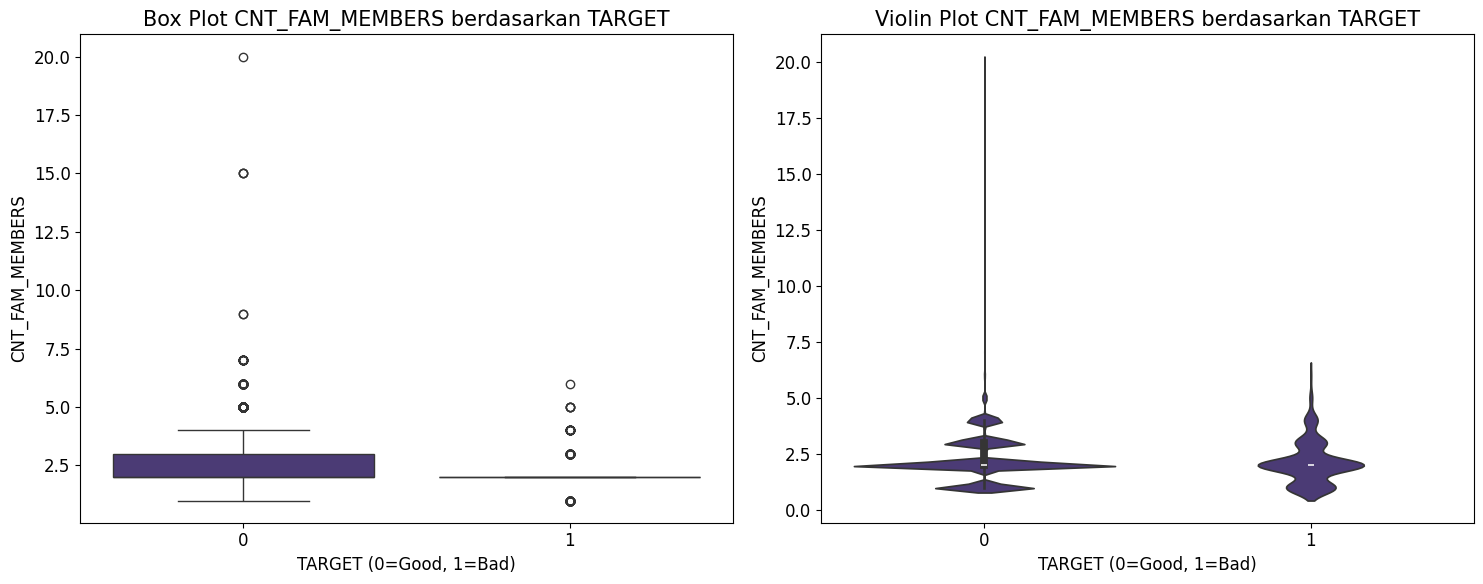

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




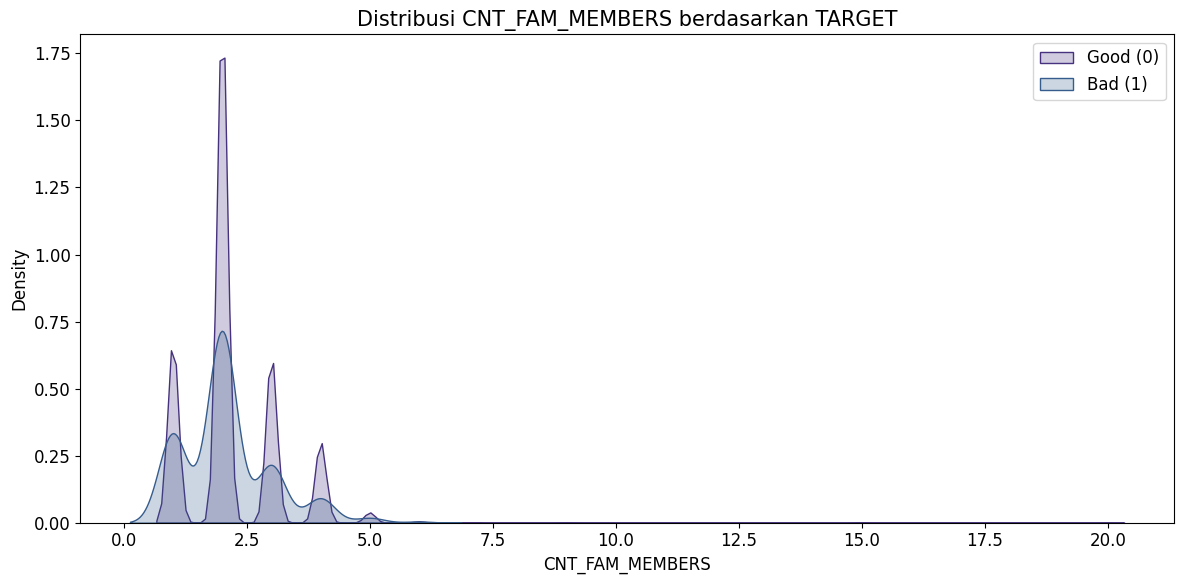


Analisis AGE vs TARGET

Statistik deskriptif berdasarkan target:
          count       mean        std   min   25%   50%   75%   max
TARGET                                                             
0       36155.0  43.757812  11.504520  20.5  34.1  42.6  53.2  68.9
1         302.0  44.977483  11.929269  24.4  34.9  45.0  54.3  67.4

Levene's test untuk kesamaan variansi:
Statistic = 1.2312, p-value = 0.2672

Independent samples t-test:
t = -1.8342, p-value = 0.0666
Tidak ada perbedaan signifikan pada rata-rata AGE antara nasabah good dan bad (p >= 0.05)


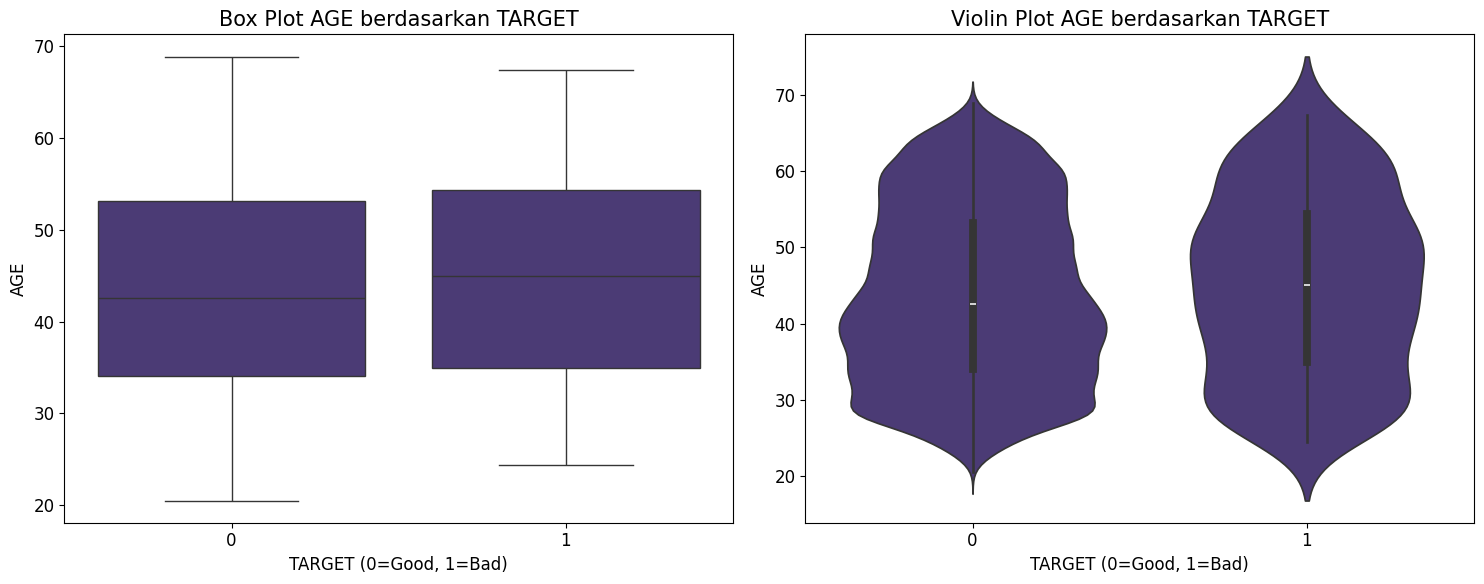

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




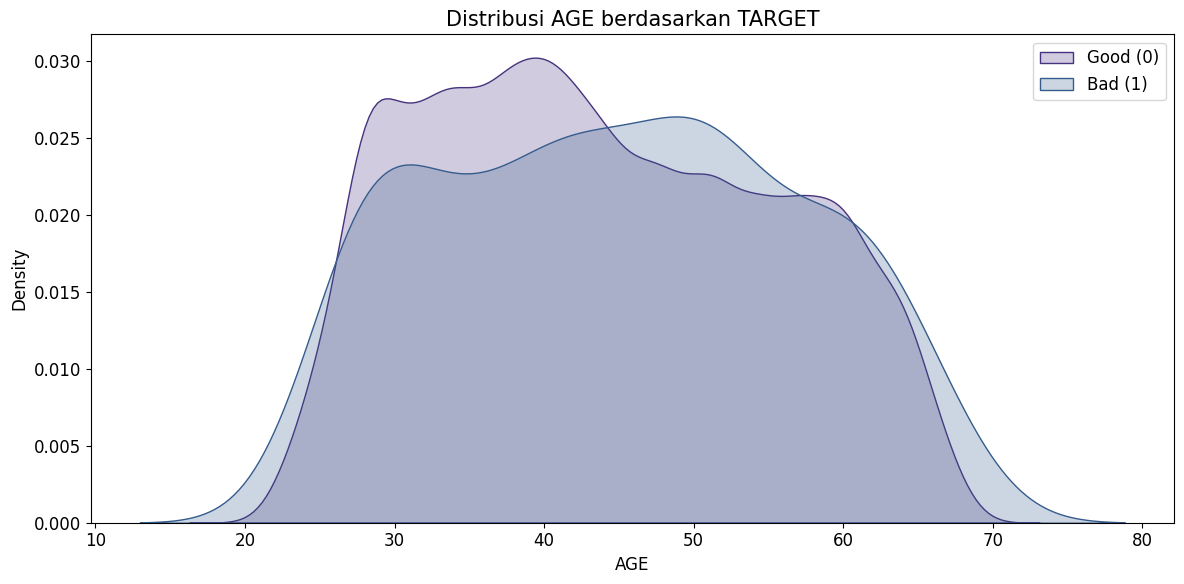


Analisis YEARS_EMPLOYED vs TARGET

Statistik deskriptif berdasarkan target:
          count      mean       std  min  25%  50%   75%   max
TARGET                                                        
0       36155.0  6.039654  6.488983  0.0  1.1  4.3  8.60  43.0
1         302.0  4.629470  5.733723  0.0  0.5  2.5  6.45  35.1

Levene's test untuk kesamaan variansi:
Statistic = 8.9016, p-value = 0.0029

Independent samples t-test:
t = 4.2514, p-value = 0.0000
Ada perbedaan signifikan pada rata-rata YEARS_EMPLOYED antara nasabah good dan bad (p < 0.05)


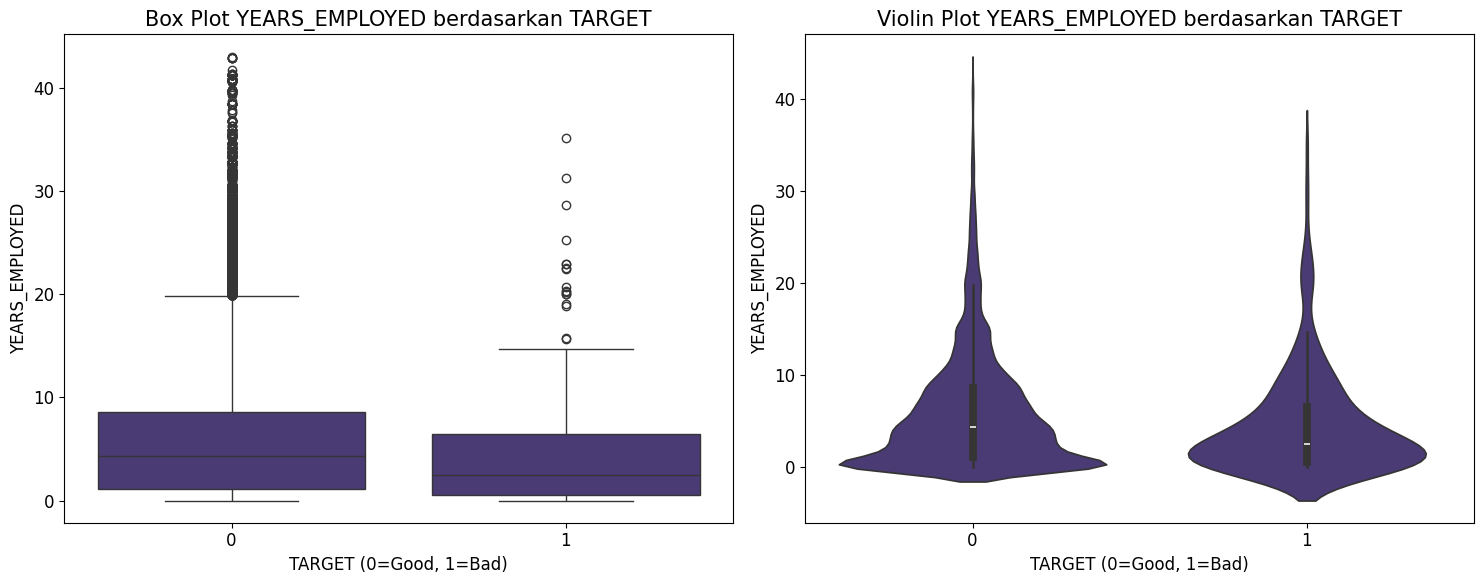

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




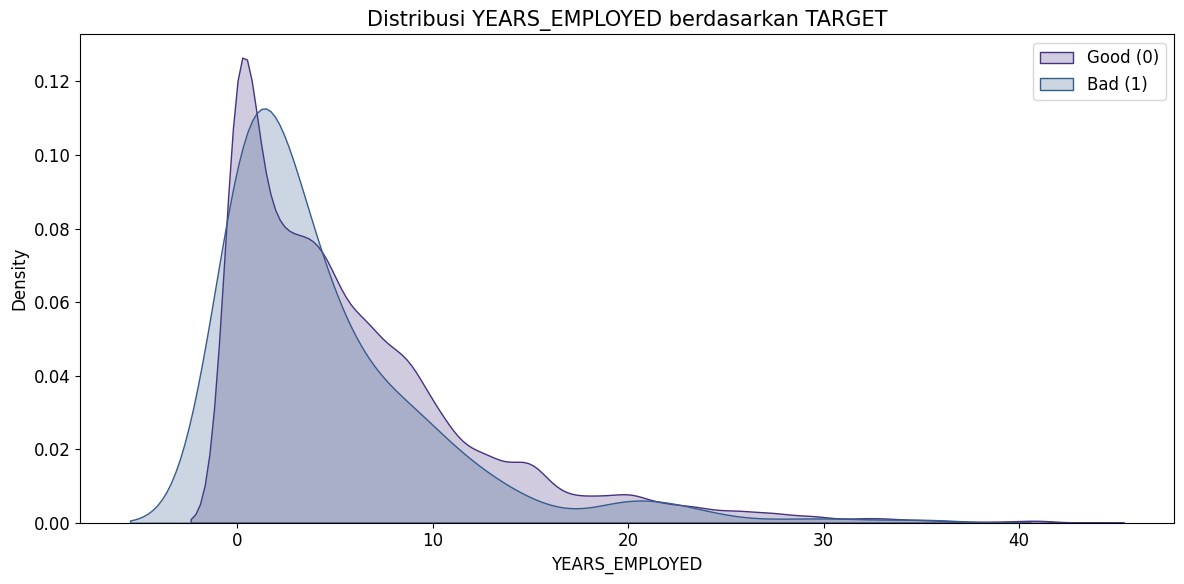


Analisis CREDIT_HISTORY_LENGTH vs TARGET

Statistik deskriptif berdasarkan target:
          count       mean        std   min   25%   50%   75%  max
TARGET                                                            
0       36155.0 -20.220246  14.851176 -60.0 -30.0 -17.0  -8.0  0.0
1         302.0 -33.758278  16.051139 -60.0 -48.0 -36.0 -19.0 -4.0

Levene's test untuk kesamaan variansi:
Statistic = 10.4540, p-value = 0.0012

Independent samples t-test:
t = 14.6051, p-value = 0.0000
Ada perbedaan signifikan pada rata-rata CREDIT_HISTORY_LENGTH antara nasabah good dan bad (p < 0.05)


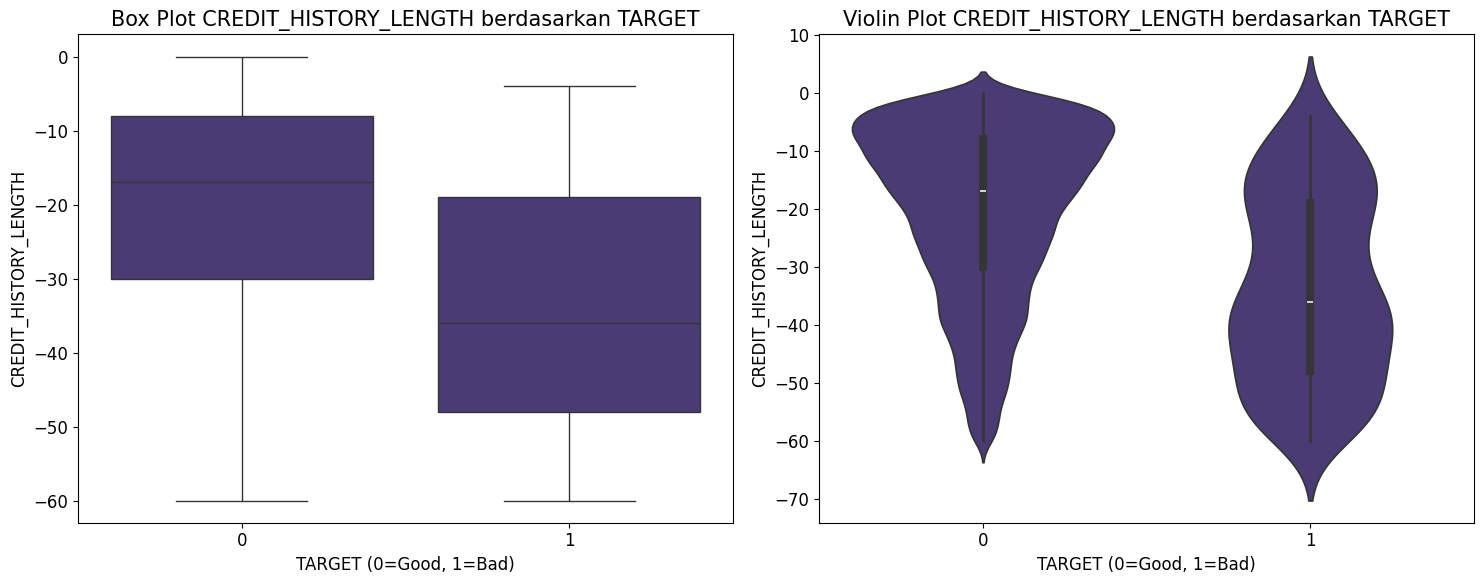

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




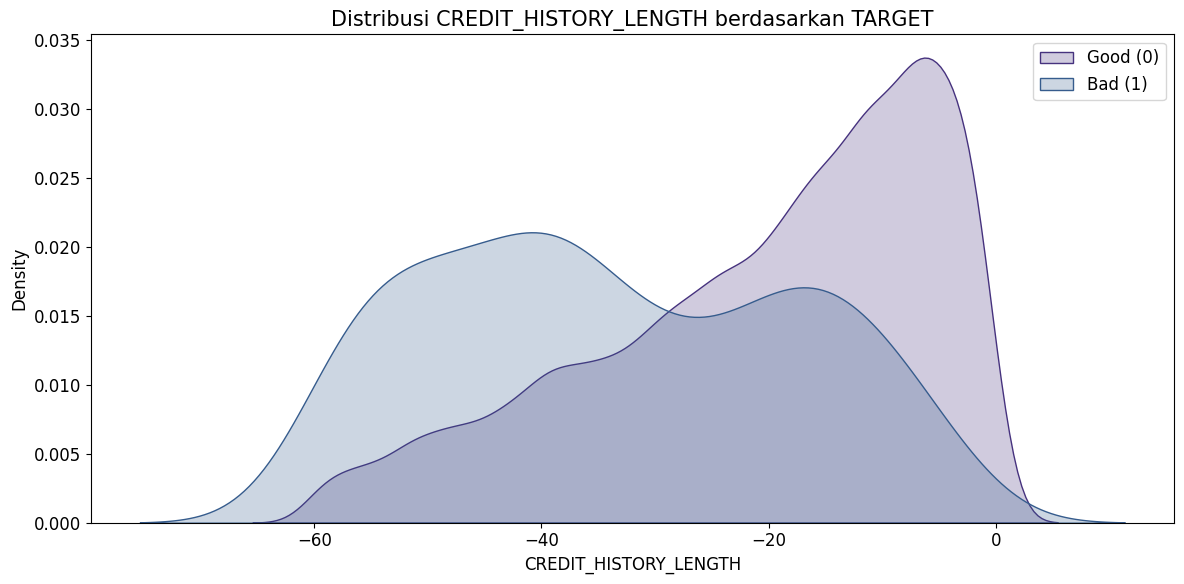


Analisis COUNT_LATE_LAST_12M vs TARGET

Statistik deskriptif berdasarkan target:
          count      mean       std  min  25%  50%    75%   max
TARGET                                                         
0       36155.0  2.721643  4.006794  0.0  0.0  0.0   5.00  13.0
1         302.0  5.043046  5.434735  0.0  0.0  2.0  11.75  13.0

Levene's test untuk kesamaan variansi:
Statistic = 82.5184, p-value = 0.0000

Independent samples t-test:
t = -7.4061, p-value = 0.0000
Ada perbedaan signifikan pada rata-rata COUNT_LATE_LAST_12M antara nasabah good dan bad (p < 0.05)


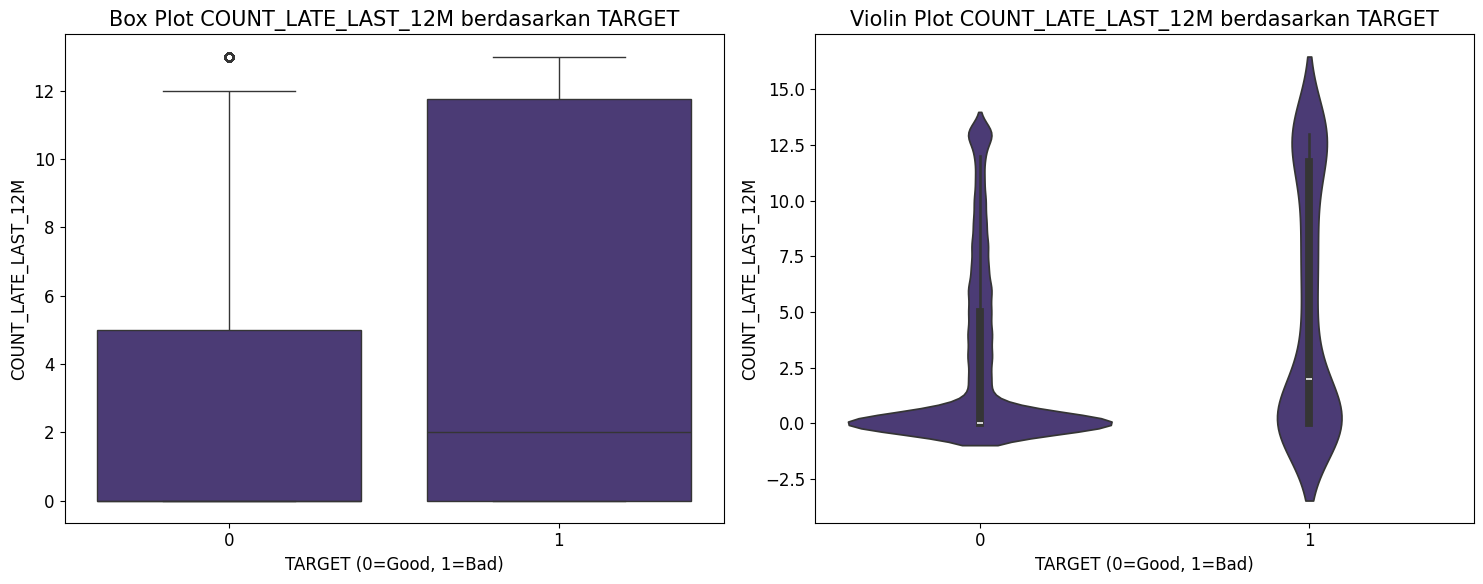

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




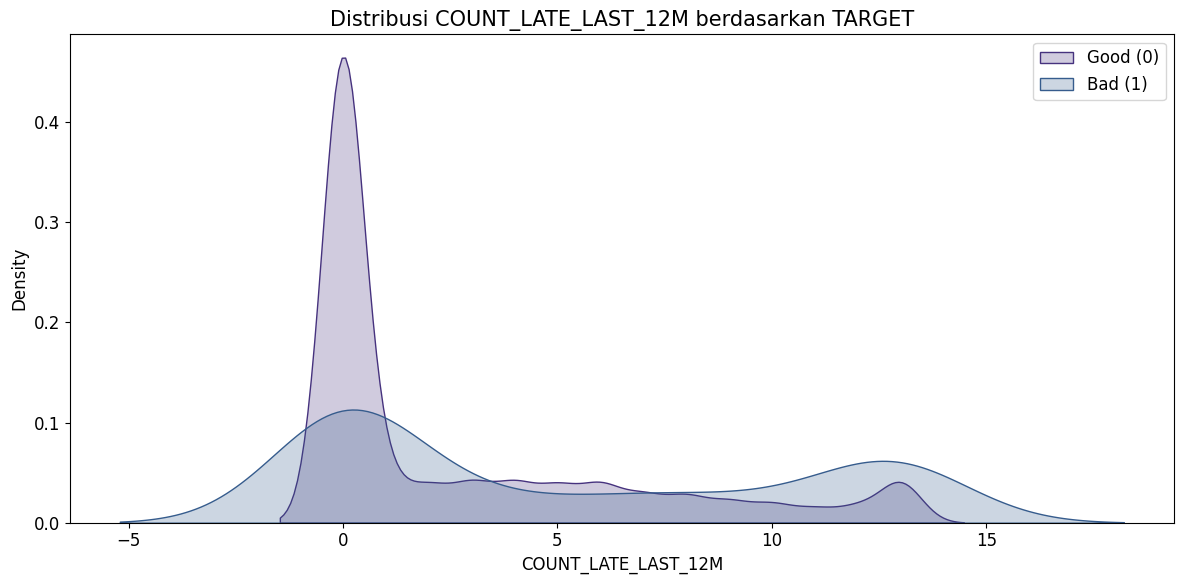


Analisis EDUCATION_RANK vs TARGET

Statistik deskriptif berdasarkan target:
          count      mean       std  min  25%  50%  75%  max
TARGET                                                      
0       36155.0  1.571567  0.900627  0.0  1.0  1.0  3.0  4.0
1         302.0  1.645695  0.938454  0.0  1.0  1.0  3.0  3.0

Levene's test untuk kesamaan variansi:
Statistic = 3.8159, p-value = 0.0508

Independent samples t-test:
t = -1.4239, p-value = 0.1545
Tidak ada perbedaan signifikan pada rata-rata EDUCATION_RANK antara nasabah good dan bad (p >= 0.05)


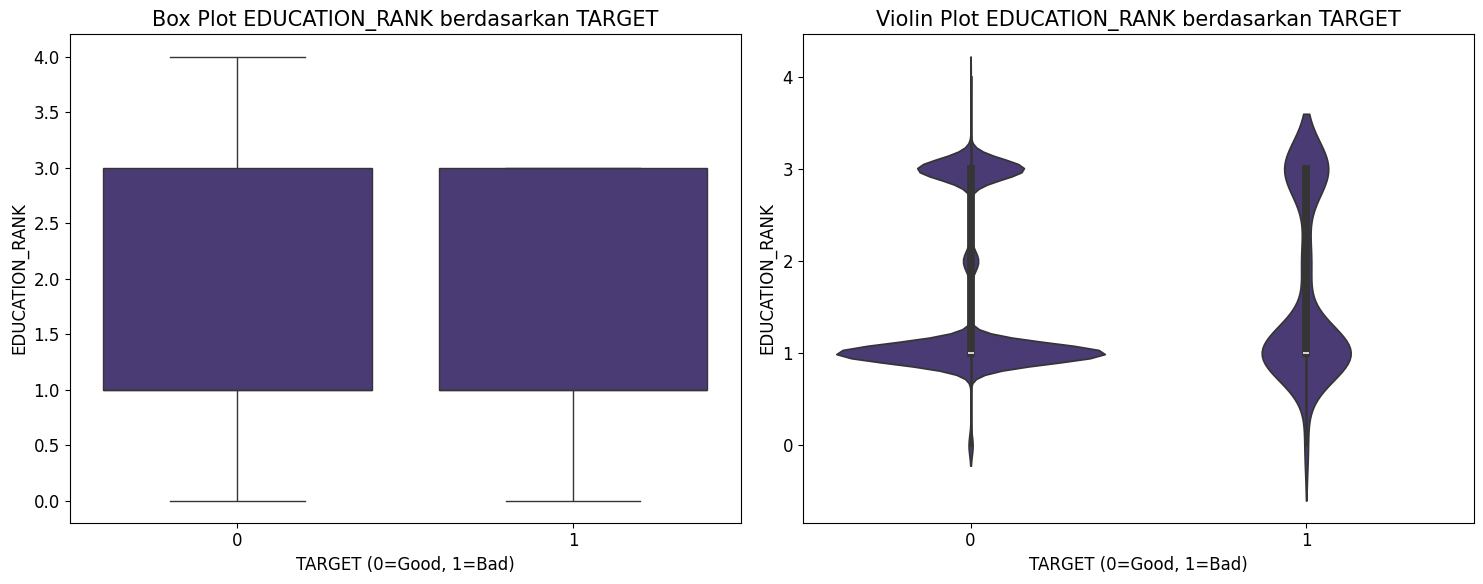

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:60: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3944937484.py:61: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




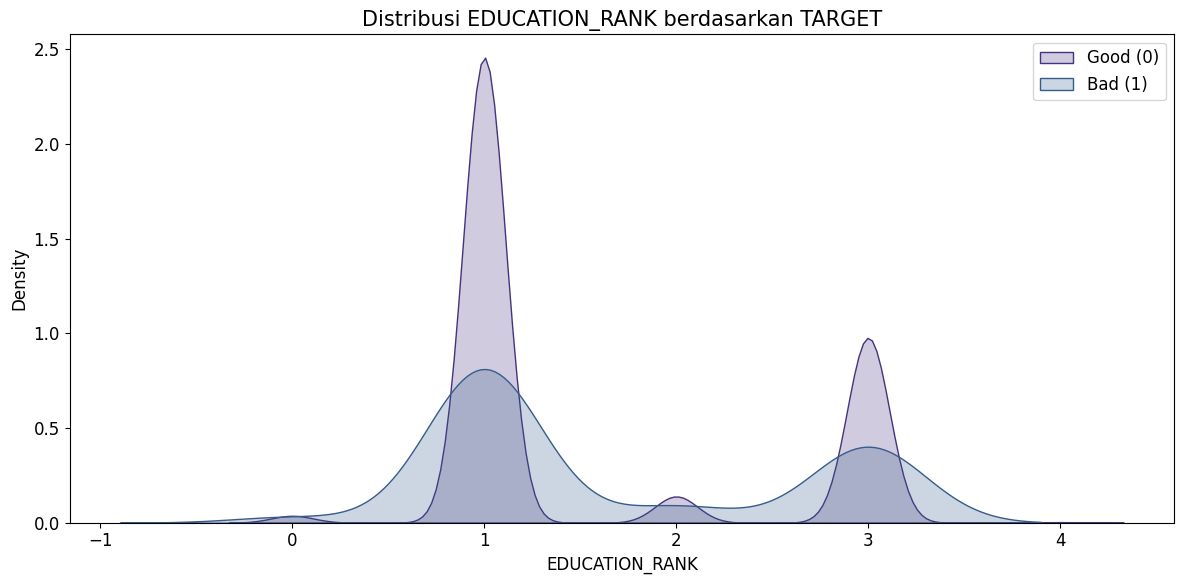

In [74]:

# 2.2 Analisis Bivariate untuk Variabel Numerik vs Target
def numeric_vs_target(df, numeric_cols, target='TARGET'):
    """Menganalisis hubungan antara variabel numerik dengan target."""
    
    for col in numeric_cols:
        print(f"\n{'='*50}")
        print(f"Analisis {col} vs {target}")
        print(f"{'='*50}")
        
        # Statistik deskriptif berdasarkan target
        desc_by_target = df.groupby(target)[col].describe()
        print("\nStatistik deskriptif berdasarkan target:")
        print(desc_by_target)
        
        # T-test untuk membandingkan mean antara dua kelompok
        good = df[df[target] == 0][col].dropna()
        bad = df[df[target] == 1][col].dropna()
        
        try:
            # Levene's test untuk memeriksa equal variance
            levene_stat, levene_p = stats.levene(good, bad)
            print(f"\nLevene's test untuk kesamaan variansi:")
            print(f"Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")
            
            equal_var = levene_p >= 0.05
            
            # T-test
            t_stat, t_p = stats.ttest_ind(good, bad, equal_var=equal_var)
            print(f"\nIndependent samples t-test:")
            print(f"t = {t_stat:.4f}, p-value = {t_p:.4f}")
            
            if t_p < 0.05:
                print(f"Ada perbedaan signifikan pada rata-rata {col} antara nasabah good dan bad (p < 0.05)")
            else:
                print(f"Tidak ada perbedaan signifikan pada rata-rata {col} antara nasabah good dan bad (p >= 0.05)")
                
        except Exception as e:
            print(f"Tidak dapat melakukan t-test: {str(e)}")
        
        # Visualisasi
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Box plot
        sns.boxplot(x=target, y=col, data=df, ax=ax1)
        ax1.set_title(f'Box Plot {col} berdasarkan {target}', fontsize=15)
        ax1.set_xlabel(f'{target} (0=Good, 1=Bad)', fontsize=12)
        ax1.set_ylabel(col, fontsize=12)
        
        # Violin plot
        sns.violinplot(x=target, y=col, data=df, ax=ax2)
        ax2.set_title(f'Violin Plot {col} berdasarkan {target}', fontsize=15)
        ax2.set_xlabel(f'{target} (0=Good, 1=Bad)', fontsize=12)
        ax2.set_ylabel(col, fontsize=12)
        
        plt.tight_layout()
        plt.show()
        
        # KDE plot untuk distribusi
        plt.figure(figsize=(12, 6))
        sns.kdeplot(good, label='Good (0)', shade=True)
        sns.kdeplot(bad, label='Bad (1)', shade=True)
        plt.title(f'Distribusi {col} berdasarkan {target}', fontsize=15)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.show()


numeric_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
               'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED', 'CREDIT_HISTORY_LENGTH',
               'COUNT_LATE_LAST_12M', 'EDUCATION_RANK']


print("\n\n*** ANALISIS VARIABEL NUMERIK VS TARGET ***")
numeric_vs_target(eda_df, numeric_cols)



## Korelasi Antara Variabel Numerik



*** ANALISIS KORELASI ANTAR VARIABEL NUMERIK ***

Analisis Korelasi antar Variabel Numerik

Korelasi kuat (|r| > 0.5) antar variabel numerik:
DAYS_BIRTH & AGE: r = -1.0000
CNT_CHILDREN & CNT_FAM_MEMBERS: r = 0.8891
DAYS_EMPLOYED & AGE: r = 0.6162
DAYS_BIRTH & DAYS_EMPLOYED: r = -0.6162


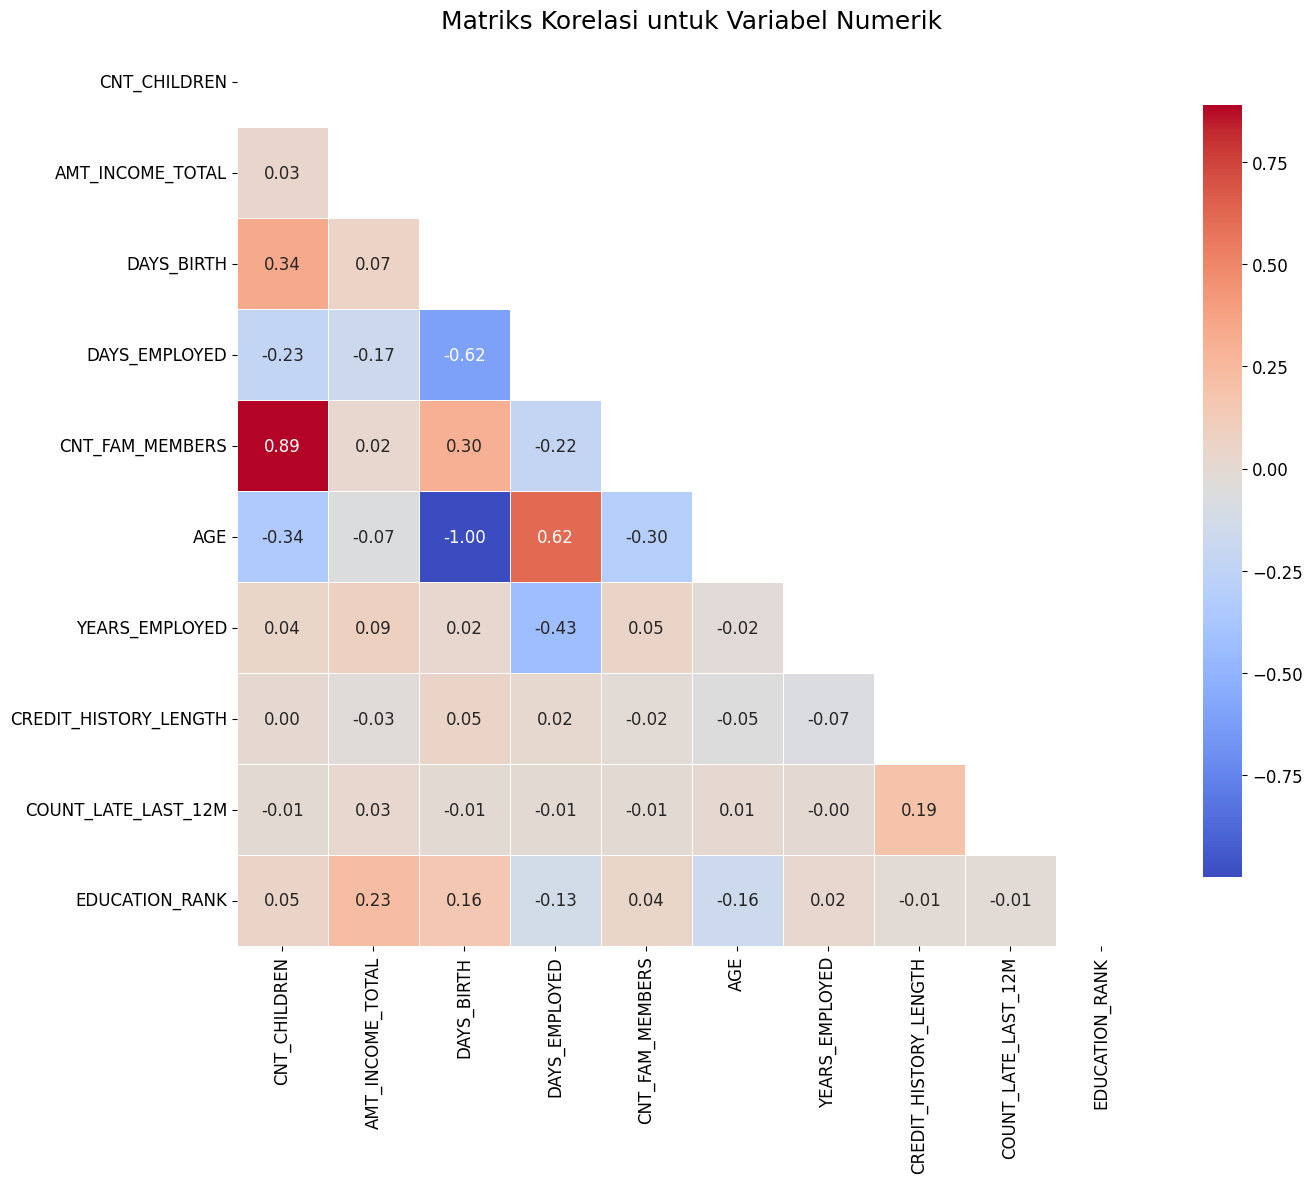


Top 15 korelasi antar variabel numerik:
DAYS_BIRTH & AGE: r = 1.0000
AGE & DAYS_BIRTH: r = 1.0000
CNT_FAM_MEMBERS & CNT_CHILDREN: r = 0.8891
CNT_CHILDREN & CNT_FAM_MEMBERS: r = 0.8891
DAYS_EMPLOYED & AGE: r = 0.6162
AGE & DAYS_EMPLOYED: r = 0.6162
DAYS_BIRTH & DAYS_EMPLOYED: r = 0.6162
DAYS_EMPLOYED & DAYS_BIRTH: r = 0.6162
YEARS_EMPLOYED & DAYS_EMPLOYED: r = 0.4323
DAYS_EMPLOYED & YEARS_EMPLOYED: r = 0.4323
CNT_CHILDREN & DAYS_BIRTH: r = 0.3394
DAYS_BIRTH & CNT_CHILDREN: r = 0.3394
AGE & CNT_CHILDREN: r = 0.3393
CNT_CHILDREN & AGE: r = 0.3393
AGE & CNT_FAM_MEMBERS: r = 0.3040


In [75]:
# 2.3 Korelasi antara variabel numerik
def correlation_analysis(df, numeric_cols):
    """Menganalisis korelasi antara variabel numerik."""
    
    print(f"\n{'='*50}")
    print(f"Analisis Korelasi antar Variabel Numerik")
    print(f"{'='*50}")
    
    # Menghitung korelasi
    corr_matrix = df[numeric_cols].corr()
    
    # Menampilkan korelasi yang kuat (abs > 0.5)
    strong_corr = (corr_matrix.abs() > 0.5) & (corr_matrix != 1.0)
    strong_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if strong_corr.iloc[i, j]:
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                corr_val = corr_matrix.iloc[i, j]
                strong_pairs.append((col1, col2, corr_val))
    
    if strong_pairs:
        print("\nKorelasi kuat (|r| > 0.5) antar variabel numerik:")
        for col1, col2, corr_val in sorted(strong_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"{col1} & {col2}: r = {corr_val:.4f}")
    else:
        print("\nTidak ditemukan korelasi yang kuat (|r| > 0.5) antar variabel numerik.")
    
    # Visualisasi
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
               square=True, linewidths=.5, cbar_kws={"shrink": .8})
    plt.title('Matriks Korelasi untuk Variabel Numerik', fontsize=18)
    plt.tight_layout()
    plt.show()
    
    # Detail top correlations
    flat_corr = corr_matrix.unstack()
    flat_corr = flat_corr[flat_corr != 1.0]  # Remove self-correlations
    top_corr = flat_corr.abs().sort_values(ascending=False)[:15]
    
    print("\nTop 15 korelasi antar variabel numerik:")
    for (idx1, idx2), value in top_corr.items():
        print(f"{idx1} & {idx2}: r = {value:.4f}")

print("\n\n*** ANALISIS KORELASI ANTAR VARIABEL NUMERIK ***")
correlation_analysis(eda_df, numeric_cols)

## Binary vs Target



*** ANALISIS VARIABEL BINARY VS TARGET ***

Analisis FLAG_OWN_CAR vs TARGET

Distribusi Target berdasarkan nilai binary (%):
TARGET                0         1
FLAG_OWN_CAR                     
0             99.137702  0.862298
1             99.227046  0.772954

Jumlah data per nilai binary:
TARGET            0    1
FLAG_OWN_CAR            
0             22419  195
1             13736  107

Chi-square test untuk independensi:
Chi2 = 0.7291, p-value = 0.3932, degrees of freedom = 1
Tidak ada hubungan yang signifikan antara FLAG_OWN_CAR dan TARGET (p >= 0.05)


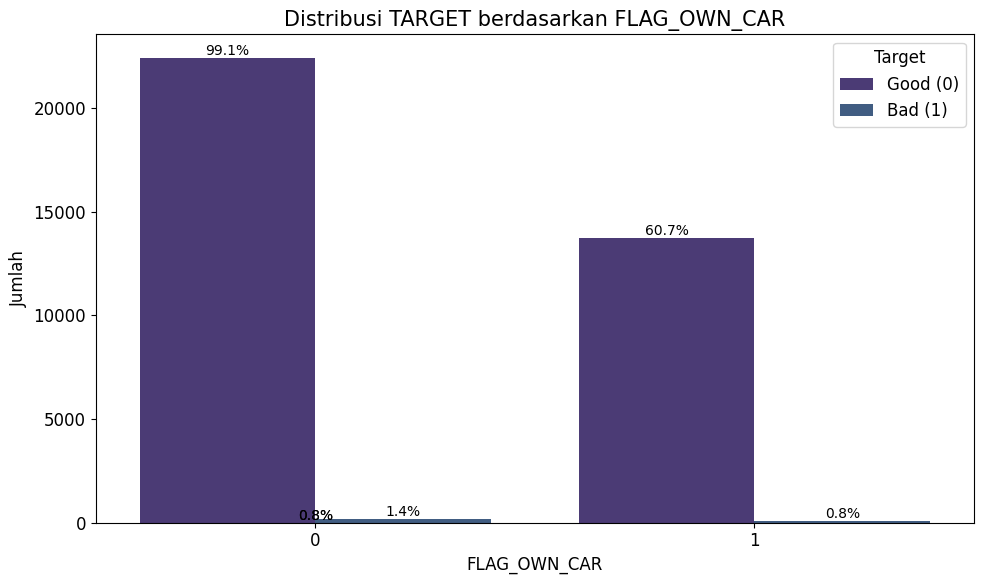


Analisis FLAG_OWN_REALTY vs TARGET

Distribusi Target berdasarkan nilai binary (%):
TARGET                   0         1
FLAG_OWN_REALTY                     
0                98.979165  1.020835
1                99.265486  0.734514

Jumlah data per nilai binary:
TARGET               0    1
FLAG_OWN_REALTY            
0                11829  122
1                24326  180

Chi-square test untuk independensi:
Chi2 = 7.6718, p-value = 0.0056, degrees of freedom = 1
Ada hubungan yang signifikan antara FLAG_OWN_REALTY dan TARGET (p < 0.05)


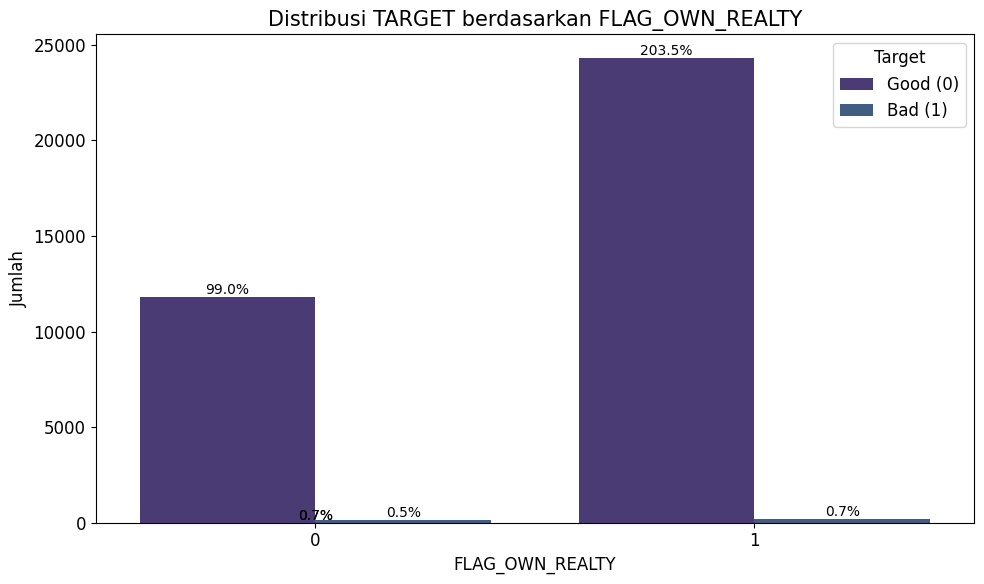


Analisis FLAG_WORK_PHONE vs TARGET

Distribusi Target berdasarkan nilai binary (%):
TARGET                   0         1
FLAG_WORK_PHONE                     
0                99.188950  0.811050
1                99.112138  0.887862

Jumlah data per nilai binary:
TARGET               0    1
FLAG_WORK_PHONE            
0                28006  229
1                 8149   73

Chi-square test untuk independensi:
Chi2 = 0.3686, p-value = 0.5438, degrees of freedom = 1
Tidak ada hubungan yang signifikan antara FLAG_WORK_PHONE dan TARGET (p >= 0.05)


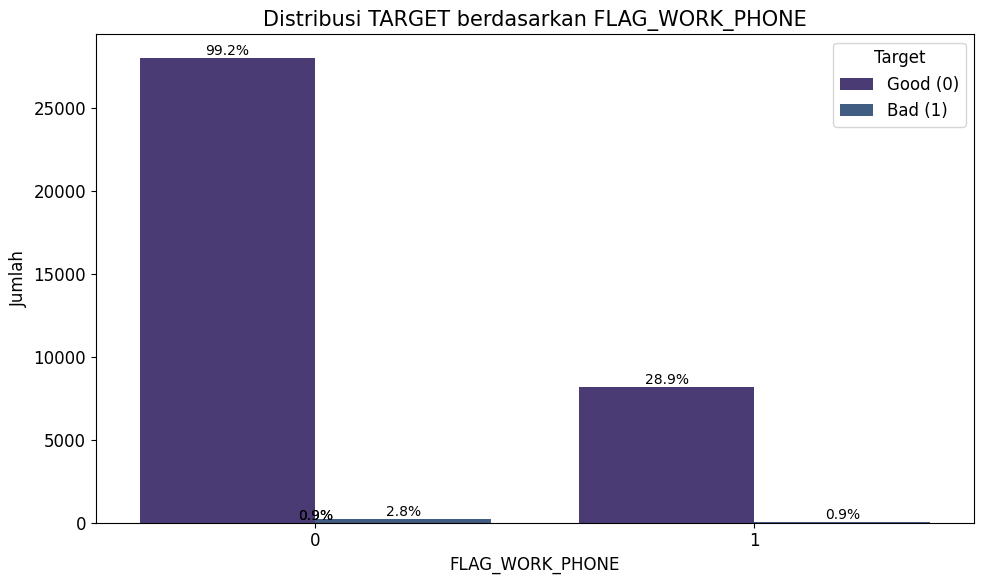


Analisis FLAG_PHONE vs TARGET

Distribusi Target berdasarkan nilai binary (%):
TARGET              0         1
FLAG_PHONE                     
0           99.218173  0.781827
1           99.060290  0.939710

Jumlah data per nilai binary:
TARGET          0    1
FLAG_PHONE            
0           25508  201
1           10647  101

Chi-square test untuk independensi:
Chi2 = 2.1116, p-value = 0.1462, degrees of freedom = 1
Tidak ada hubungan yang signifikan antara FLAG_PHONE dan TARGET (p >= 0.05)


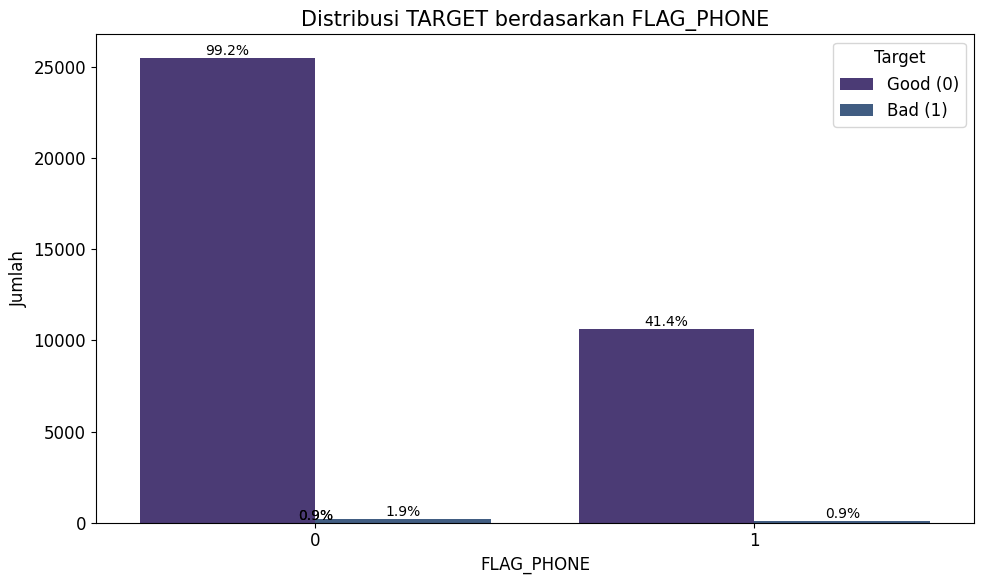


Analisis FLAG_EMAIL vs TARGET

Distribusi Target berdasarkan nilai binary (%):
TARGET              0         1
FLAG_EMAIL                     
0           99.180377  0.819623
1           99.082849  0.917151

Jumlah data per nilai binary:
TARGET          0    1
FLAG_EMAIL            
0           32914  272
1            3241   30

Chi-square test untuk independensi:
Chi2 = 0.2362, p-value = 0.6269, degrees of freedom = 1
Tidak ada hubungan yang signifikan antara FLAG_EMAIL dan TARGET (p >= 0.05)


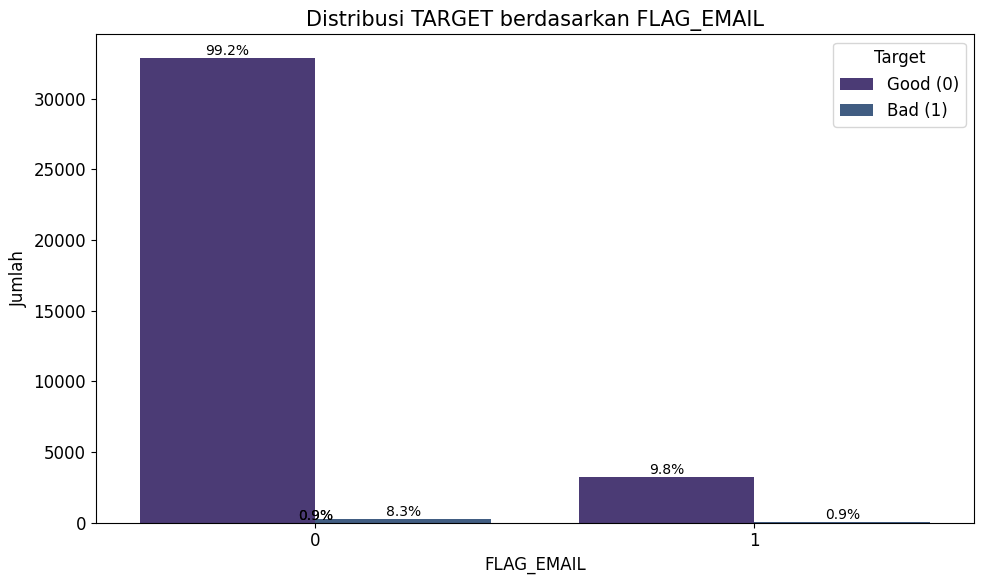

In [76]:
# 2.4 Analisis Bivariate untuk Variabel Binary vs Target
def binary_vs_target(df, binary_cols, target='TARGET'):
    """Menganalisis hubungan antara variabel binary dengan target."""
    
    for col in binary_cols:
        if col == target:  # Skip if the column is the target itself
            continue
            
        print(f"\n{'='*50}")
        print(f"Analisis {col} vs {target}")
        print(f"{'='*50}")
        
        # Cross-tabulation
        cross_tab = pd.crosstab(df[col], df[target], normalize='index') * 100
        cross_tab_counts = pd.crosstab(df[col], df[target])
        
        print("\nDistribusi Target berdasarkan nilai binary (%):")
        print(cross_tab)
        
        print("\nJumlah data per nilai binary:")
        print(cross_tab_counts)
        
        # Chi-square test untuk memeriksa dependensi
        chi2, p, dof, expected = stats.chi2_contingency(cross_tab_counts)
        print(f"\nChi-square test untuk independensi:")
        print(f"Chi2 = {chi2:.4f}, p-value = {p:.4f}, degrees of freedom = {dof}")
        
        if p < 0.05:
            print(f"Ada hubungan yang signifikan antara {col} dan {target} (p < 0.05)")
        else:
            print(f"Tidak ada hubungan yang signifikan antara {col} dan {target} (p >= 0.05)")
        
        # Visualisasi
        plt.figure(figsize=(10, 6))
        
        # Plot grouped bar chart
        ax = sns.countplot(x=col, hue=target, data=df)
        plt.title(f'Distribusi {target} berdasarkan {col}', fontsize=15)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Jumlah', fontsize=12)
        plt.legend(title='Target', labels=['Good (0)', 'Bad (1)'])
        
        # Menambahkan persentase di atas bar
        for i, p in enumerate(ax.patches):
            num_target_classes = len(cross_tab_counts.columns)
            group_idx = i // num_target_classes
            if group_idx < len(cross_tab_counts):
                total = cross_tab_counts.iloc[group_idx].sum()
                percentage = 100 * p.get_height() / total if total > 0 else 0
                
            ax.annotate(f"{percentage:.1f}%", 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=10)

        
        plt.tight_layout()
        plt.show()
        

binary_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE',
              'FLAG_PHONE', 'FLAG_EMAIL']

print("\n\n*** ANALISIS VARIABEL BINARY VS TARGET ***")
binary_vs_target(eda_df, binary_cols)

# **Multivariate**

In [77]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



*** ANALISIS INTERAKSI ANTAR VARIABEL KATEGORIK ***

Analisis Interaksi CODE_GENDER & NAME_EDUCATION_TYPE terhadap TARGET

Bad Rate (%) berdasarkan kombinasi kategori:
NAME_EDUCATION_TYPE  Academic degree  Higher education  Incomplete higher  \
CODE_GENDER                                                                 
F                                0.0          0.866059           1.704545   
M                                0.0          1.041996           0.943396   

NAME_EDUCATION_TYPE  Lower secondary  Secondary / secondary special  
CODE_GENDER                                                          
F                           2.459016                       0.645161  
M                           0.769231                       0.939941  

Jumlah data per kombinasi kategori:
NAME_EDUCATION_TYPE  Academic degree  Higher education  Incomplete higher  \
CODE_GENDER                                                                 
F                                 24              

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3804295617.py:10: FutureWarning:

The provided callable <function mean at 0x000001981D758F40> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



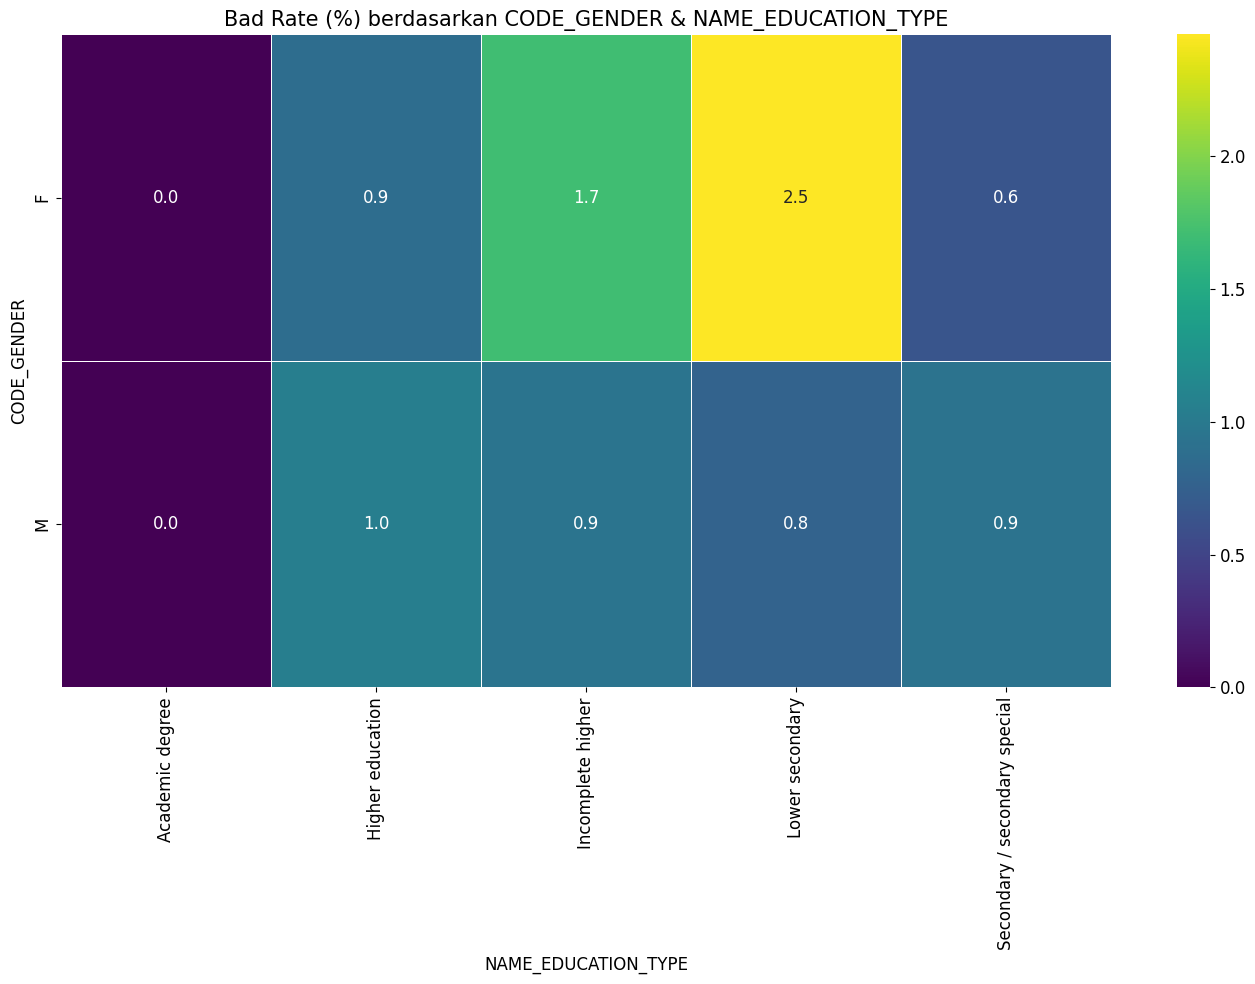

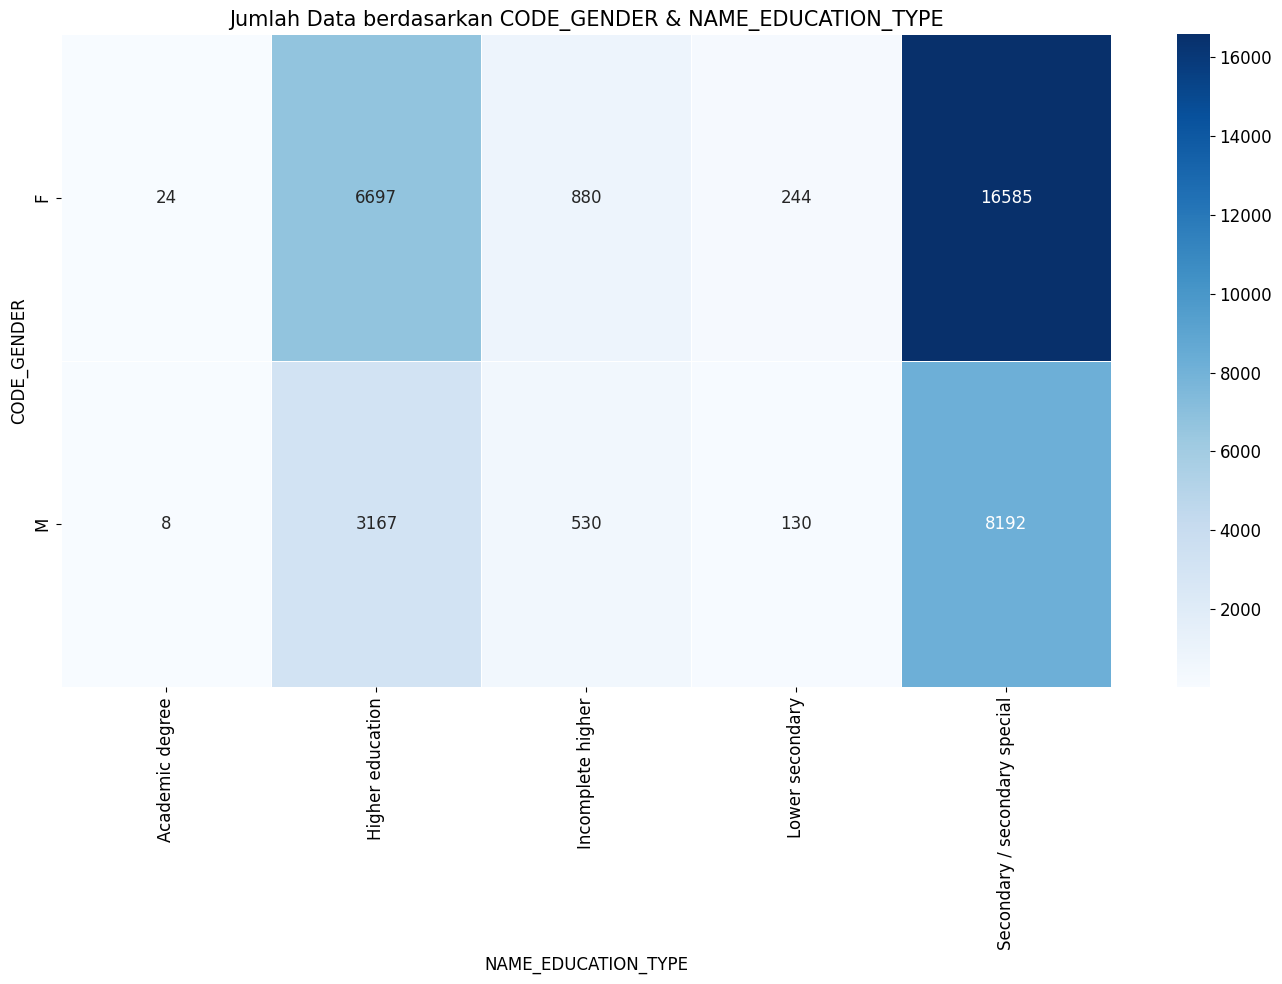


Analisis Interaksi NAME_INCOME_TYPE & NAME_FAMILY_STATUS terhadap TARGET

Bad Rate (%) berdasarkan kombinasi kategori:
NAME_FAMILY_STATUS    Civil marriage   Married  Separated  \
NAME_INCOME_TYPE                                            
Commercial associate        0.583431  0.917917   1.437372   
Pensioner                   0.269542  1.070609   2.898551   
State servant               0.000000  0.662565   0.617284   
Student                     0.000000  0.000000   0.000000   
Working                     0.134771  0.674713   0.811542   

NAME_FAMILY_STATUS    Single / not married     Widow  
NAME_INCOME_TYPE                                      
Commercial associate              1.422156  0.000000  
Pensioner                         1.021898  1.328502  
State servant                     0.793651  0.990099  
Student                           0.000000  0.000000  
Working                           0.905723  1.310044  

Jumlah data per kombinasi kategori:
NAME_FAMILY_STATUS    Civil ma

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3804295617.py:10: FutureWarning:

The provided callable <function mean at 0x000001981D758F40> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



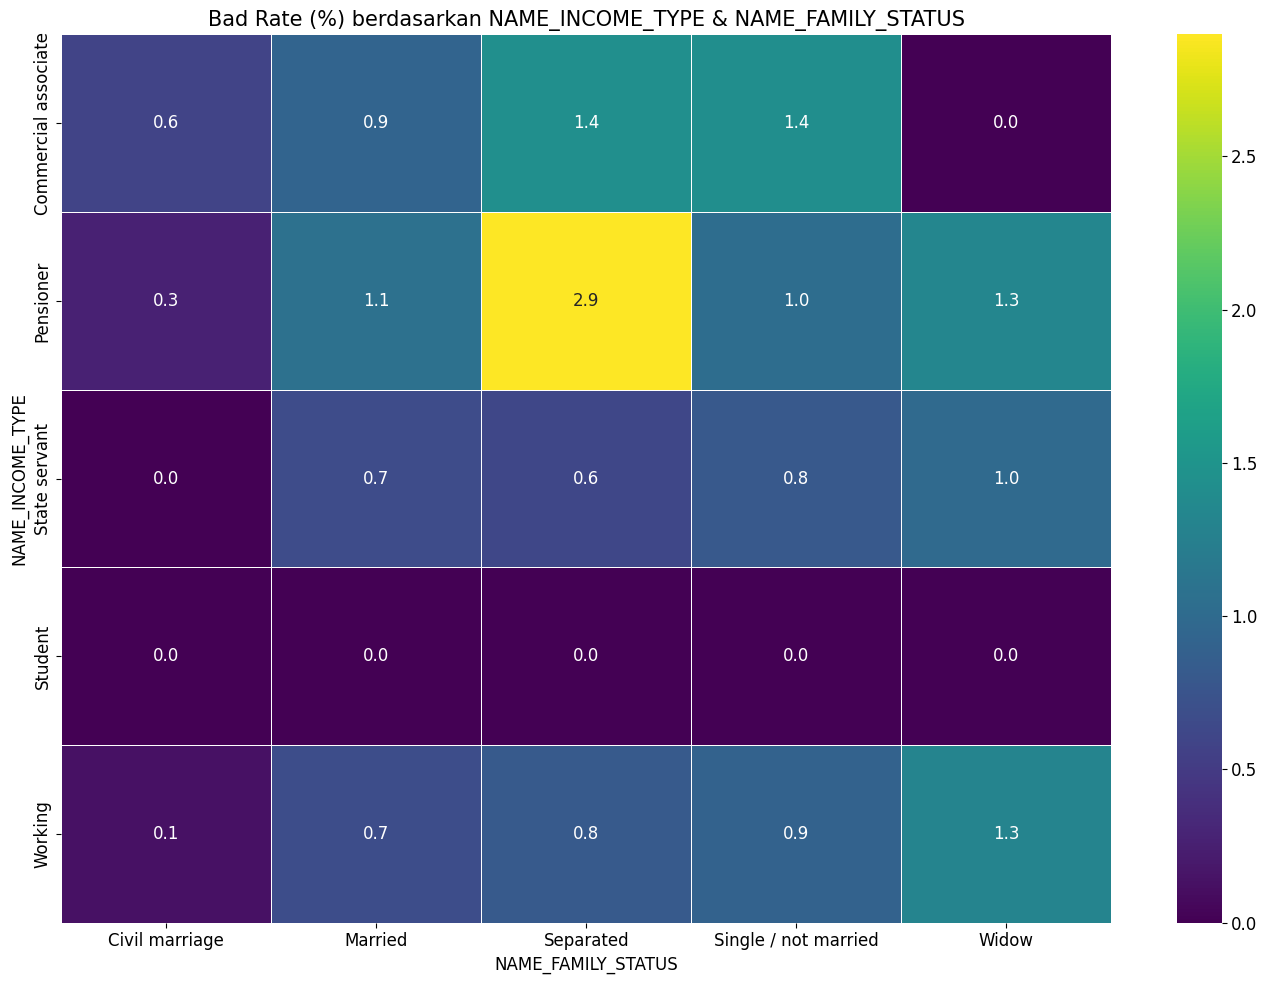

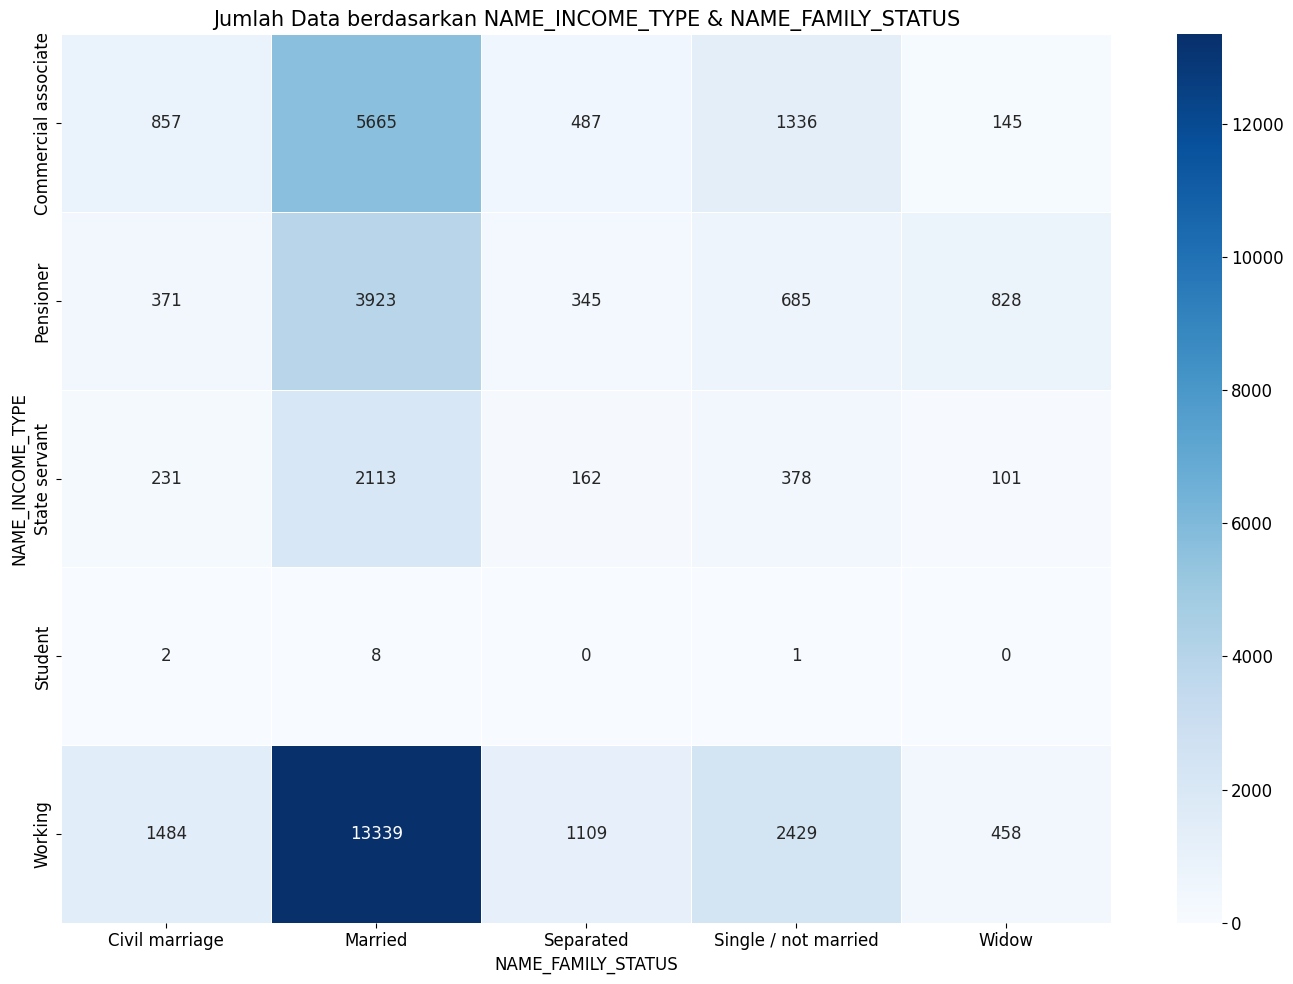


Analisis Interaksi INCOME_GROUP & AGE_GROUP terhadap TARGET

Bad Rate (%) berdasarkan kombinasi kategori:
AGE_GROUP        18-29     30-39     40-49     50-59       60+
INCOME_GROUP                                                  
High          7.500000  0.000000  3.436426  0.469484  0.000000
Low           0.874317  0.683371  0.813143  0.833759  1.087652
Medium        0.729335  0.567465  0.644286  0.965665  1.578947
Very High     0.000000  0.000000  0.000000  0.000000  0.000000

Jumlah data per kombinasi kategori:
AGE_GROUP     18-29  30-39  40-49  50-59   60+
INCOME_GROUP                                  
High             80    205    291    213    68
Low            3660   7024   6026   5877  3126
Medium         1234   3172   2949   1864   570
Very High        15     10     39     24    10


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3804295617.py:10: FutureWarning:

The provided callable <function mean at 0x000001981D758F40> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



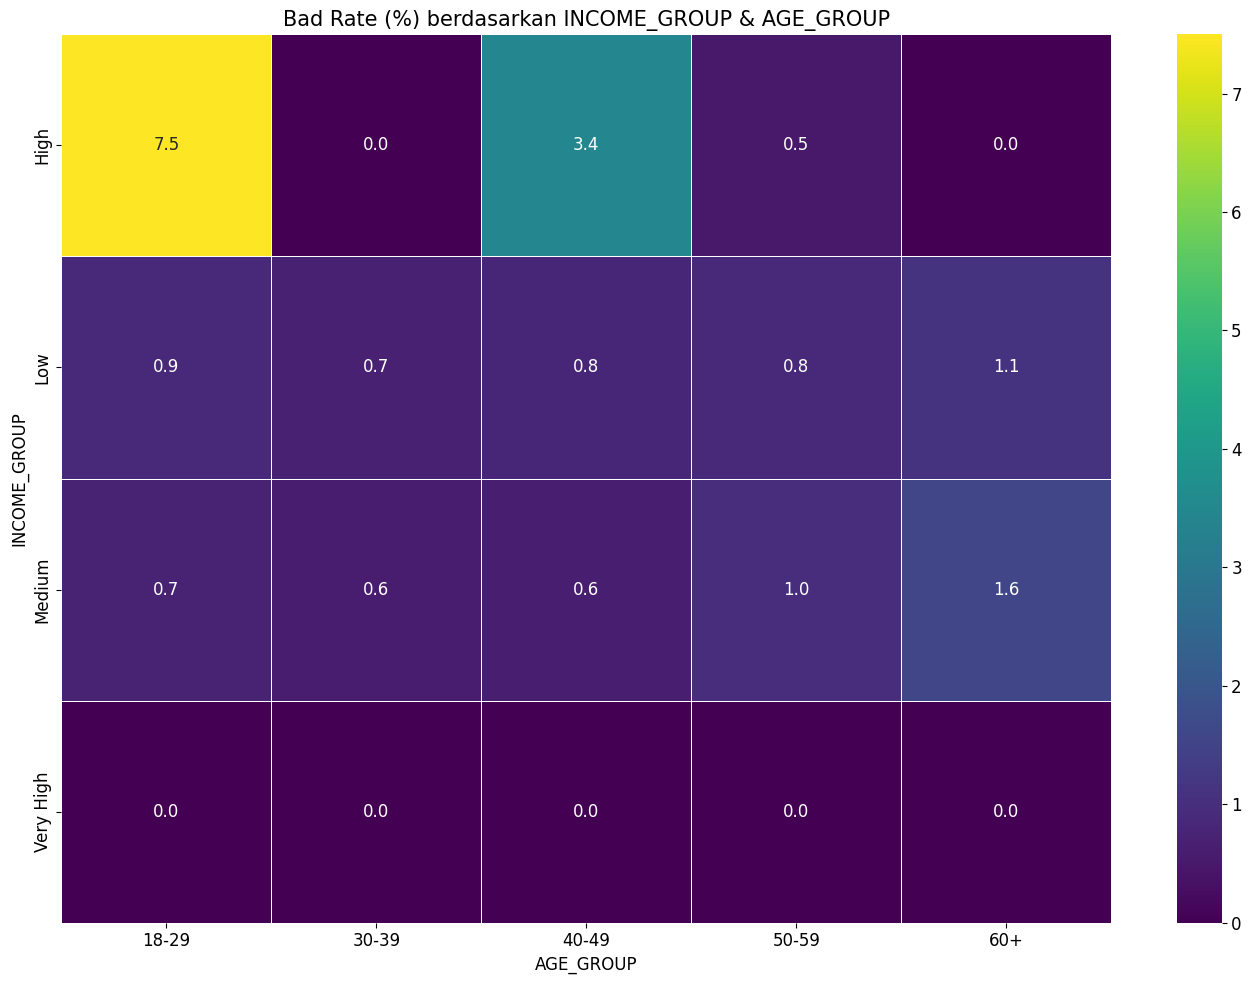

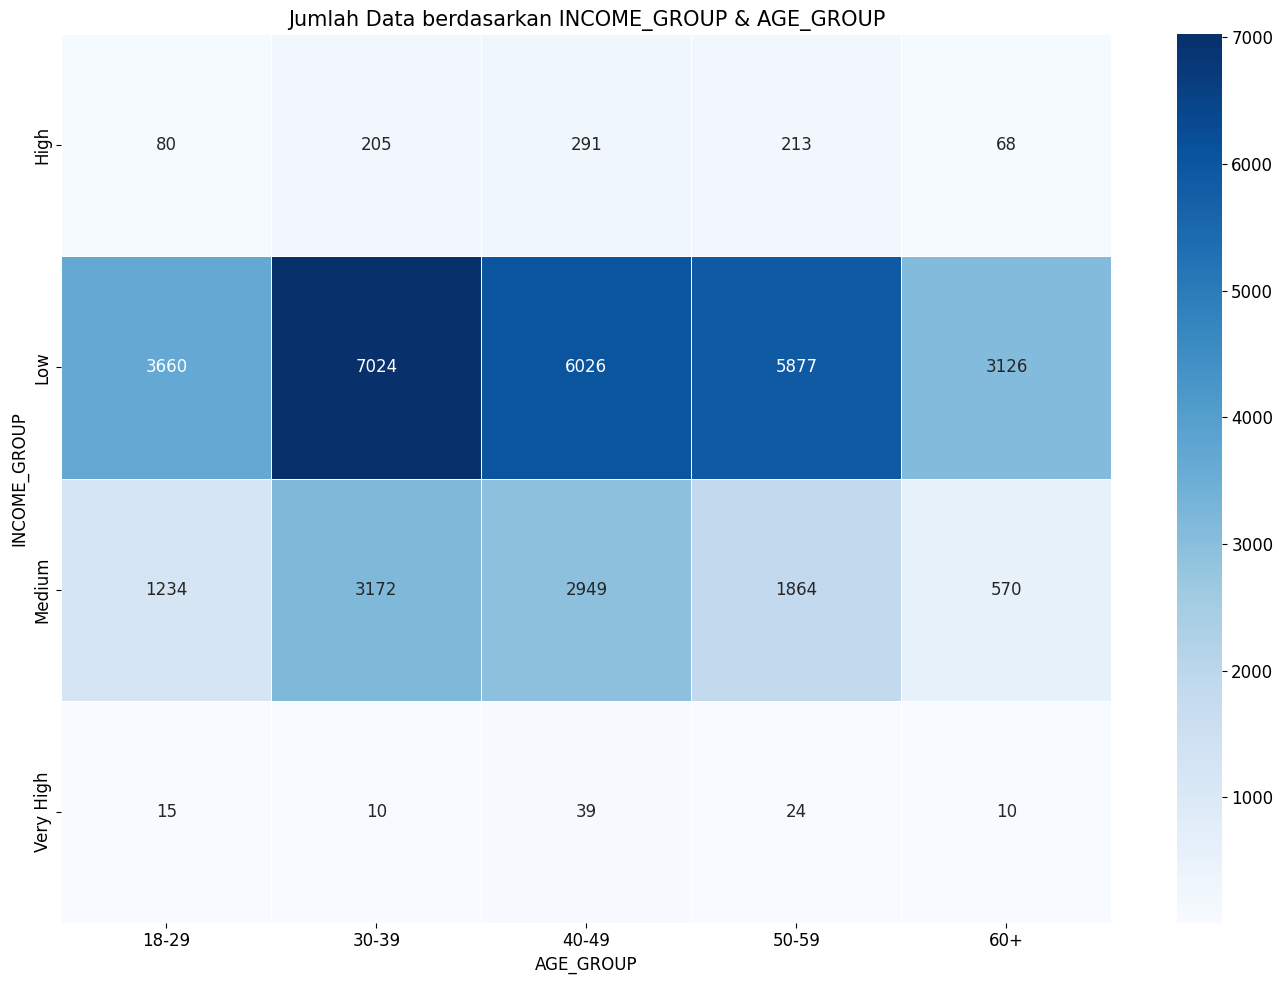

In [78]:
# 3.1 Interaksi antara dua variabel kategorik terhadap target
def categorical_interaction(df, cat_col1, cat_col2, target='TARGET'):
    """Menganalisis interaksi dua variabel kategorik terhadap target."""
    
    print(f"\n{'='*50}")
    print(f"Analisis Interaksi {cat_col1} & {cat_col2} terhadap {target}")
    print(f"{'='*50}")
    
    # Membuat pivot table untuk menghitung persentase bad rate
    pivot = pd.pivot_table(df, values=target, index=cat_col1, columns=cat_col2, 
                         aggfunc=np.mean, fill_value=0) * 100
    
    print("\nBad Rate (%) berdasarkan kombinasi kategori:")
    print(pivot)
    
    # Menghitung jumlah data per kombinasi kategori
    count_pivot = pd.pivot_table(df, values=target, index=cat_col1, columns=cat_col2,
                               aggfunc='count', fill_value=0)
    
    print("\nJumlah data per kombinasi kategori:")
    print(count_pivot)
    
    # Visualisasi heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='viridis', linewidths=.5)
    plt.title(f'Bad Rate (%) berdasarkan {cat_col1} & {cat_col2}', fontsize=15)
    plt.tight_layout()
    plt.show()
    
    # Visualisasi jumlah data
    plt.figure(figsize=(14, 10))
    sns.heatmap(count_pivot, annot=True, fmt='d', cmap='Blues', linewidths=.5)
    plt.title(f'Jumlah Data berdasarkan {cat_col1} & {cat_col2}', fontsize=15)
    plt.tight_layout()
    plt.show()


# Pastikan untuk menyesuaikan daftar kolom sesuai dengan dataset yang sebenarnya
categorical_cols = ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
                   'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
                   'INCOME_GROUP', 'AGE_GROUP']


print("\n\n*** ANALISIS INTERAKSI ANTAR VARIABEL KATEGORIK ***")
# Memilih beberapa pasangan variabel kategorik yang menarik untuk dianalisis
categorical_interaction(eda_df, 'CODE_GENDER', 'NAME_EDUCATION_TYPE')
categorical_interaction(eda_df, 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS')
categorical_interaction(eda_df, 'INCOME_GROUP', 'AGE_GROUP')



## Interaksi Variabel Kategorik dan Numerik terhadap Target



*** ANALISIS INTERAKSI VARIABEL KATEGORIK & NUMERIK ***

Analisis Interaksi NAME_EDUCATION_TYPE & AMT_INCOME_TOTAL terhadap TARGET


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3722813512.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



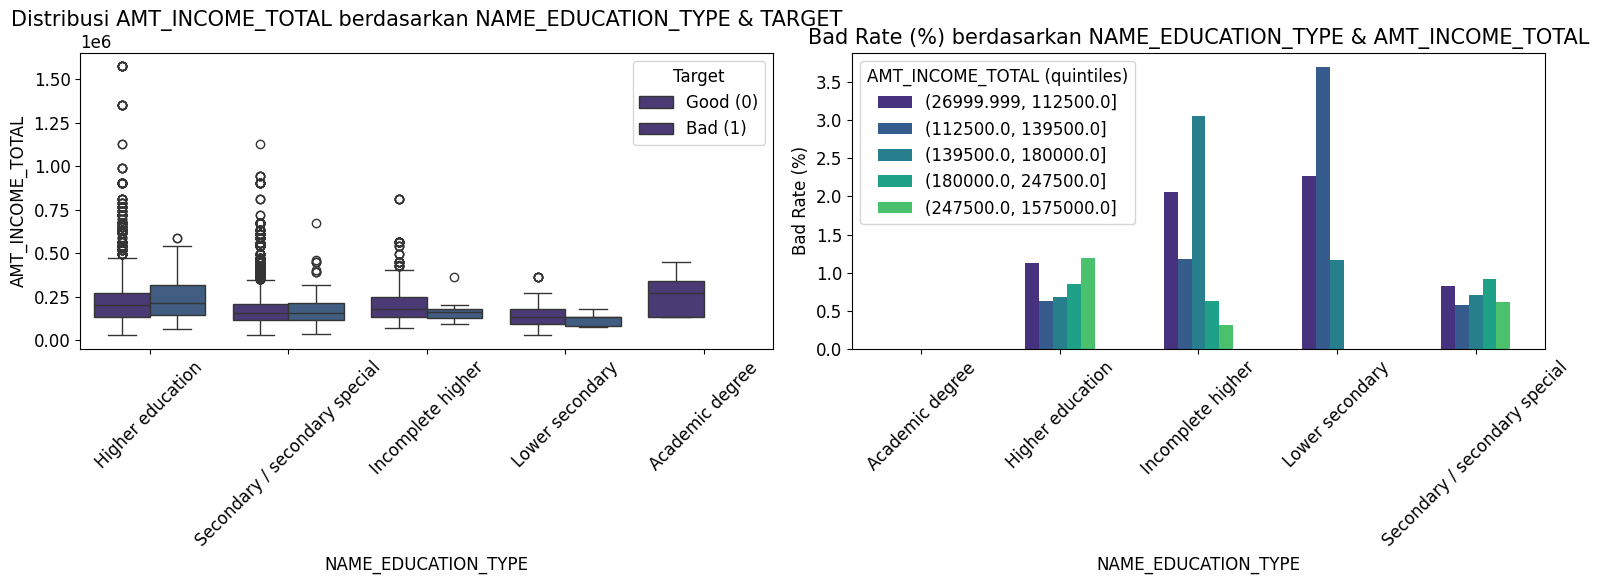


ANOVA dua arah untuk menguji efek interaksi:
Tidak dapat melakukan ANOVA: No module named 'statsmodels'

Analisis Interaksi CODE_GENDER & AGE terhadap TARGET


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3722813512.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



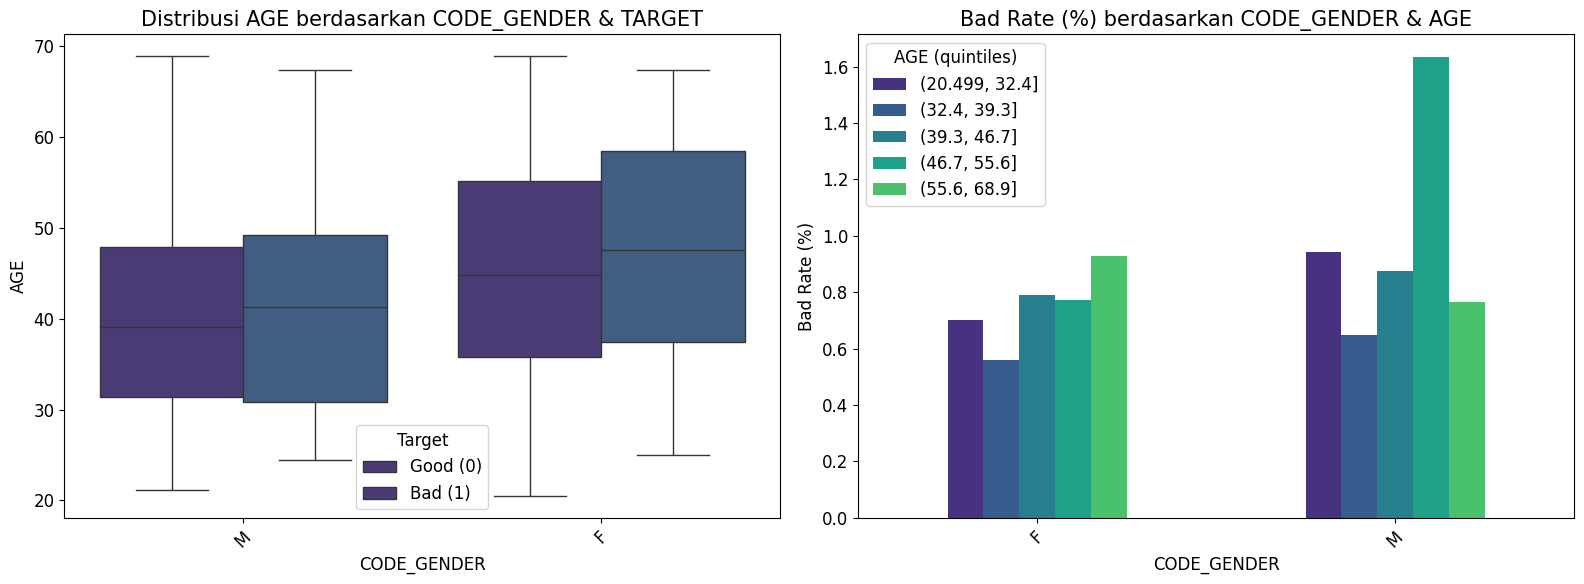


ANOVA dua arah untuk menguji efek interaksi:
Tidak dapat melakukan ANOVA: No module named 'statsmodels'

Analisis Interaksi INCOME_GROUP & CREDIT_HISTORY_LENGTH terhadap TARGET


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\3722813512.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



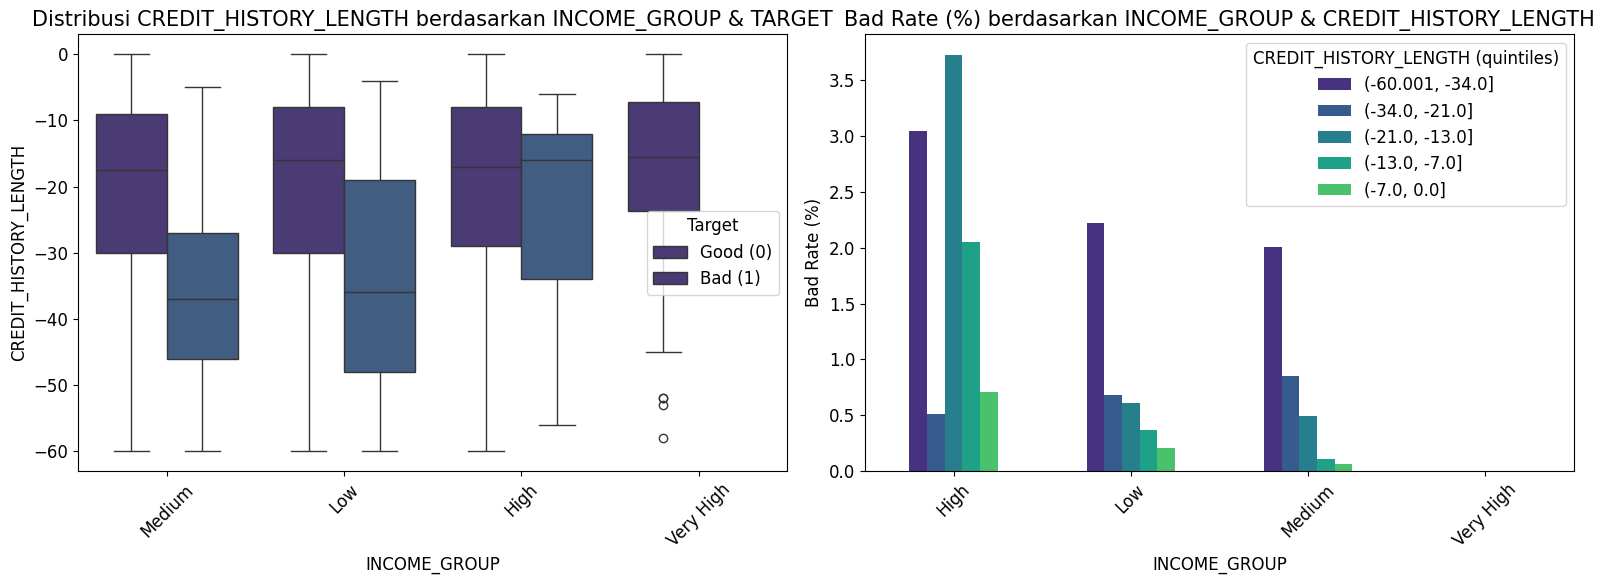


ANOVA dua arah untuk menguji efek interaksi:
Tidak dapat melakukan ANOVA: No module named 'statsmodels'


In [79]:

# 3.2 Interaksi antara variabel kategorik dan numerik terhadap target
def category_numeric_interaction(df, cat_col, num_col, target='TARGET'):
    """Menganalisis interaksi variabel kategorik dan numerik terhadap target."""
    
    print(f"\n{'='*50}")
    print(f"Analisis Interaksi {cat_col} & {num_col} terhadap {target}")
    print(f"{'='*50}")
    
    # Visualisasi
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Box plot untuk melihat distribusi variabel numerik per kategori dan target
    sns.boxplot(x=cat_col, y=num_col, hue=target, data=df, ax=ax1)
    ax1.set_title(f'Distribusi {num_col} berdasarkan {cat_col} & {target}', fontsize=15)
    ax1.set_xlabel(cat_col, fontsize=12)
    ax1.set_ylabel(num_col, fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title='Target', labels=['Good (0)', 'Bad (1)'])
    
    # Bar plot untuk menampilkan bad rate per kategori dan level variabel numerik
    # Membuat binning untuk variabel numerik
    df_temp = df.copy()
    df_temp[f'{num_col}_bin'] = pd.qcut(df_temp[num_col], q=5, duplicates='drop')
    
    # Menghitung bad rate
    bad_rate = df_temp.groupby([cat_col, f'{num_col}_bin'])[target].mean() * 100
    bad_rate = bad_rate.unstack()
    
    # Plot
    bad_rate.plot(kind='bar', ax=ax2)
    ax2.set_title(f'Bad Rate (%) berdasarkan {cat_col} & {num_col}', fontsize=15)
    ax2.set_xlabel(cat_col, fontsize=12)
    ax2.set_ylabel('Bad Rate (%)', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title=f'{num_col} (quintiles)')
    
    plt.tight_layout()
    plt.show()
    
    # Analisis statistik
    print("\nANOVA dua arah untuk menguji efek interaksi:")
    try:
        from statsmodels.formula.api import ols
        from statsmodels.stats.anova import anova_lm
        
        # Membuat model
        formula = f"{target} ~ C({cat_col}) + {num_col} + C({cat_col}):{num_col}"
        model = ols(formula, data=df).fit()
        
        # ANOVA table
        anova_table = anova_lm(model, typ=2)
        print(anova_table)
        
        # Interpretasi
        p_cat = anova_table.loc[f'C({cat_col})', 'PR(>F)']
        p_num = anova_table.loc[f'{num_col}', 'PR(>F)']
        p_interaction = anova_table.loc[f'C({cat_col}):{num_col}', 'PR(>F)']
        
        print("\nInterpretasi:")
        if p_cat < 0.05:
            print(f"- Efek utama {cat_col} signifikan (p = {p_cat:.4f})")
        else:
            print(f"- Efek utama {cat_col} tidak signifikan (p = {p_cat:.4f})")
            
        if p_num < 0.05:
            print(f"- Efek utama {num_col} signifikan (p = {p_num:.4f})")
        else:
            print(f"- Efek utama {num_col} tidak signifikan (p = {p_num:.4f})")
            
        if p_interaction < 0.05:
            print(f"- Efek interaksi {cat_col}:{num_col} signifikan (p = {p_interaction:.4f})")
            print("  Artinya, pengaruh {num_col} terhadap target bergantung pada nilai {cat_col}")
        else:
            print(f"- Efek interaksi {cat_col}:{num_col} tidak signifikan (p = {p_interaction:.4f})")
            print(f"  Artinya, pengaruh {num_col} terhadap target tidak bergantung pada nilai {cat_col}")
    
    except Exception as e:
        print(f"Tidak dapat melakukan ANOVA: {str(e)}")

numeric_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
               'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED', 'CREDIT_HISTORY_LENGTH',
               'COUNT_LATE_LAST_12M', 'EDUCATION_RANK']

print("\n\n*** ANALISIS INTERAKSI VARIABEL KATEGORIK & NUMERIK ***")
# Memilih beberapa pasangan variabel kategorik dan numerik yang menarik
category_numeric_interaction(eda_df, 'NAME_EDUCATION_TYPE', 'AMT_INCOME_TOTAL')
category_numeric_interaction(eda_df, 'CODE_GENDER', 'AGE')
category_numeric_interaction(eda_df, 'INCOME_GROUP', 'CREDIT_HISTORY_LENGTH')


## Interaksi Variabel Numerik terhadap Target



*** ANALISIS INTERAKSI ANTAR VARIABEL NUMERIK ***

Analisis Interaksi AMT_INCOME_TOTAL & AGE terhadap TARGET

Bad Rate (%) berdasarkan kombinasi variabel numerik:
AGE_bin                (20.499, 32.4]  (32.4, 39.3]  (39.3, 46.7]  \
AMT_INCOME_TOTAL_bin                                                
(26999.999, 112500.0]        0.401338      0.416089      0.666173   
(112500.0, 139500.0]         0.741740      0.374883      0.816327   
(139500.0, 180000.0]         0.907029      0.462695      1.280323   
(180000.0, 247500.0]         0.615595      1.010739      0.800986   
(247500.0, 1575000.0]        1.567944      0.616861      0.545785   

AGE_bin                (46.7, 55.6]  (55.6, 68.9]  
AMT_INCOME_TOTAL_bin                               
(26999.999, 112500.0]      1.051467      1.555644  
(112500.0, 139500.0]       1.038422      0.315956  
(139500.0, 180000.0]       0.668896      0.723589  
(180000.0, 247500.0]       1.146325      0.805802  
(247500.0, 1575000.0]      1.188904    

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\4231929797.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\4231929797.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



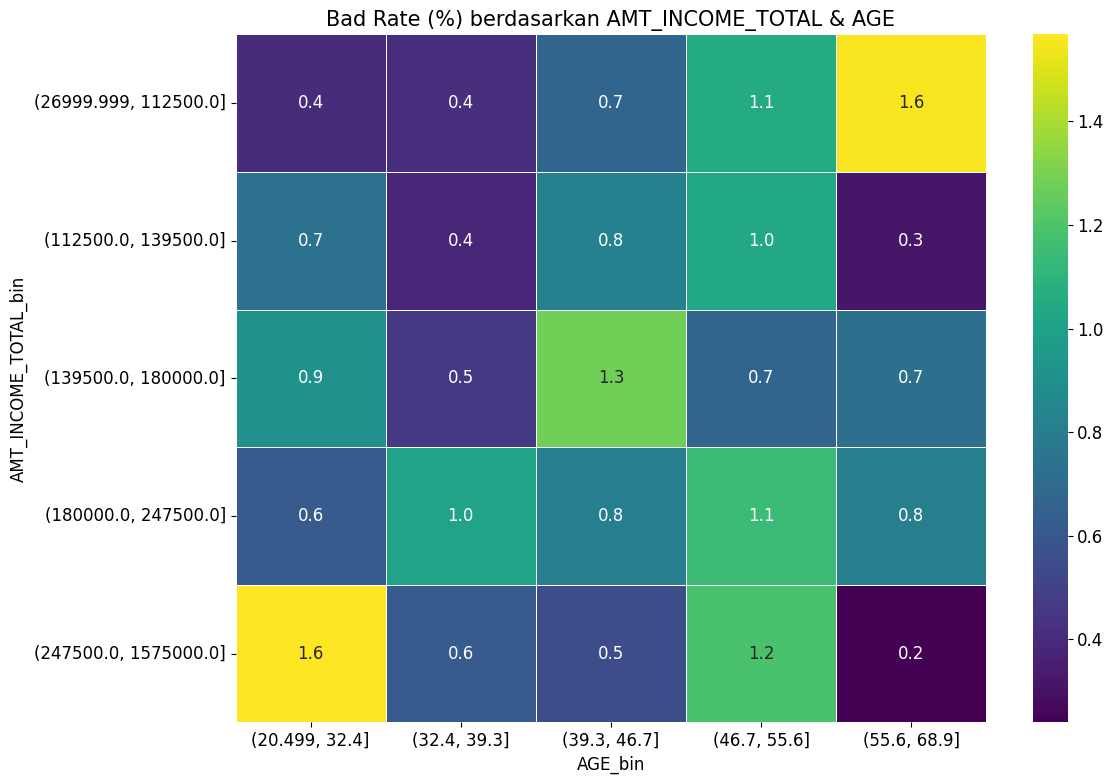

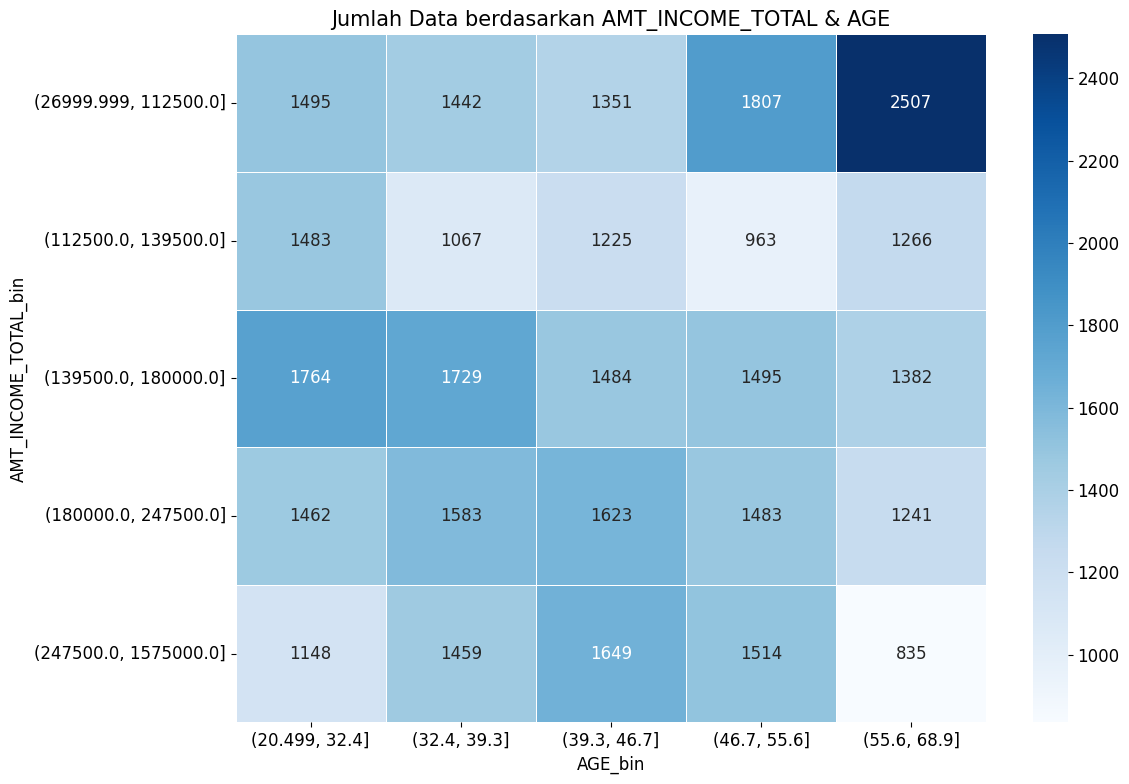

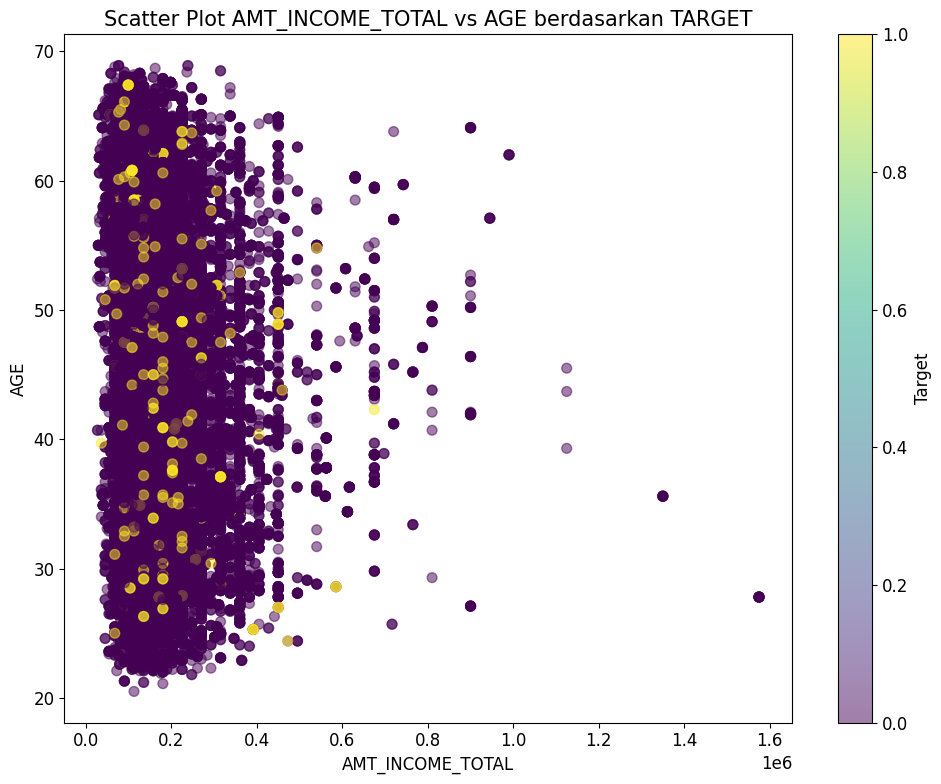


Korelasi antara AMT_INCOME_TOTAL dan AGE:
- Untuk nasabah good: r = -0.0663
- Untuk nasabah bad: r = -0.2584
Tidak dapat melakukan regresi logistik: No module named 'statsmodels'

Analisis Interaksi YEARS_EMPLOYED & CREDIT_HISTORY_LENGTH terhadap TARGET

Bad Rate (%) berdasarkan kombinasi variabel numerik:
CREDIT_HISTORY_LENGTH_bin  (-60.001, -34.0]  (-34.0, -21.0]  (-21.0, -13.0]  \
YEARS_EMPLOYED_bin                                                            
(-0.001, 0.5]                      3.026227        0.848656        0.820283   
(0.5, 3.0]                         3.450863        1.063076        1.068804   
(3.0, 5.7]                         1.921599        0.908501        0.355366   
(5.7, 9.9]                         1.383875        0.656325        0.465426   
(9.9, 43.0]                        1.429388        0.188442        0.509091   

CREDIT_HISTORY_LENGTH_bin  (-13.0, -7.0]  (-7.0, 0.0]  
YEARS_EMPLOYED_bin                                     
(-0.001, 0.5]            

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\4231929797.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\4231929797.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



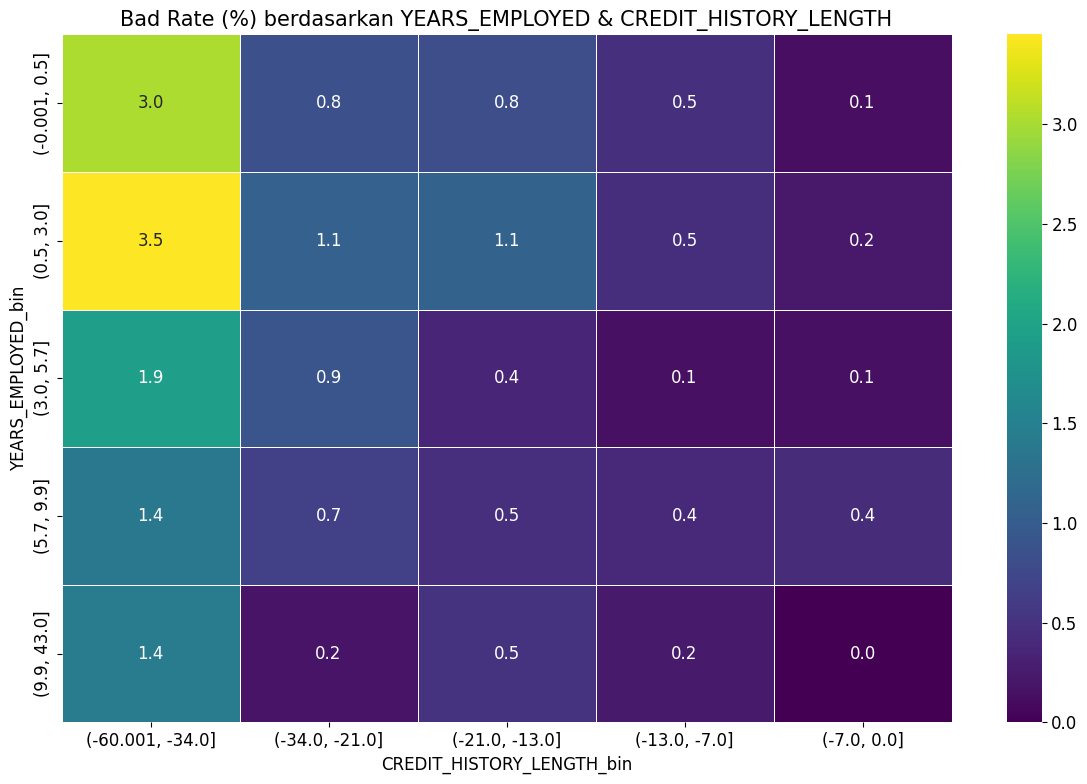

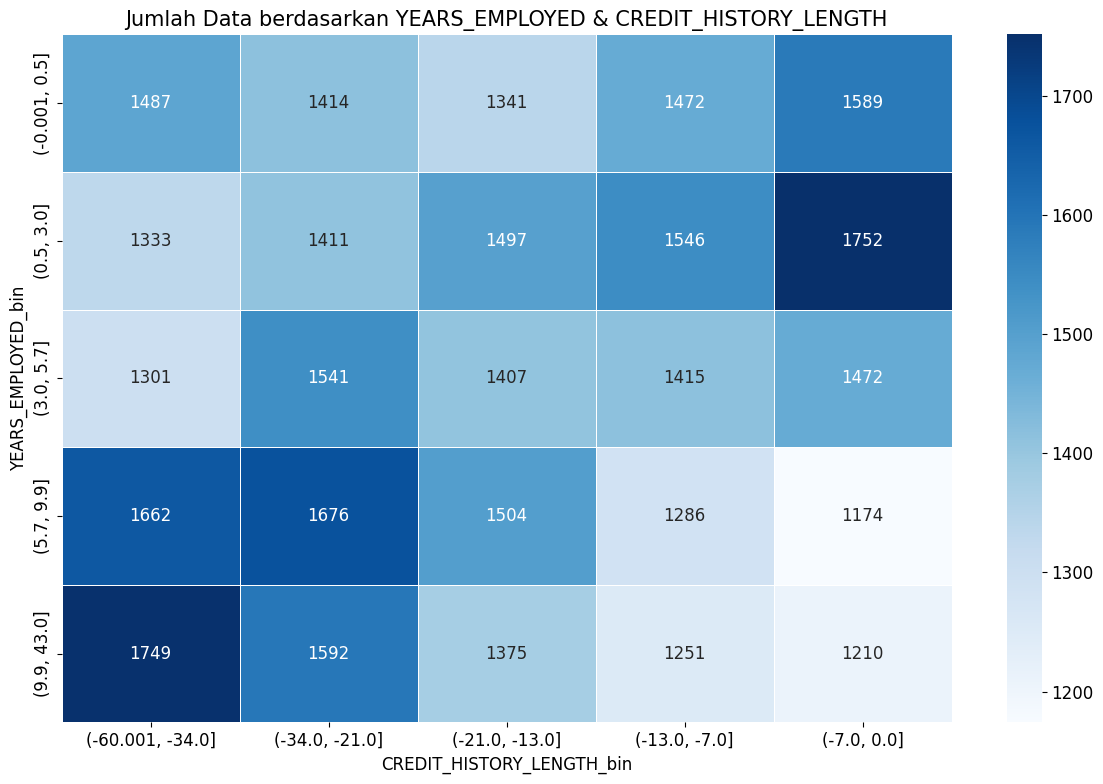

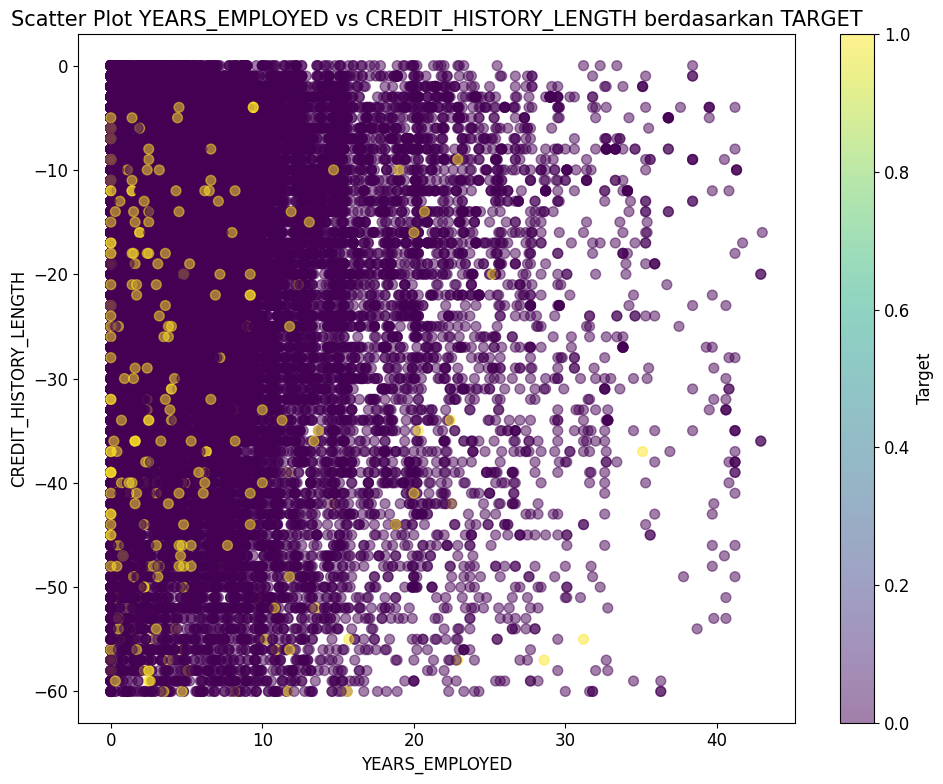


Korelasi antara YEARS_EMPLOYED dan CREDIT_HISTORY_LENGTH:
- Untuk nasabah good: r = -0.0775
- Untuk nasabah bad: r = -0.0042
Tidak dapat melakukan regresi logistik: No module named 'statsmodels'

Analisis Interaksi CNT_CHILDREN & CNT_FAM_MEMBERS terhadap TARGET

Bad Rate (%) berdasarkan kombinasi variabel numerik:
CNT_FAM_MEMBERS_bin  (0.999, 2.0]  (2.0, 3.0]  (3.0, 20.0]
CNT_CHILDREN_bin                                          
(-0.001, 1.0]            0.869631    0.720576          NaN
(1.0, 19.0]              0.000000    1.136364     0.697156

Jumlah data per kombinasi variabel numerik:
CNT_FAM_MEMBERS_bin  (0.999, 2.0]  (2.0, 3.0]  (3.0, 20.0]
CNT_CHILDREN_bin                                          
(-0.001, 1.0]               26448        6245            0
(1.0, 19.0]                     2         176         3586


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\4231929797.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9912\4231929797.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



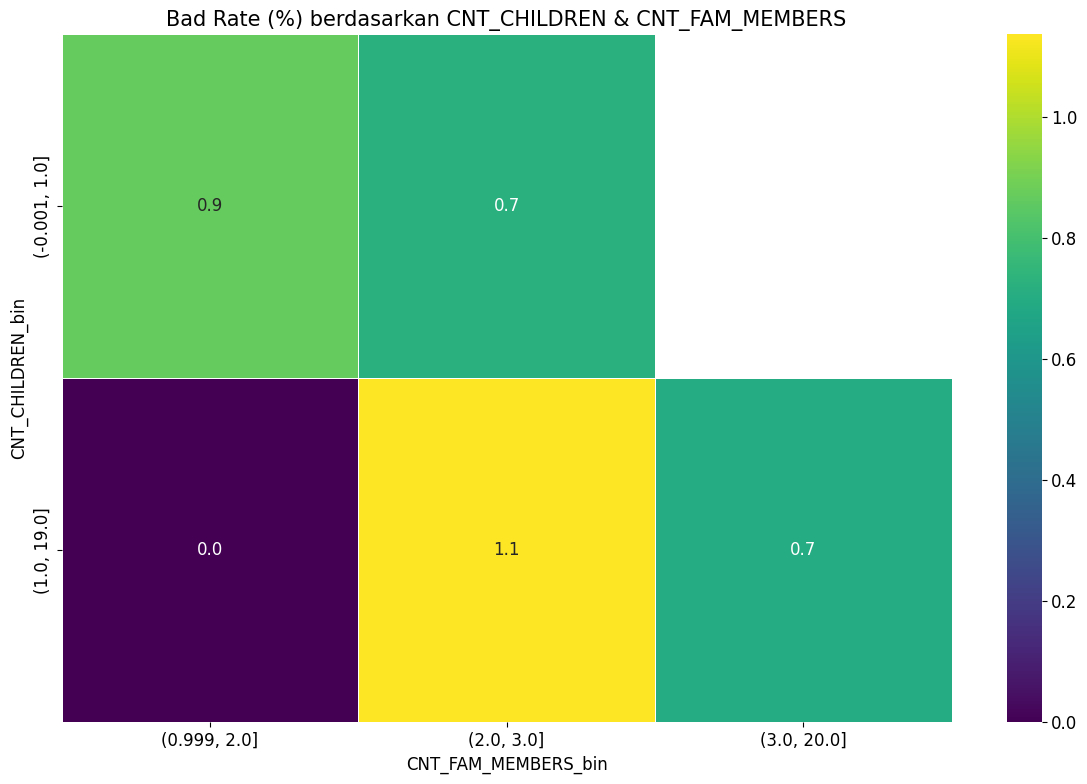

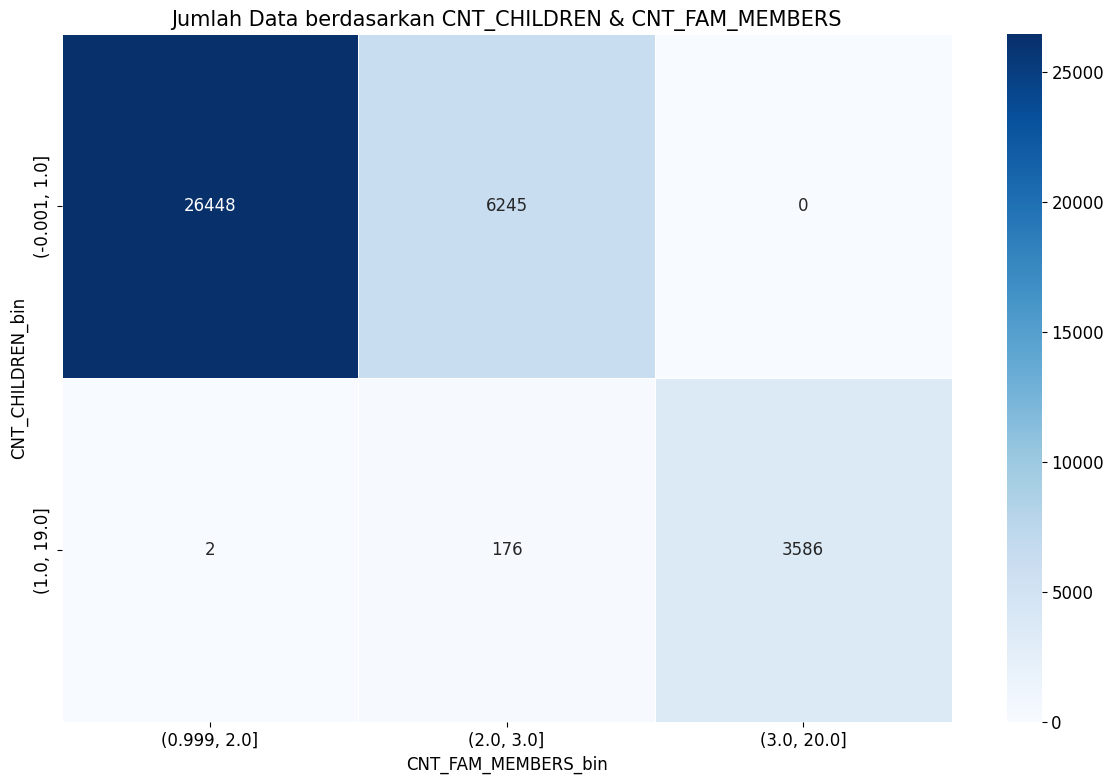

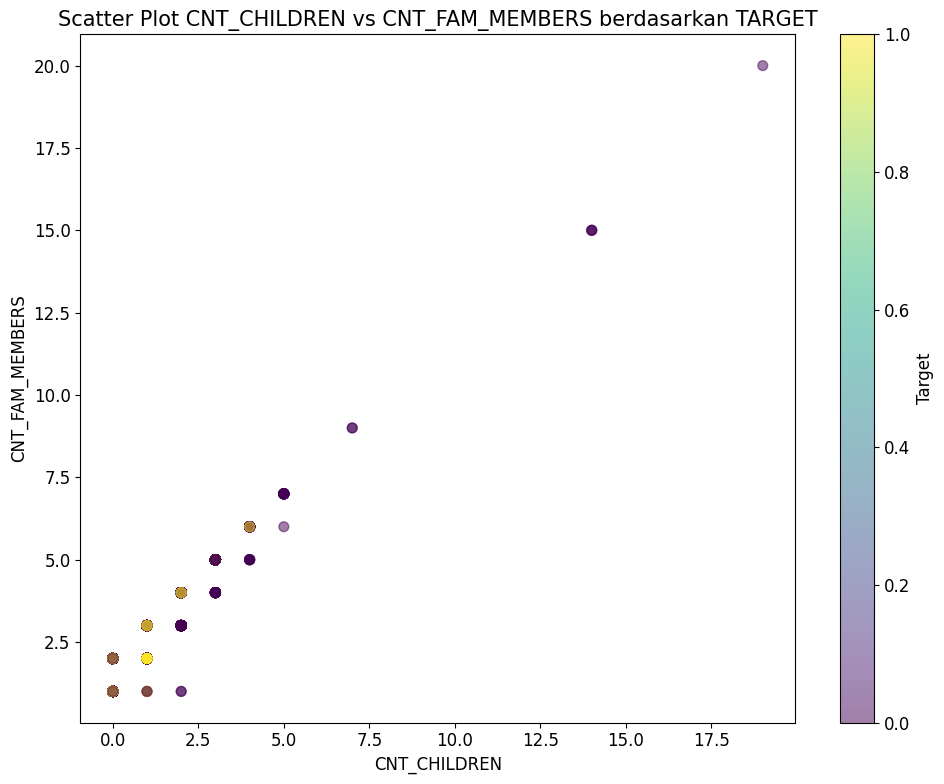


Korelasi antara CNT_CHILDREN dan CNT_FAM_MEMBERS:
- Untuk nasabah good: r = 0.8894
- Untuk nasabah bad: r = 0.8528
Tidak dapat melakukan regresi logistik: No module named 'statsmodels'


In [80]:

# 3.3 Interaksi antara dua variabel numerik terhadap target
def numeric_interaction(df, num_col1, num_col2, target='TARGET'):
    """Menganalisis interaksi dua variabel numerik terhadap target."""
    
    print(f"\n{'='*50}")
    print(f"Analisis Interaksi {num_col1} & {num_col2} terhadap {target}")
    print(f"{'='*50}")
    
    # Membuat binning untuk kedua variabel numerik
    df_temp = df.copy()
    df_temp[f'{num_col1}_bin'] = pd.qcut(df_temp[num_col1], q=5, duplicates='drop')
    df_temp[f'{num_col2}_bin'] = pd.qcut(df_temp[num_col2], q=5, duplicates='drop')
    
    # Menghitung bad rate
    bad_rate = df_temp.groupby([f'{num_col1}_bin', f'{num_col2}_bin'])[target].mean() * 100
    bad_rate = bad_rate.unstack()
    
    # Menghitung jumlah data
    count = df_temp.groupby([f'{num_col1}_bin', f'{num_col2}_bin'])[target].count()
    count = count.unstack()
    
    print("\nBad Rate (%) berdasarkan kombinasi variabel numerik:")
    print(bad_rate)
    
    print("\nJumlah data per kombinasi variabel numerik:")
    print(count)
    
    # Visualisasi heatmap untuk bad rate
    plt.figure(figsize=(12, 8))
    sns.heatmap(bad_rate, annot=True, fmt='.1f', cmap='viridis', linewidths=.5)
    plt.title(f'Bad Rate (%) berdasarkan {num_col1} & {num_col2}', fontsize=15)
    plt.tight_layout()
    plt.show()
    
    # Visualisasi heatmap untuk jumlah data
    plt.figure(figsize=(12, 8))
    sns.heatmap(count, annot=True, fmt='d', cmap='Blues', linewidths=.5)
    plt.title(f'Jumlah Data berdasarkan {num_col1} & {num_col2}', fontsize=15)
    plt.tight_layout()
    plt.show()
    
    # Scatter plot dengan warna berdasarkan target
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(df[num_col1], df[num_col2], c=df[target], 
                       alpha=0.5, cmap='viridis', s=50)
    plt.colorbar(scatter, label='Target')
    plt.title(f'Scatter Plot {num_col1} vs {num_col2} berdasarkan {target}', fontsize=15)
    plt.xlabel(num_col1, fontsize=12)
    plt.ylabel(num_col2, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Korelasi berdasarkan target
    corr_good = df[df[target]==0][[num_col1, num_col2]].corr().iloc[0, 1]
    corr_bad = df[df[target]==1][[num_col1, num_col2]].corr().iloc[0, 1]
    
    print(f"\nKorelasi antara {num_col1} dan {num_col2}:")
    print(f"- Untuk nasabah good: r = {corr_good:.4f}")
    print(f"- Untuk nasabah bad: r = {corr_bad:.4f}")
    
    # Regresi logistik untuk menguji interaksi
    try:
        from statsmodels.formula.api import glm
        from statsmodels.api import families
        
        # Membuat model
        formula = f"{target} ~ {num_col1} + {num_col2} + {num_col1}:{num_col2}"
        model = glm(formula, data=df, family=families.Binomial()).fit()
        
        print("\nRegresi logistik untuk menguji interaksi:")
        print(model.summary())
        
        # Interpretasi
        p_interaction = model.pvalues[f"{num_col1}:{num_col2}"]
        
        if p_interaction < 0.05:
            print(f"\nEfek interaksi {num_col1}:{num_col2} signifikan (p = {p_interaction:.4f})")
            print(f"Artinya, hubungan antara {num_col1} dan target bergantung pada nilai {num_col2}")
        else:
            print(f"\nEfek interaksi {num_col1}:{num_col2} tidak signifikan (p = {p_interaction:.4f})")
            print(f"Artinya, hubungan antara {num_col1} dan target tidak bergantung pada nilai {num_col2}")
    
    except Exception as e:
        print(f"Tidak dapat melakukan regresi logistik: {str(e)}")



print("\n\n*** ANALISIS INTERAKSI ANTAR VARIABEL NUMERIK ***")
# Memilih beberapa pasangan variabel numerik yang menarik
numeric_interaction(eda_df, 'AMT_INCOME_TOTAL', 'AGE')
numeric_interaction(eda_df, 'YEARS_EMPLOYED', 'CREDIT_HISTORY_LENGTH')
numeric_interaction(eda_df, 'CNT_CHILDREN', 'CNT_FAM_MEMBERS')

## Principal Component Analysis



*** PRINCIPAL COMPONENT ANALYSIS (PCA) ***

Principal Component Analysis (PCA)

Variance explained oleh setiap principal component:
PC1: 30.60%
PC2: 14.89%
PC3: 12.58%
PC4: 11.39%
PC5: 11.03%
PC6: 7.94%
PC7: 7.49%
PC8: 2.98%
PC9: 1.10%
PC10: 0.00%

Cumulative variance explained:
PC1 - PC1: 30.60%
PC1 - PC2: 45.49%
PC1 - PC3: 58.07%
PC1 - PC4: 69.46%
PC1 - PC5: 80.49%
PC1 - PC6: 88.43%
PC1 - PC7: 95.92%
PC1 - PC8: 98.90%
PC1 - PC9: 100.00%
PC1 - PC10: 100.00%


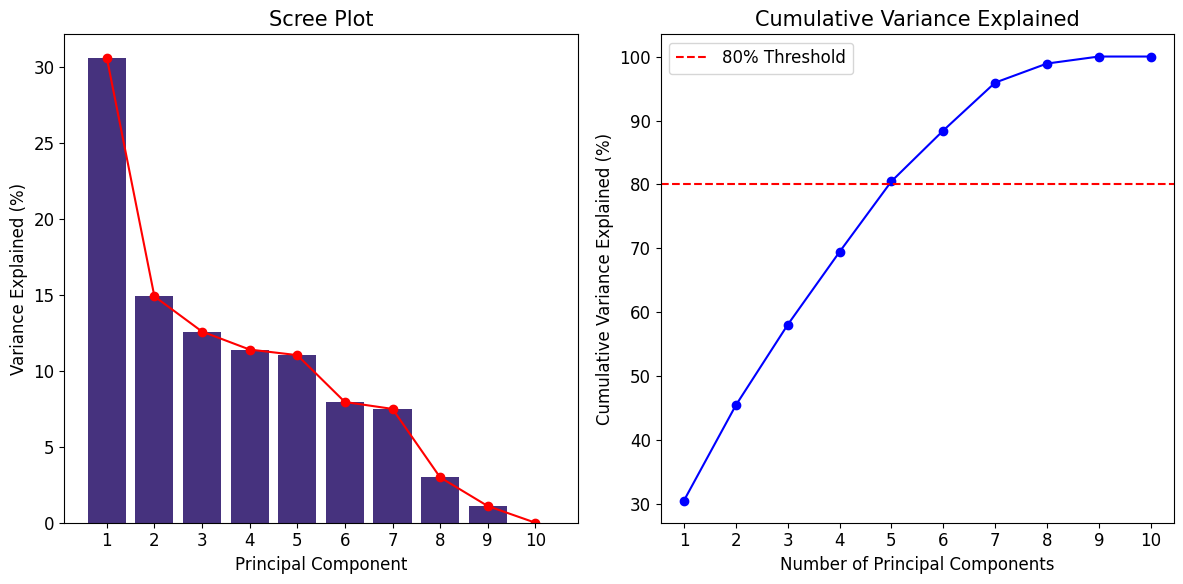

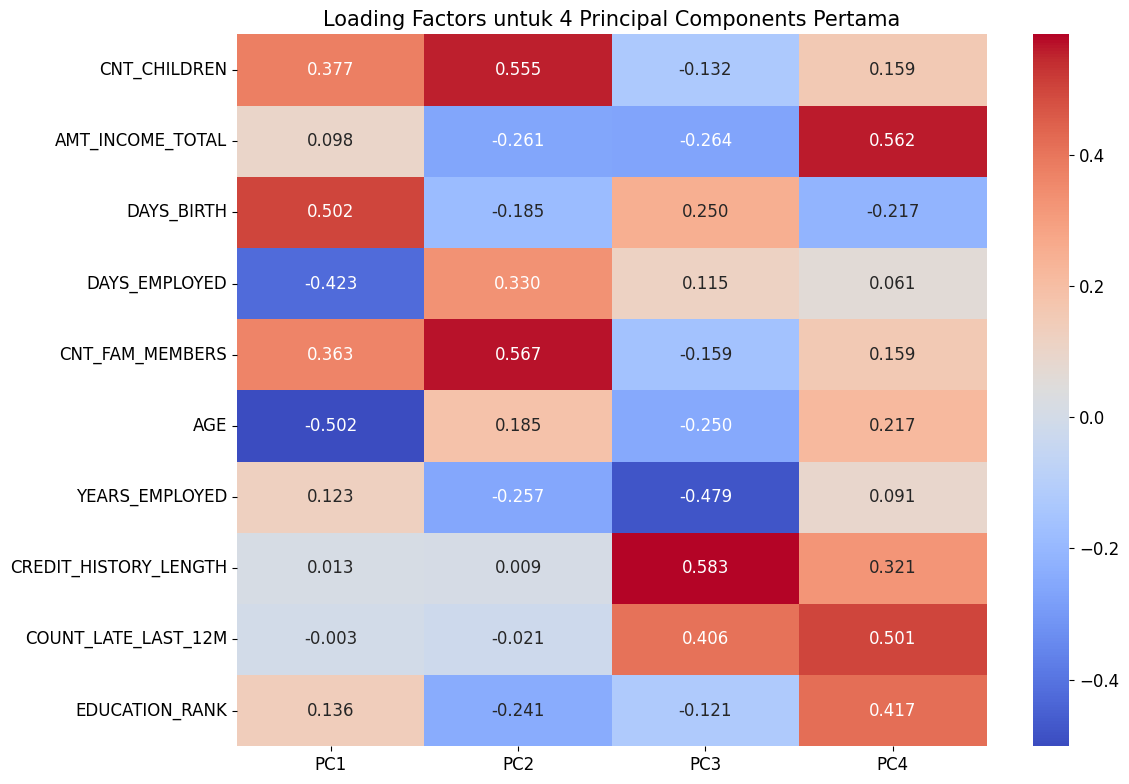

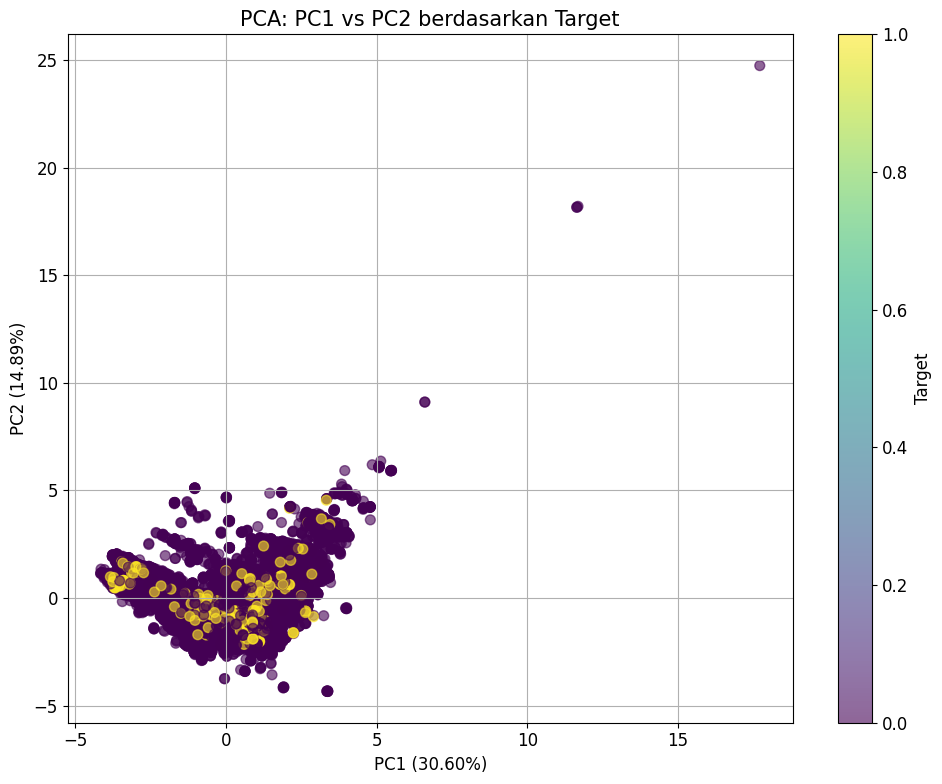


Korelasi antara variabel asli dan principal components:
                            PC1       PC2       PC3       PC4
CNT_CHILDREN           0.659110  0.676930 -0.148074  0.169410
AMT_INCOME_TOTAL       0.172149 -0.318634 -0.296481  0.600056
DAYS_BIRTH             0.877556 -0.225305  0.280820 -0.231537
DAYS_EMPLOYED         -0.740647  0.403012  0.128743  0.065204
CNT_FAM_MEMBERS        0.635391  0.692417 -0.178435  0.169458
AGE                   -0.877550  0.225295 -0.280825  0.231581
YEARS_EMPLOYED         0.215465 -0.313802 -0.536939  0.096766
CREDIT_HISTORY_LENGTH  0.022289  0.011481  0.654314  0.342293
COUNT_LATE_LAST_12M   -0.004630 -0.026190  0.455066  0.534445
EDUCATION_RANK         0.238276 -0.294291 -0.135531  0.445145


In [81]:
# 3.4 Principal Component Analysis (PCA)
def perform_pca(df, numeric_cols, target='TARGET'):
    """Melakukan PCA untuk variabel numerik dan visualisasi berdasarkan target."""
    
    print(f"\n{'='*50}")
    print(f"Principal Component Analysis (PCA)")
    print(f"{'='*50}")
    
    # Memilih kolom numerik dan mengisi missing values (jika ada)
    X = df[numeric_cols].copy()
    X = X.fillna(X.mean())
    
    # Standardisasi data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Menjalankan PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # Menghitung variance explained
    explained_variance = pca.explained_variance_ratio_ * 100
    cumulative_variance = explained_variance.cumsum()
    
    print("\nVariance explained oleh setiap principal component:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var:.2f}%")
    
    print("\nCumulative variance explained:")
    for i, var in enumerate(cumulative_variance):
        print(f"PC1 - PC{i+1}: {var:.2f}%")
    
    # Visualisasi scree plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.bar(range(1, len(explained_variance) + 1), explained_variance)
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'ro-')
    plt.title('Scree Plot', fontsize=15)
    plt.xlabel('Principal Component', fontsize=12)
    plt.ylabel('Variance Explained (%)', fontsize=12)
    plt.xticks(range(1, len(explained_variance) + 1))
    
    # Visualisasi cumulative variance
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
    plt.axhline(y=80, color='r', linestyle='--', label='80% Threshold')
    plt.title('Cumulative Variance Explained', fontsize=15)
    plt.xlabel('Number of Principal Components', fontsize=12)
    plt.ylabel('Cumulative Variance Explained (%)', fontsize=12)
    plt.xticks(range(1, len(cumulative_variance) + 1))
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Visualisasi loading factors untuk PC1 dan PC2
    loadings = pca.components_
    
    plt.figure(figsize=(12, 8))
    
    # Membuat dataframe untuk loading factors
    loading_df = pd.DataFrame(loadings.T, columns=[f'PC{i+1}' for i in range(len(loadings))], 
                           index=numeric_cols)
    
    # Heat map untuk loading factors
    sns.heatmap(loading_df.iloc[:, :4], annot=True, cmap='coolwarm', fmt='.3f')
    plt.title('Loading Factors untuk 4 Principal Components Pertama', fontsize=15)
    plt.tight_layout()
    plt.show()
    
    # Visualisasi scatter plot PC1 vs PC2 berdasarkan target
    plt.figure(figsize=(10, 8))
    target_values = df[target].values
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target_values, 
                       alpha=0.6, cmap='viridis', s=50)
    plt.colorbar(scatter, label='Target')
    plt.title('PCA: PC1 vs PC2 berdasarkan Target', fontsize=15)
    plt.xlabel(f'PC1 ({explained_variance[0]:.2f}%)', fontsize=12)
    plt.ylabel(f'PC2 ({explained_variance[1]:.2f}%)', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Menampilkan korelasi antara PC dan variabel asli
    corr_pc_features = pd.DataFrame(
        np.corrcoef(X_scaled.T, X_pca.T)[:len(numeric_cols), len(numeric_cols):],
        index=numeric_cols,
        columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
    )
    
    print("\nKorelasi antara variabel asli dan principal components:")
    pd.set_option('display.max_rows', None)
    print(corr_pc_features.iloc[:, :4])  # Menampilkan 4 PC pertama
    pd.reset_option('display.max_rows')


print("\n\n*** PRINCIPAL COMPONENT ANALYSIS (PCA) ***")
perform_pca(eda_df, numeric_cols)



## Analisis Kompleksitas fitur dengan Target



*** ANALISIS KOMPLEKSITAS FITUR DENGAN TARGET ***

Analisis Kompleksitas Fitur dengan Target

Korelasi absolut dengan target:
DAYS_EMPLOYED: 0.0109
CNT_FAM_MEMBERS: 0.0099
DAYS_BIRTH: 0.0096
AMT_INCOME_TOTAL: 0.0042
CNT_CHILDREN: 0.0041


<Figure size 1600x1200 with 0 Axes>

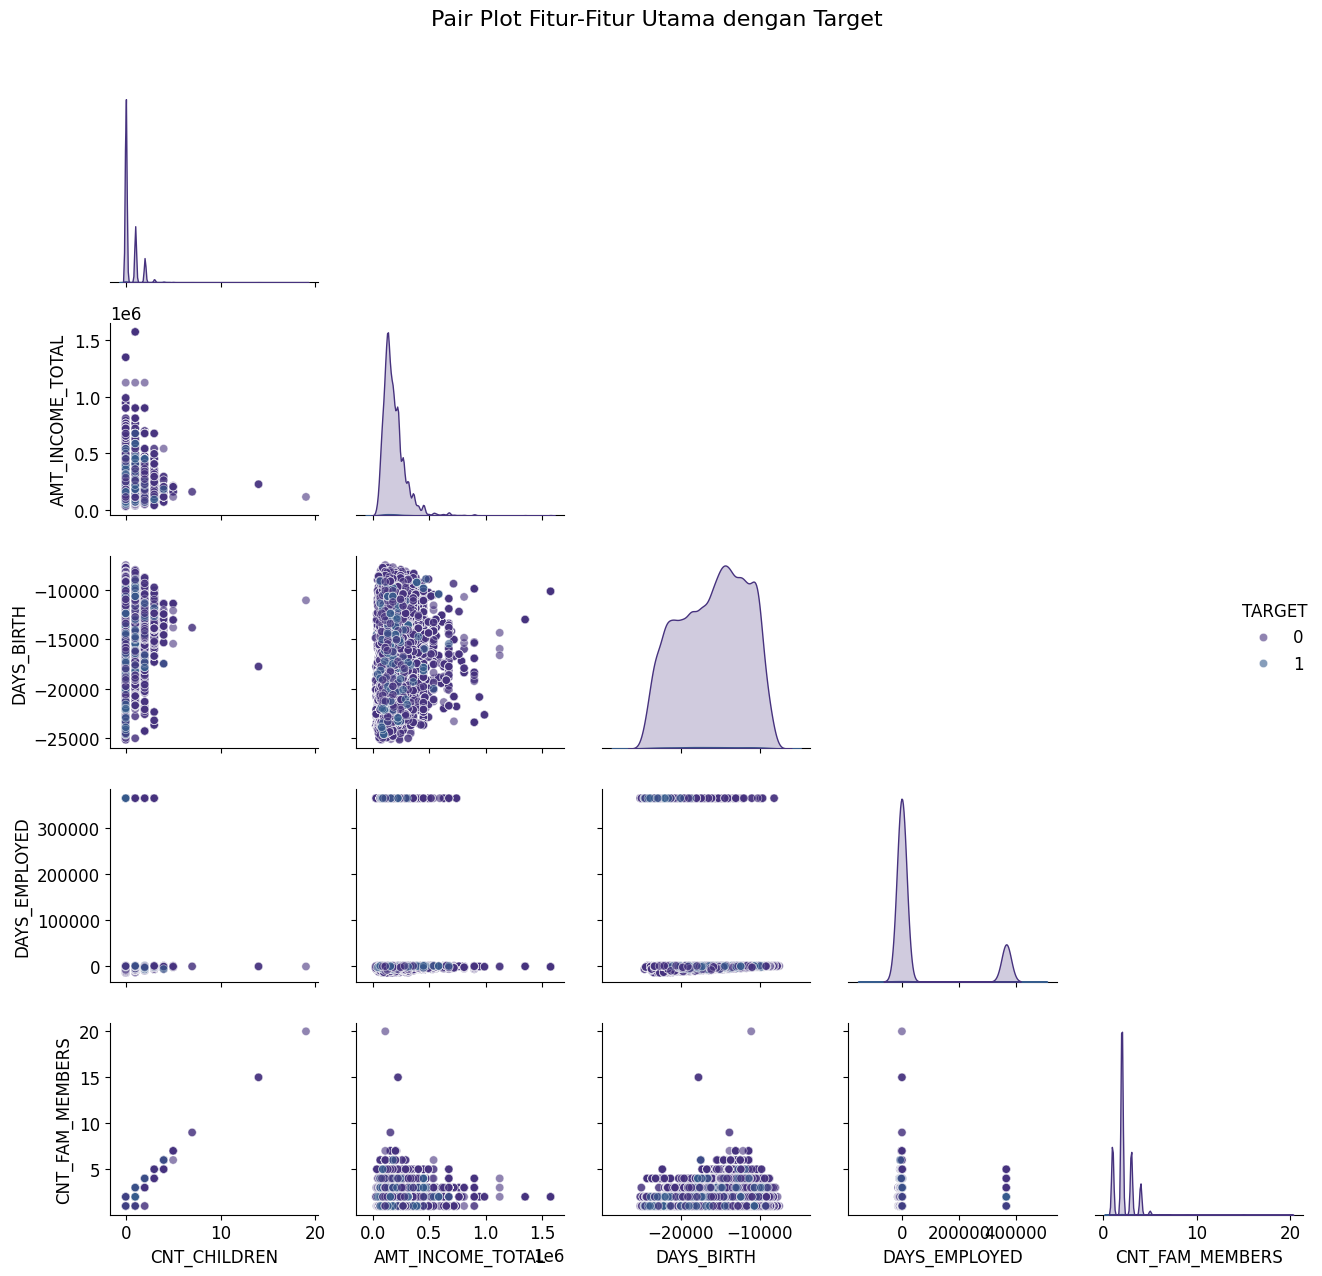

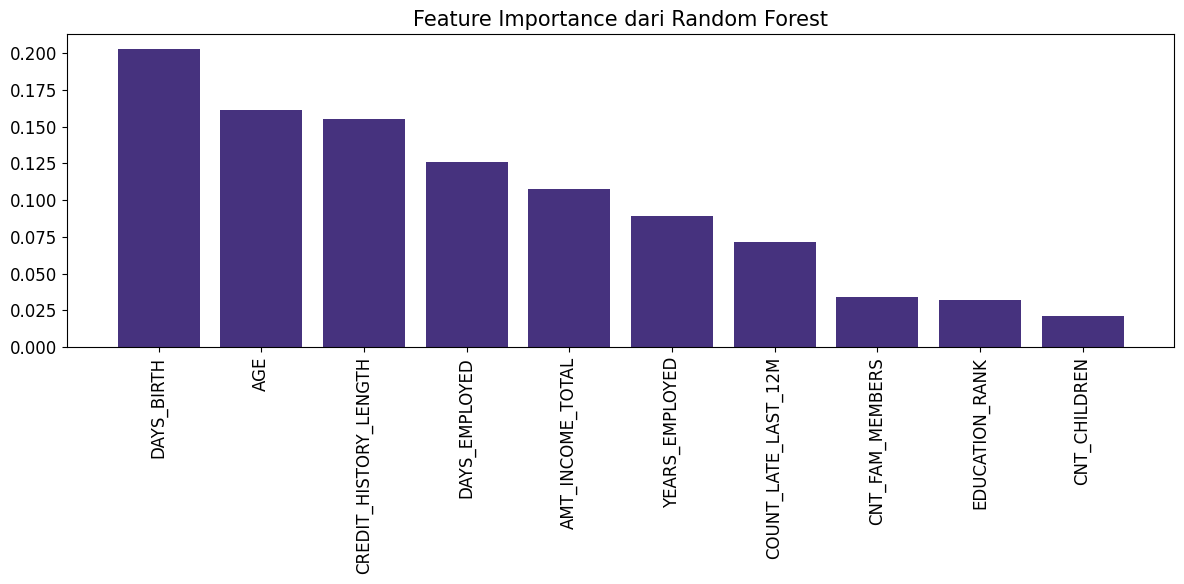


Feature Importance dari Random Forest:
DAYS_BIRTH: 0.2027
AGE: 0.1611
CREDIT_HISTORY_LENGTH: 0.1552
DAYS_EMPLOYED: 0.1257
AMT_INCOME_TOTAL: 0.1077
YEARS_EMPLOYED: 0.0889
COUNT_LATE_LAST_12M: 0.0712
CNT_FAM_MEMBERS: 0.0343
EDUCATION_RANK: 0.0320
CNT_CHILDREN: 0.0212


In [82]:
# 3.5 Analisis kompleksitas fitur dengan Target
def analyze_feature_complexity(df, numeric_cols, target='TARGET'):
    """Menganalisis kompleksitas hubungan antara berbagai fitur numerik dengan target."""
    
    print(f"\n{'='*50}")
    print(f"Analisis Kompleksitas Fitur dengan Target")
    print(f"{'='*50}")
    
    # Memilih subset fitur untuk analisis
    if len(numeric_cols) > 5:
        selected_features = numeric_cols[:5]  # Membatasi untuk 5 fitur pertama
    else:
        selected_features = numeric_cols
    
    # Menghitung korelasi dan mutual information untuk setiap fitur
    correlations = []
    for col in selected_features:
        corr = df[col].corr(df[target])
        correlations.append((col, abs(corr)))
    
    # Mengurutkan fitur berdasarkan korelasi absolut
    correlations.sort(key=lambda x: x[1], reverse=True)
    
    print("\nKorelasi absolut dengan target:")
    for col, corr in correlations:
        print(f"{col}: {corr:.4f}")
    
    # Pair plot untuk visualisasi hubungan antar fitur dan target
    plt.figure(figsize=(16, 12))
    feature_subset = selected_features + [target]
    sns.pairplot(df[feature_subset], hue=target, corner=True, diag_kind='kde',
               plot_kws={'alpha': 0.6}, height=2.5)
    plt.suptitle('Pair Plot Fitur-Fitur Utama dengan Target', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Visualisasi feature importance dari model Random Forest sederhana
    try:
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.model_selection import train_test_split
        
        # Menyiapkan data
        X = df[numeric_cols].fillna(df[numeric_cols].mean())
        y = df[target]
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        # Melatih model Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        
        # Mendapatkan feature importance
        importances = rf.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        # Plot feature importance
        plt.figure(figsize=(12, 6))
        plt.title('Feature Importance dari Random Forest', fontsize=15)
        plt.bar(range(X.shape[1]), importances[indices], align='center')
        plt.xticks(range(X.shape[1]), [numeric_cols[i] for i in indices], rotation=90)
        plt.tight_layout()
        plt.show()
        
        print("\nFeature Importance dari Random Forest:")
        for i in range(X.shape[1]):
            print(f"{numeric_cols[indices[i]]}: {importances[indices[i]]:.4f}")
        
    except Exception as e:
        print(f"Tidak dapat melakukan analisis Random Forest: {str(e)}")


print("\n\n*** ANALISIS KOMPLEKSITAS FITUR DENGAN TARGET ***")
analyze_feature_complexity(eda_df, numeric_cols)